In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
! gdown 1GXTmFALF5QcaC-TfTiHaPLVYf9OOKIIZ

Downloading...
From: https://drive.google.com/uc?id=1GXTmFALF5QcaC-TfTiHaPLVYf9OOKIIZ
To: /content/BankChurners.csv
100% 1.21M/1.21M [00:00<00:00, 12.6MB/s]


In [ ]:
data = pd.read_csv('BankChurners.csv')

In [ ]:
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
# Adding feature Average Amount spent per transaction (avg_amt)
data['avg_amt'] = data['Total_Trans_Amt']/data['Total_Trans_Ct']
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,avg_amt
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,27.238095
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,39.121212
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,94.350000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,58.550000
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,29.142857


In [ ]:
#Checking data types of the dataframe
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [ ]:
#Checking for Null Values
data.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [ ]:
#Checking description of numerical columns of the dataframe
data.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,avg_amt
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,62.612717
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,26.404198
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,19.137931
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,47.514573
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,55.794872
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,65.476673
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,190.193182


In [ ]:
#Dropping CLIENTNUM column from the original dataframe
data.drop('CLIENTNUM',axis=1,inplace=True) #inplace True removes column from original dataframe

In [ ]:
data.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,avg_amt
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,27.238095
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,39.121212
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,94.350000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,58.550000
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,29.142857


In [ ]:
#Creating Age bins to convert customer age to categorical column
age_bin = [20,30,40,50,60,75]
age_labels = ['20-29','30-39','40-49','50-59','60+']

data['Age_Bins'] = pd.cut(data['Customer_Age'],bins=age_bin,labels=age_labels,right=False)

In [ ]:
#Dropping Customer Age column as a age_bin column has been created
data.drop('Customer_Age',axis=1,inplace=True)

In [ ]:
#Creating a dataframe with only existing customers
data_existing_customer = data[data['Attrition_Flag']=='Existing Customer']

In [ ]:
#Creating a dateframe with only attrited customers
data_attrited_customer = data[data['Attrition_Flag']=='Attrited Customer']

# Business Question 1: What factors are associated with higher customer churn?
Objective:
Identify key differences between customers who churned and those who stayed.  Help the bank understand what types of customers are more likely to churn so they can take preventive actions.


# Univariate Analysis of Categorical Columns

---



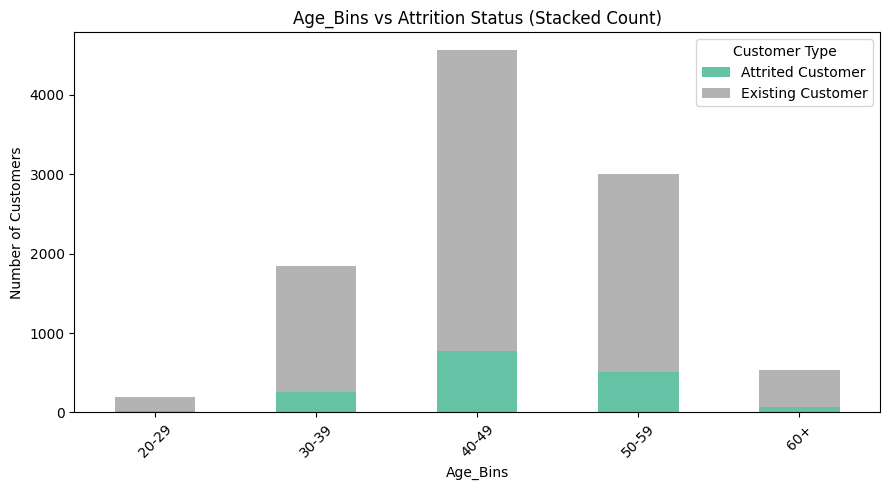

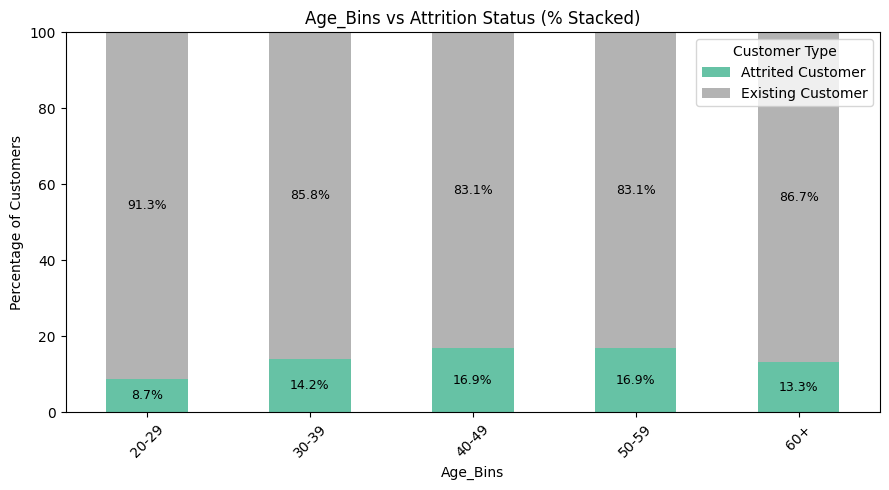

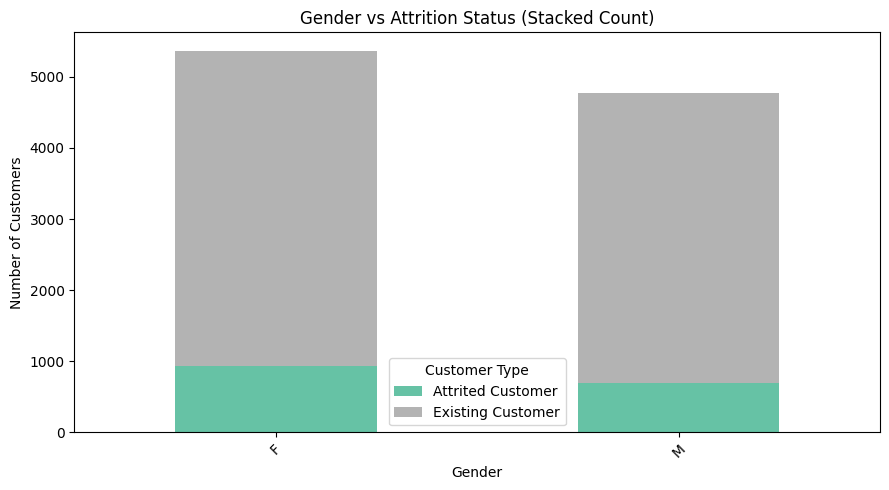

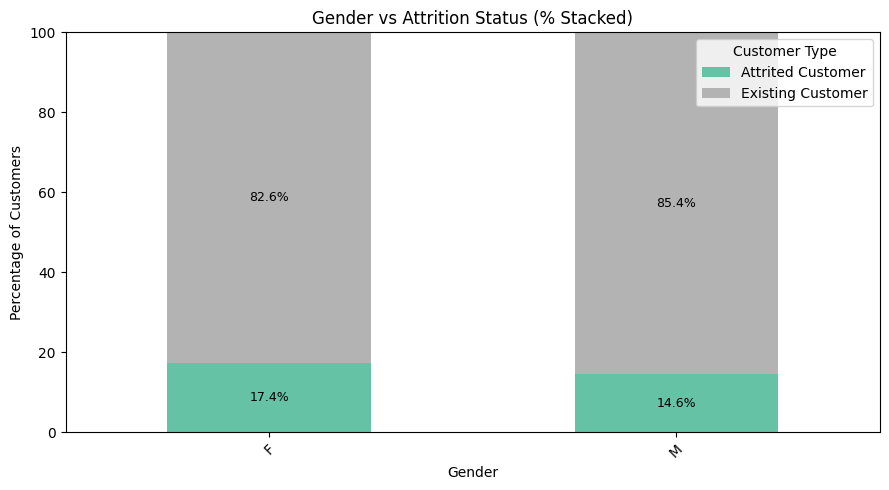

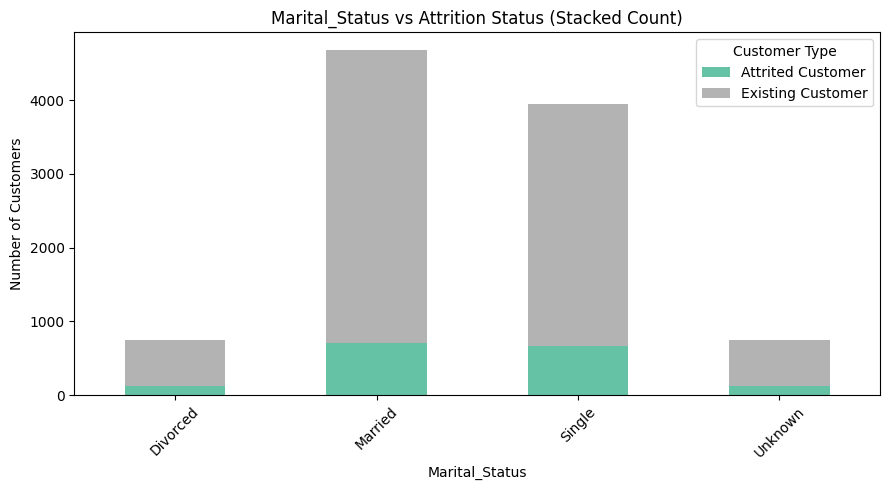

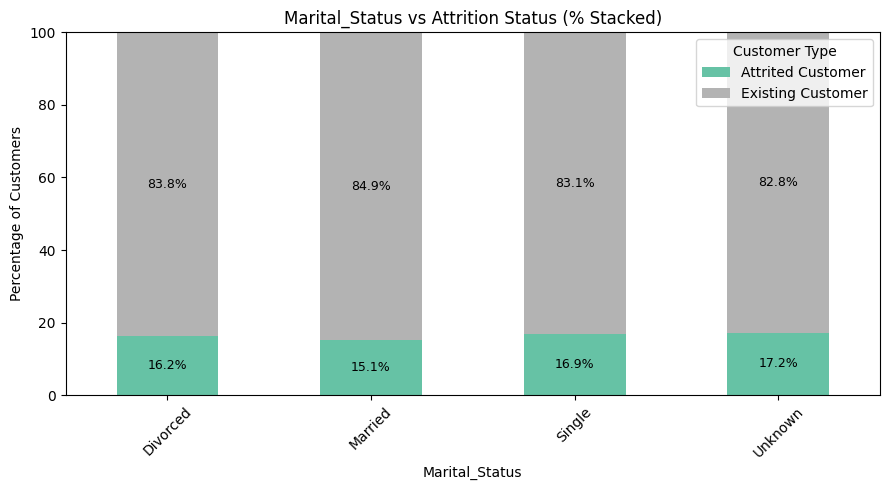

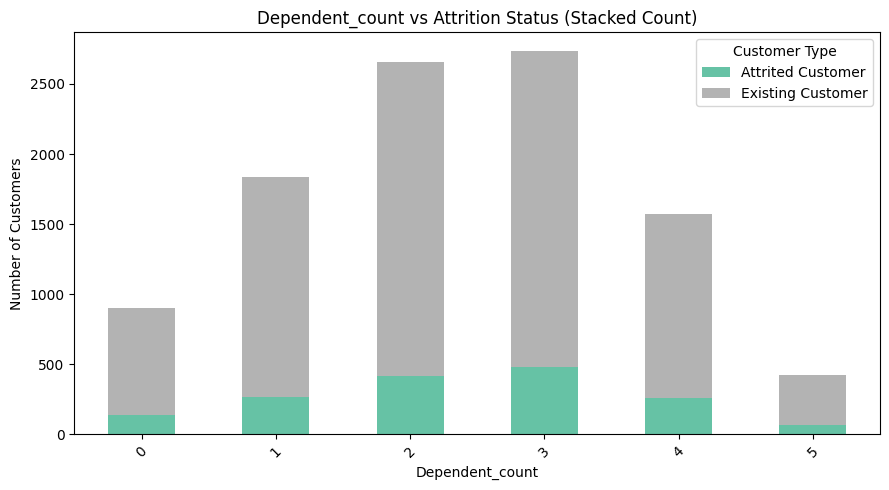

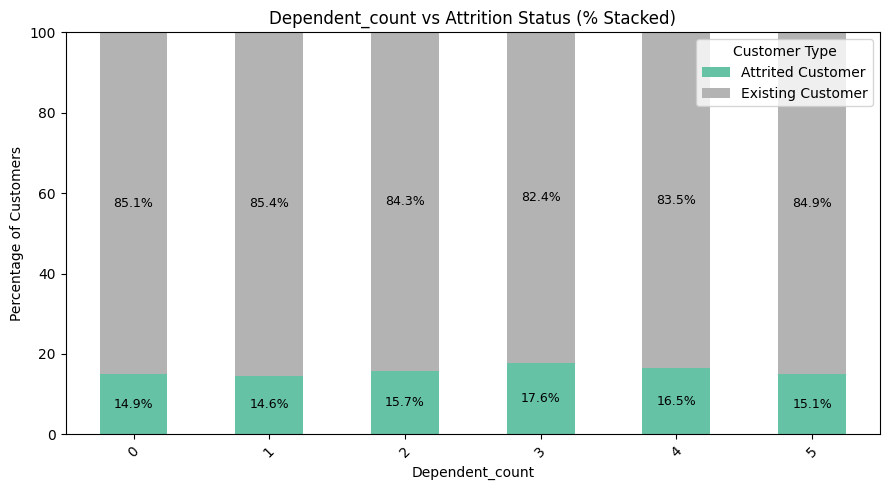

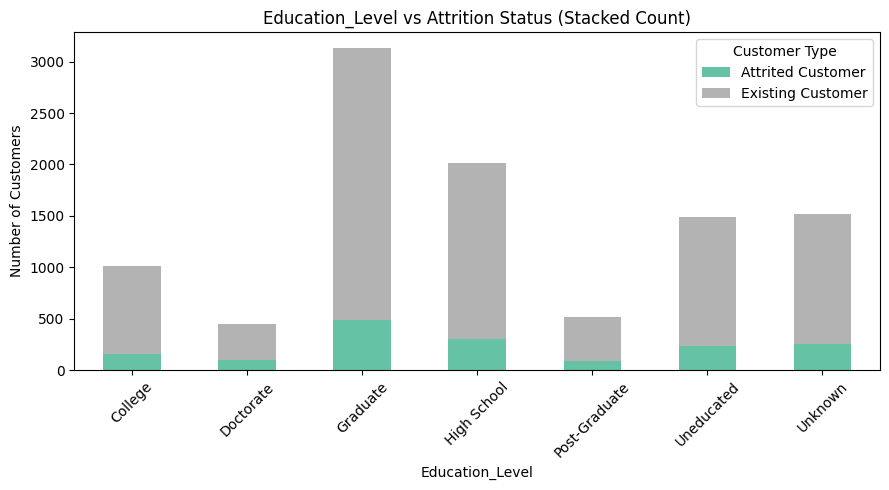

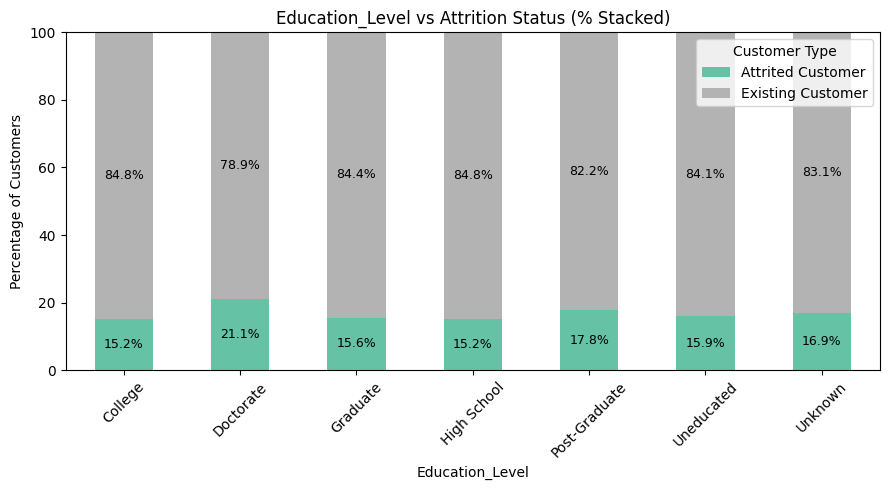

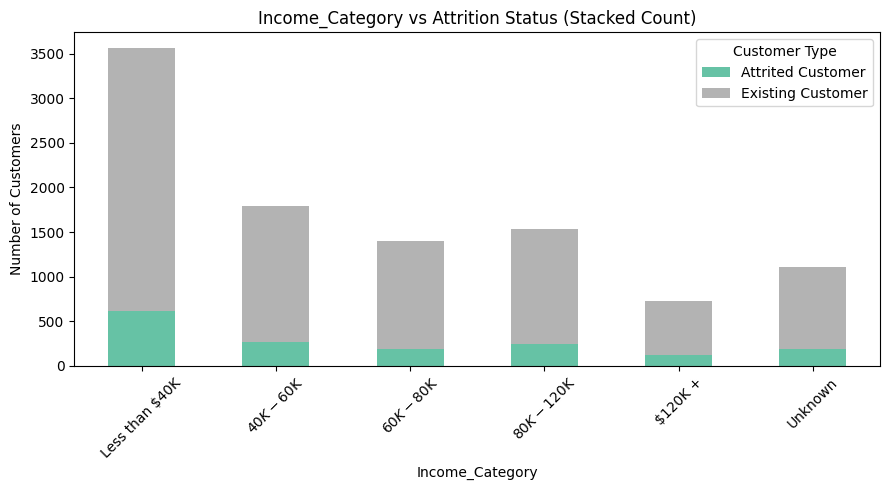

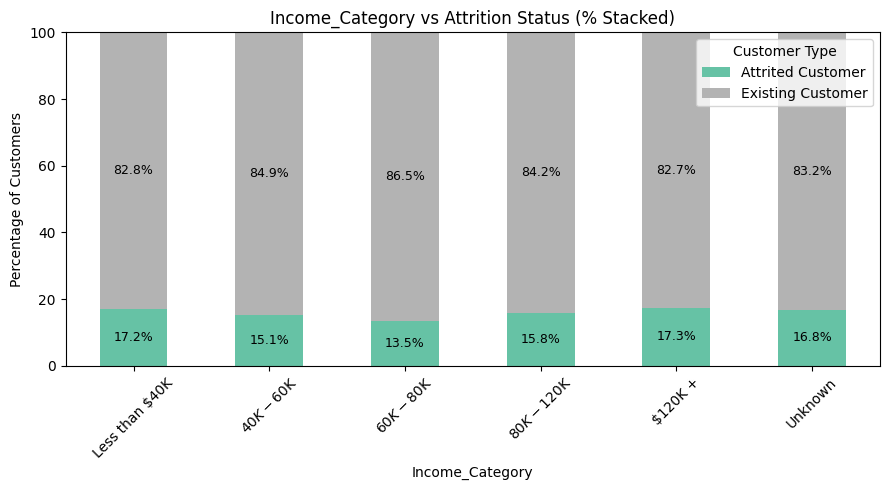

In [ ]:
# List of categorical features to visualize against Attrition_Flag
categorical_cols = ['Age_Bins', 'Gender', 'Marital_Status', 'Dependent_count',
                    'Education_Level', 'Income_Category']

# Optional: ordering for certain variables

custom_orders = {
    'Age_Bins': ['20-29', '30-39', '40-49', '50-59', '60+'],
    'Dependent_count': [0, 1, 2, 3, 4, 5],
    'Income_Category': ['Less than $40K', '$40K - $60K', '$60K - $80K',
                        '$80K - $120K', '$120K +', 'Unknown']
}

for col in categorical_cols:
    # Create crosstab
    ct = pd.crosstab(data[col], data['Attrition_Flag'])

    # Reindex if order is defined
    if col in custom_orders:
        ct = ct.reindex(custom_orders[col])

    # PLOT 1 Stacked Bar Chart (Counts) -----
    ax1 = ct.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Set2')
    plt.title(f'{col} vs Attrition Status (Stacked Count)')
    plt.xlabel(col)
    plt.ylabel('Number of Customers')
    plt.legend(title='Customer Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    #PLOT 2: Stacked Bar Chart (Percentages + Labels) -----
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ax2 = ct_pct.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Set2')

    for i, category in enumerate(ct_pct.index):
        y_offset = 0
        for status in ct_pct.columns:
            pct = ct_pct.loc[category, status]
            if pct > 0:
                ax2.text(i, y_offset + pct / 2, f'{pct:.1f}%', ha='center', va='center', fontsize=9)
                y_offset += pct

    plt.title(f'{col} vs Attrition Status (% Stacked)')
    plt.xlabel(col)
    plt.ylabel('Percentage of Customers')
    plt.ylim(0, 100)
    plt.legend(title='Customer Type', loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Bivariate Analysis of categorical columns

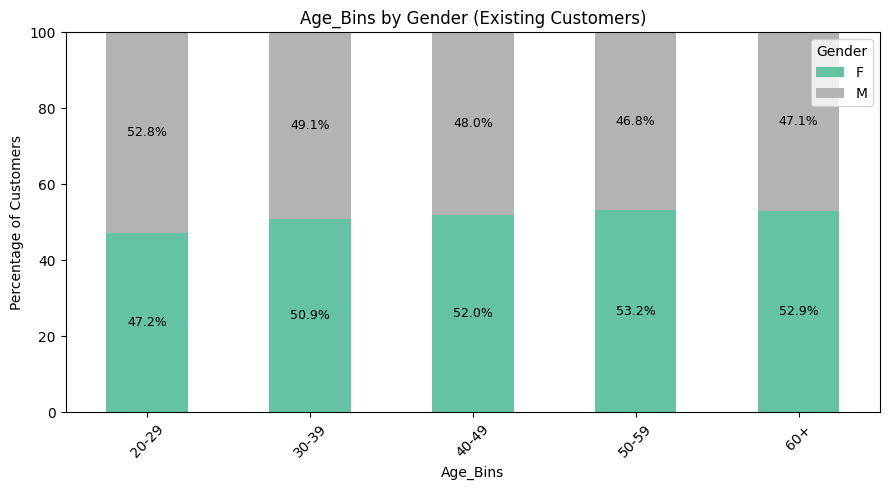

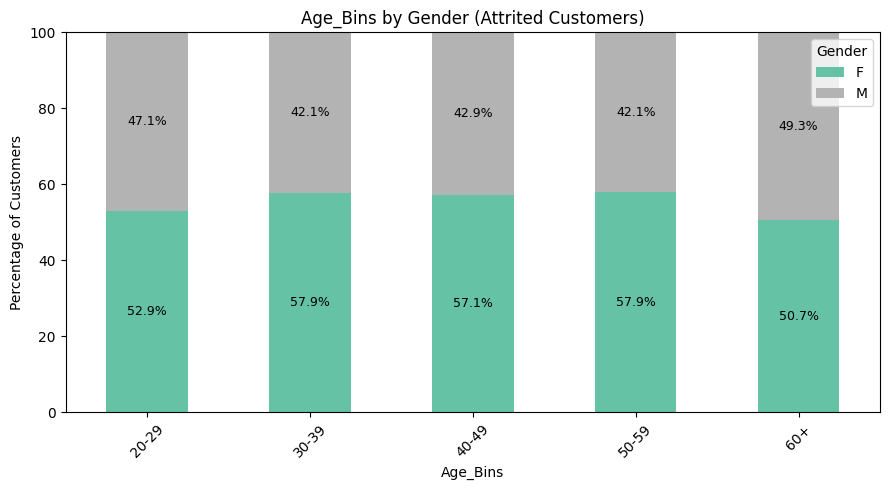

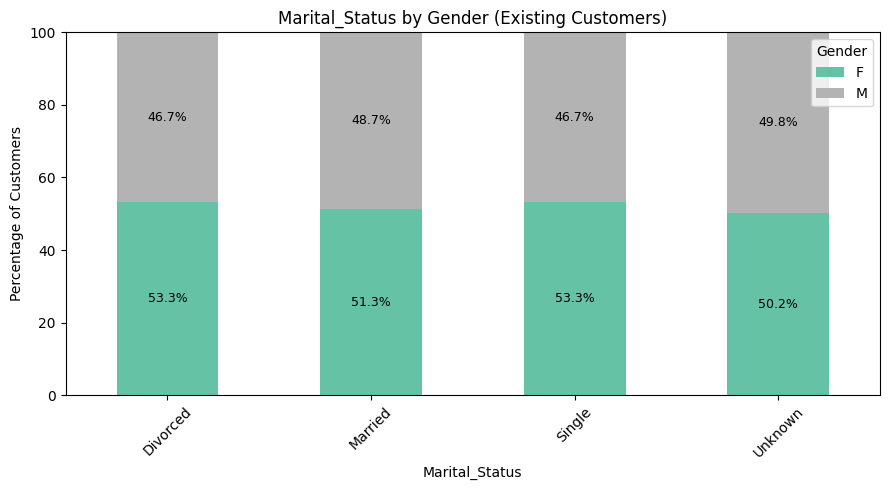

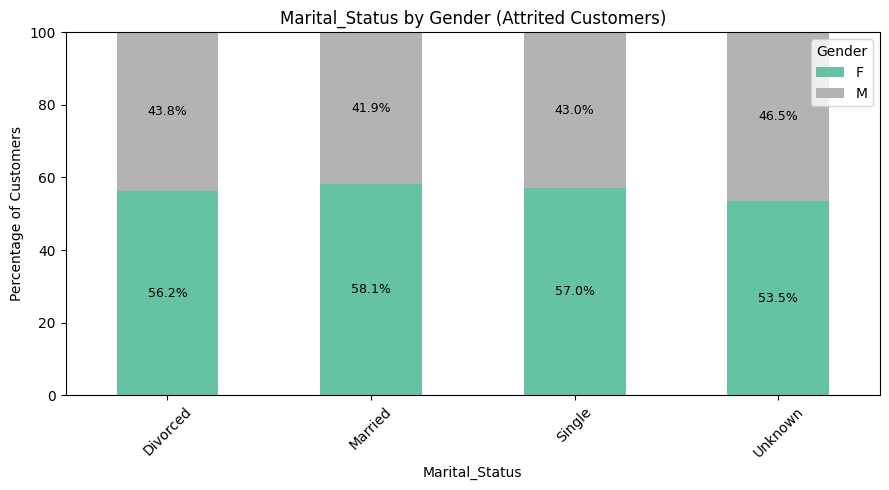

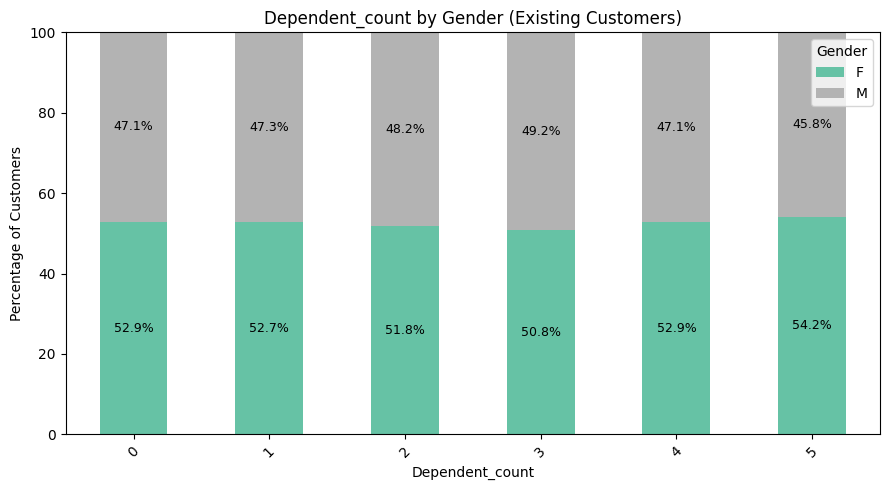

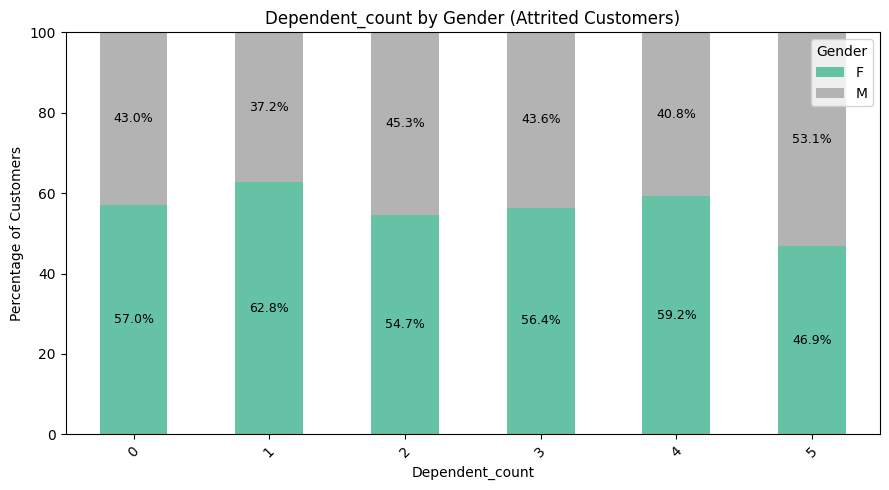

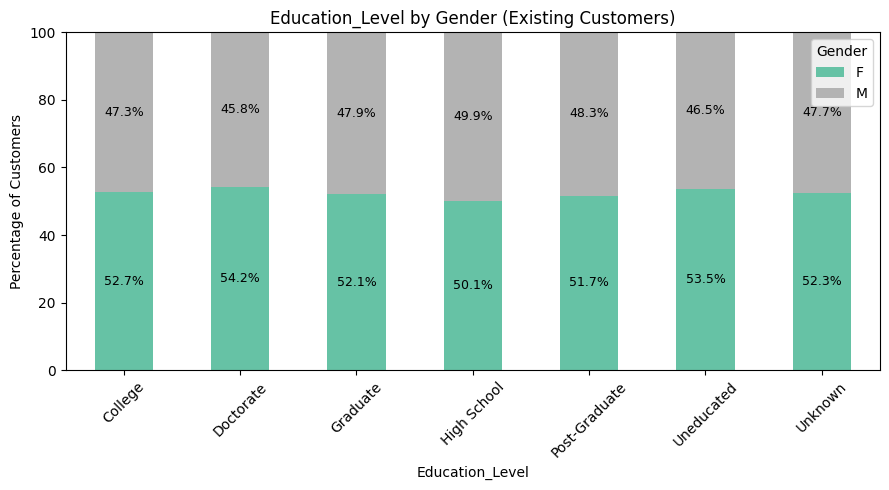

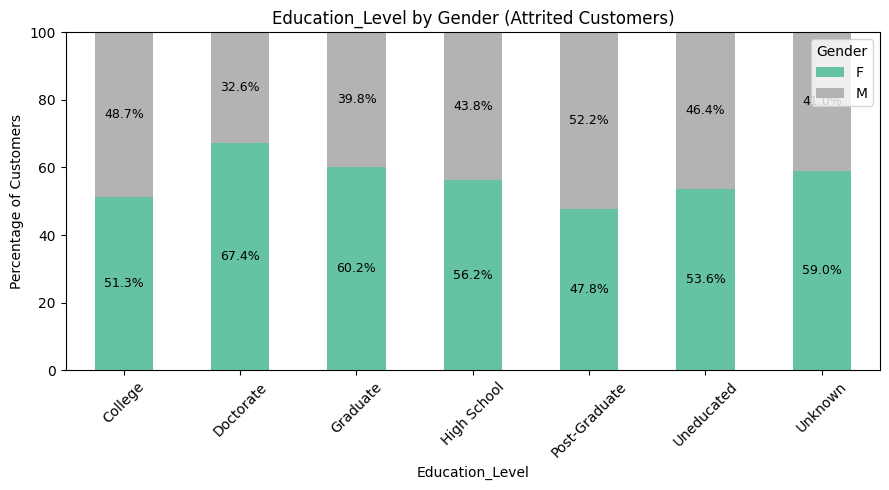

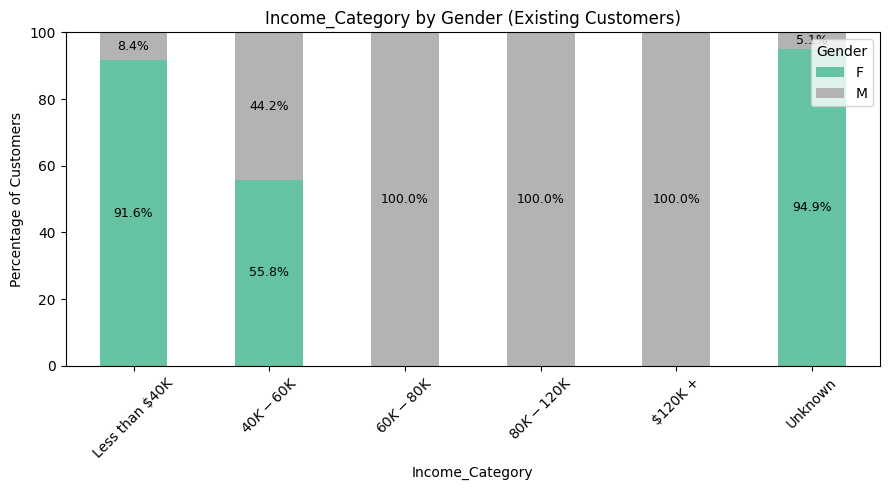

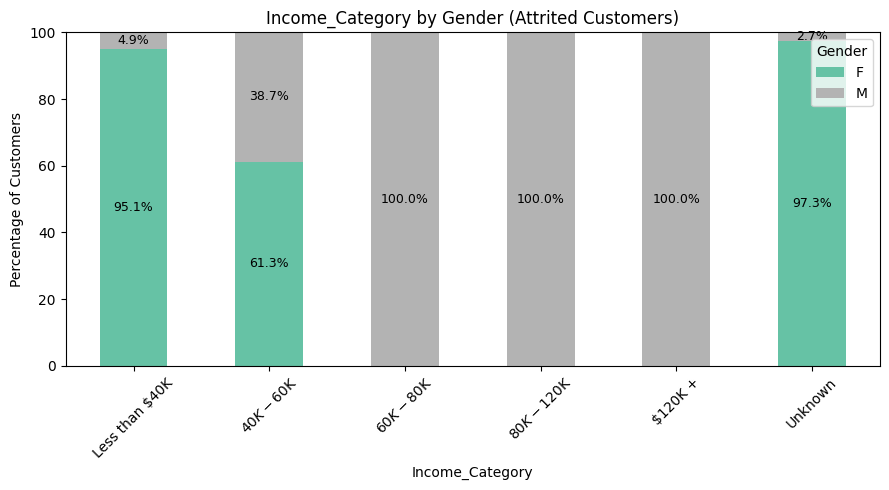

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# List of categorical variables to analyze with Gender
categorical_cols = ['Age_Bins', 'Marital_Status', 'Dependent_count',
                    'Education_Level', 'Income_Category']

# Optional orderings for display
custom_orders = {
    'Age_Bins': ['20-29', '30-39', '40-49', '50-59', '60+'],
    'Dependent_count': [0, 1, 2, 3, 4, 5],
    'Income_Category': ['Less than $40K', '$40K - $60K', '$60K - $80K',
                        '$80K - $120K', '$120K +', 'Unknown']
}
# Loop through each categorical variable
for col in categorical_cols:
    for group_label, group_data in {
        'Existing Customers': data[data['Attrition_Flag'] == 'Existing Customer'],
        'Attrited Customers': data[data['Attrition_Flag'] == 'Attrited Customer']
    }.items():

        #Create crosstab of feature vs gender
        ct = pd.crosstab(group_data[col], group_data['Gender'])

        #Reindex if custom order is available
        if col in custom_orders:
            ct = ct.reindex(custom_orders[col])

        # Row-wise normalization to get percentages
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

        # Plot
        ax = ct_pct.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Set2')

        # Add percentage labels
        for i, category in enumerate(ct_pct.index):
            y_offset = 0
            for gender in ct_pct.columns:
                pct = ct_pct.loc[category, gender]
                if pct > 0:
                    ax.text(i, y_offset + pct / 2, f'{pct:.1f}%', ha='center', va='center', fontsize=9)
                    y_offset += pct

        # Format and display
        plt.title(f'{col} by Gender ({group_label})')
        plt.xlabel(col)
        plt.ylabel('Percentage of Customers')
        plt.ylim(0, 100)
        plt.legend(title='Gender', loc='upper right')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


# Correlation Matrix of Numerical Columns

In [ ]:
#Accessing Numerical Columns
credit_limit = data['Credit_Limit']
Months_on_book = data['Months_on_book']
Total_Relationship_Count = data['Total_Relationship_Count']
Months_Inactive_12_mon = data['Months_Inactive_12_mon']
Contacts_Count_12_mon = data['Contacts_Count_12_mon']
Total_Revolving_Bal = data['Total_Revolving_Bal']
Total_Trans_Amt = data['Total_Trans_Amt']
Total_Trans_Ct = data['Total_Trans_Ct']
Avg_Open_To_Buy = data['Avg_Open_To_Buy']
Total_Amt_Chng_Q4_Q1 = data['Total_Amt_Chng_Q4_Q1']
Total_Ct_Chng_Q4_Q1 = data['Total_Ct_Chng_Q4_Q1']
Avg_Utilization_Ratio = data['Avg_Utilization_Ratio']

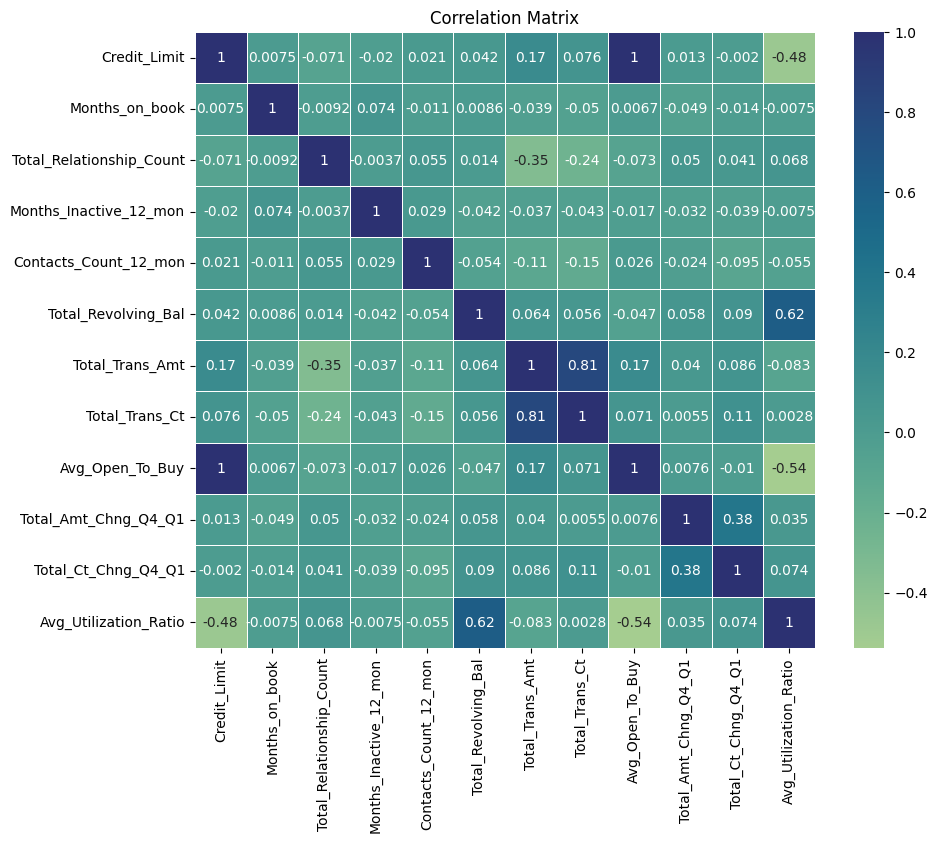

In [ ]:
#Correlation Matrix of Numerical Columns
selected_columns = ['Credit_Limit', 'Months_on_book', 'Total_Relationship_Count',
                   'Months_Inactive_12_mon', 'Contacts_Count_12_mon',
                   'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct',
                   'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
                   'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

# Create a subset DataFrame with the selected columns
subset_data = data[selected_columns]

# Calculate the correlation matrix
corr_matrix = subset_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='crest', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Univariate Analysis of Numerical columns

Existing Customer dataframe

In [ ]:
data_num_col = ['Credit_Limit', 'Months_on_book', 'Total_Relationship_Count',
                'Months_Inactive_12_mon', 'Contacts_Count_12_mon',
                'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct',
                'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
                'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio','avg_amt']

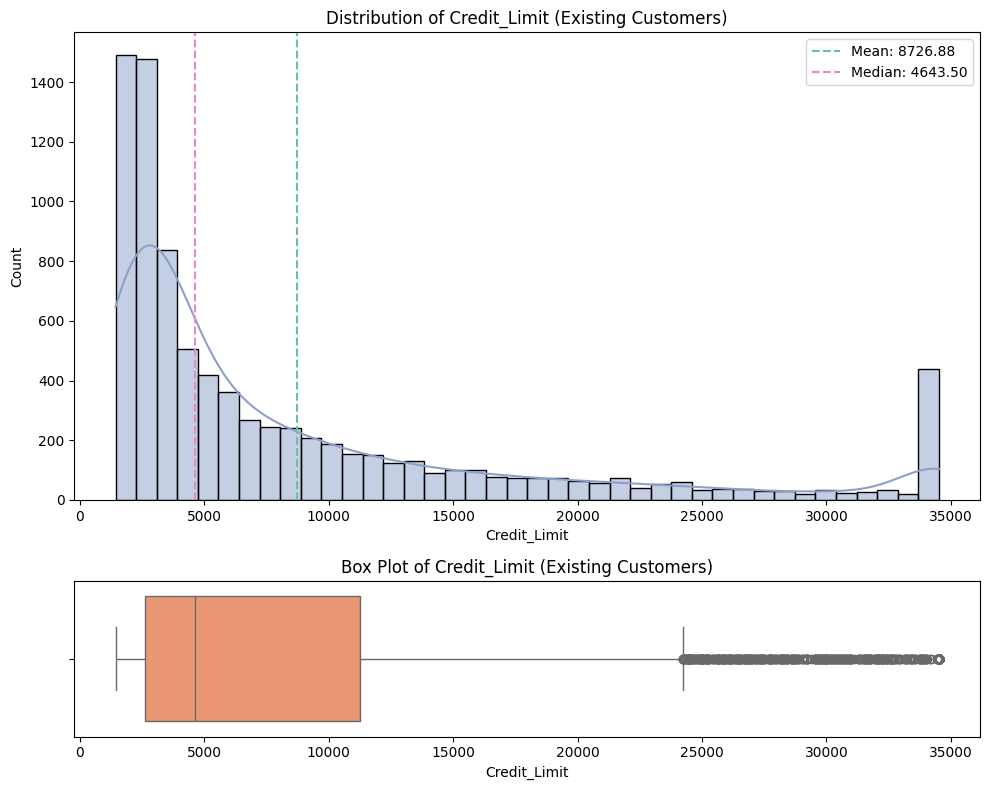

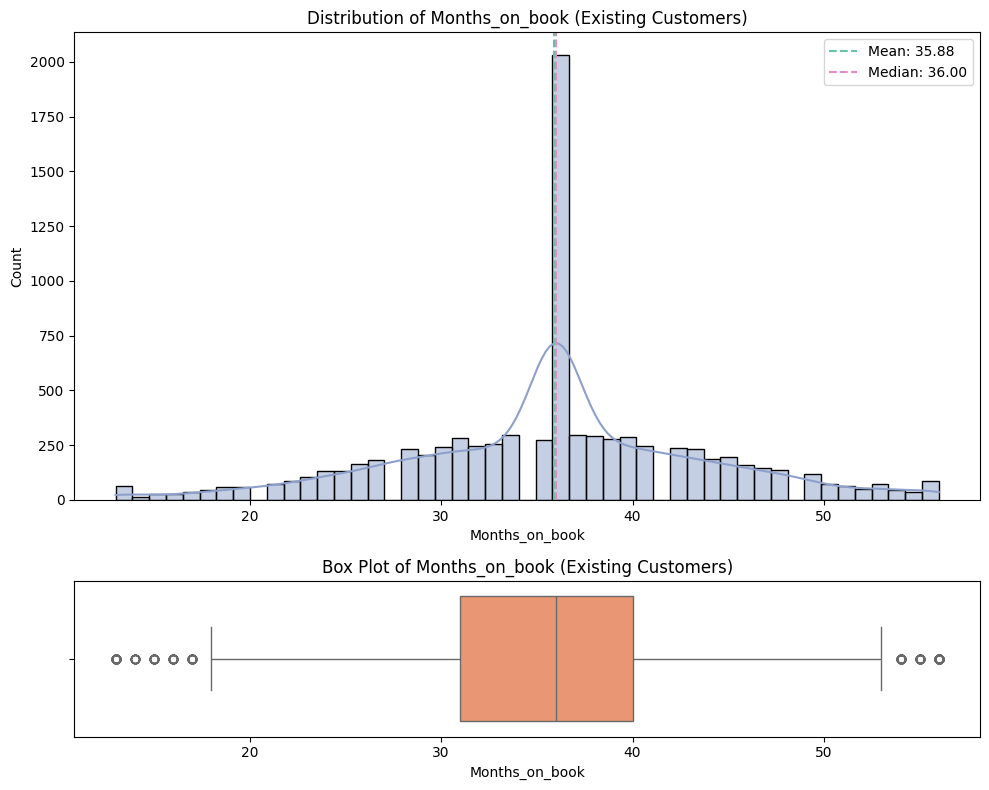

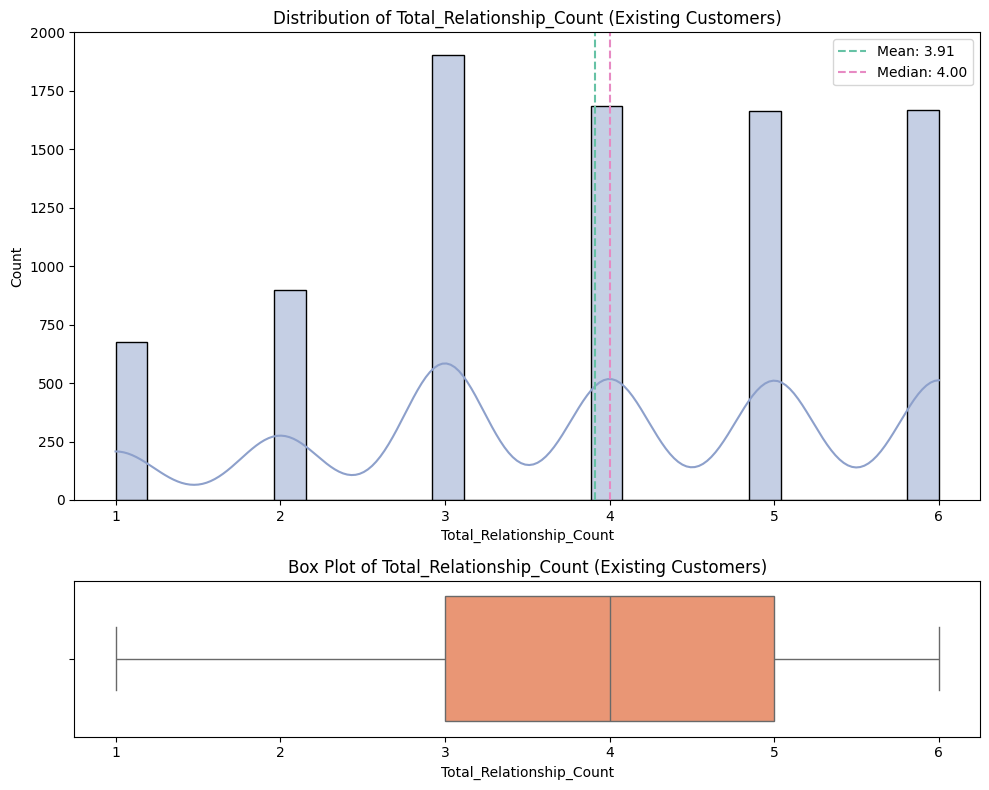

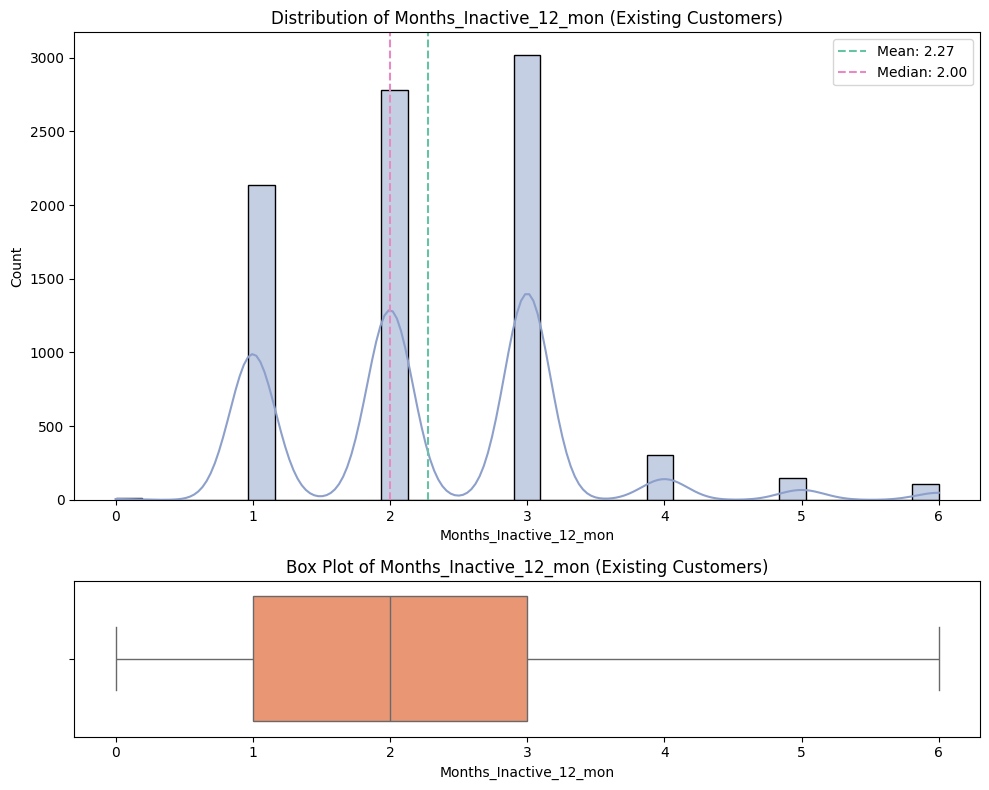

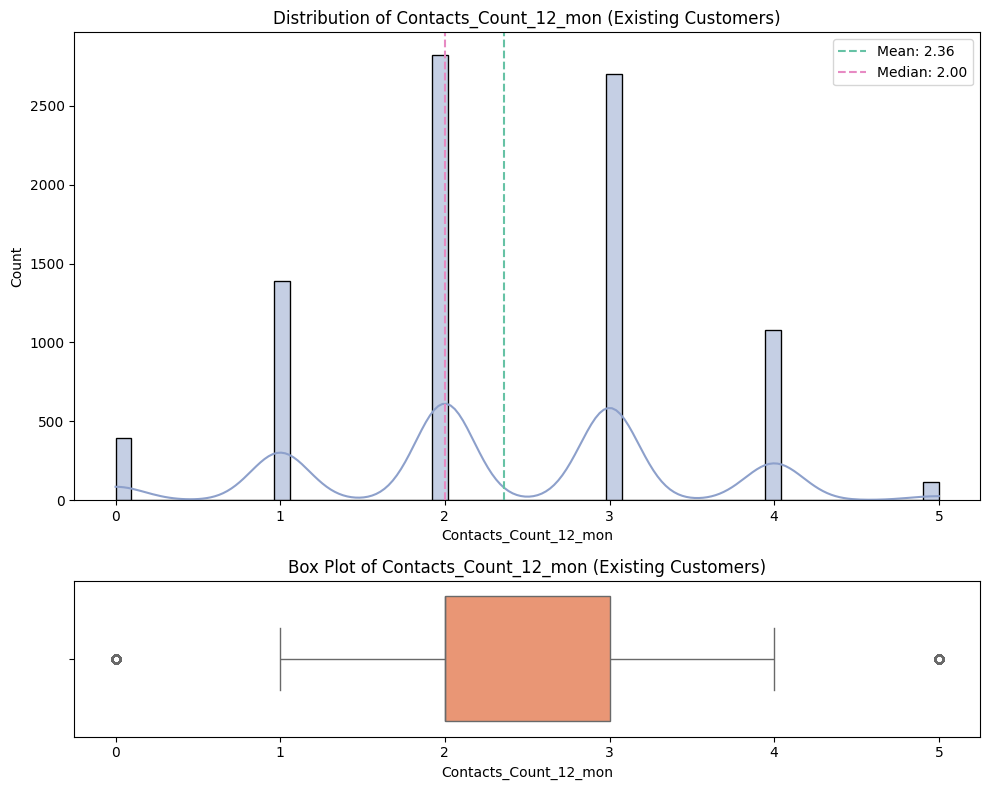

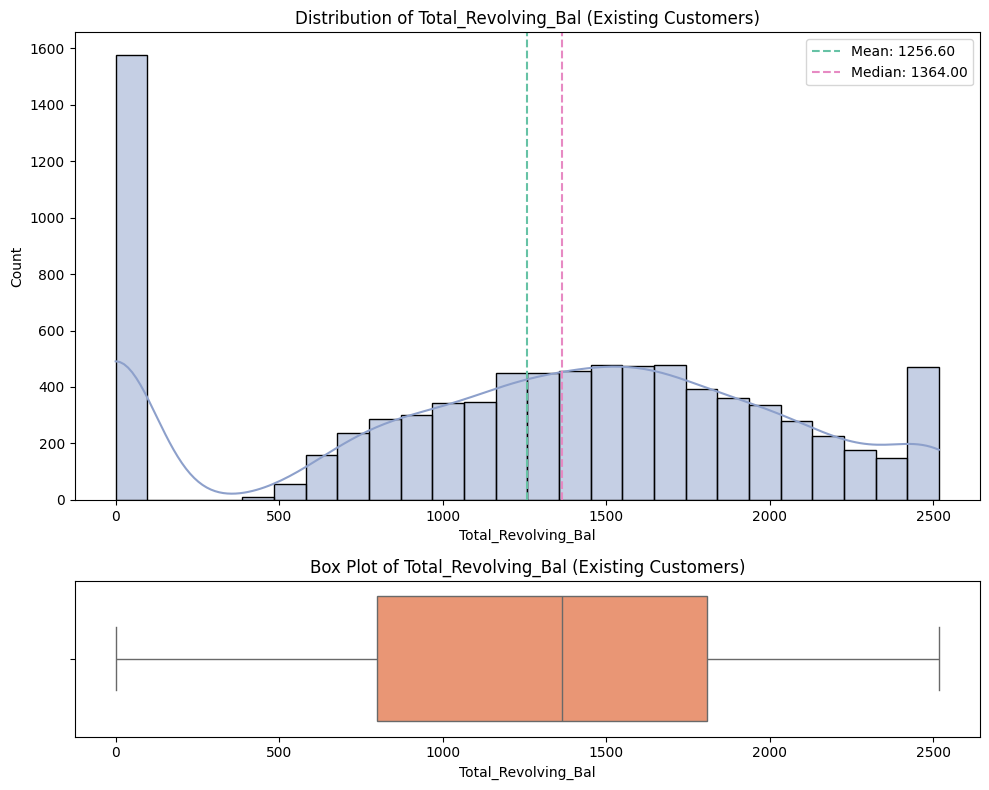

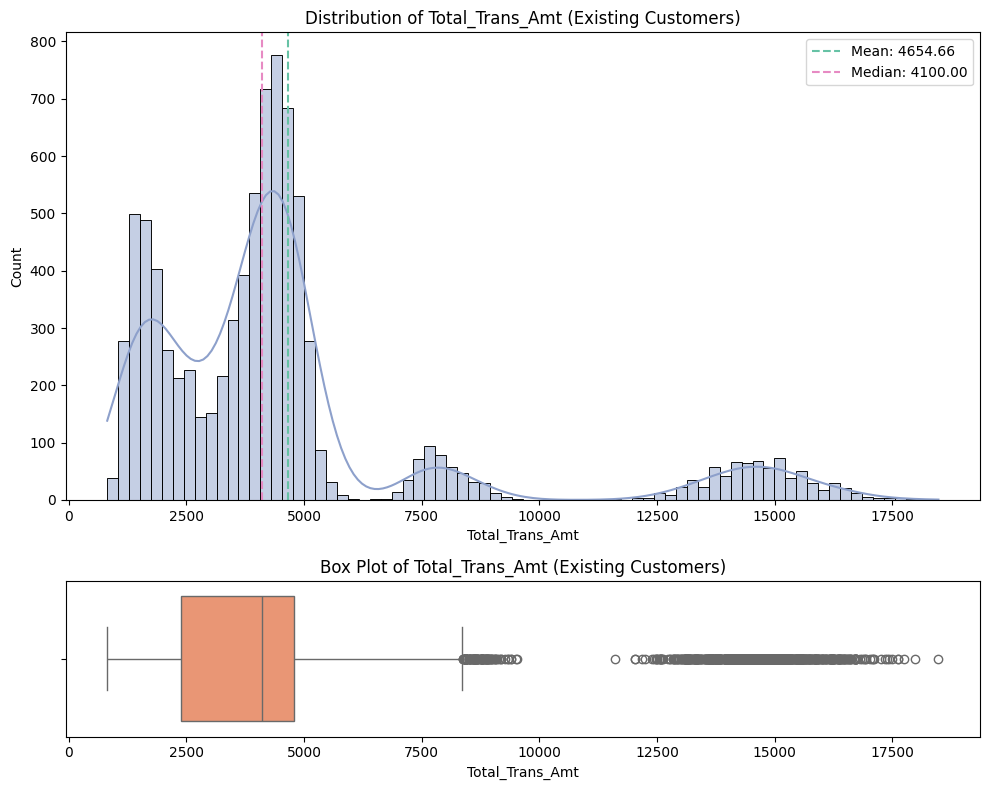

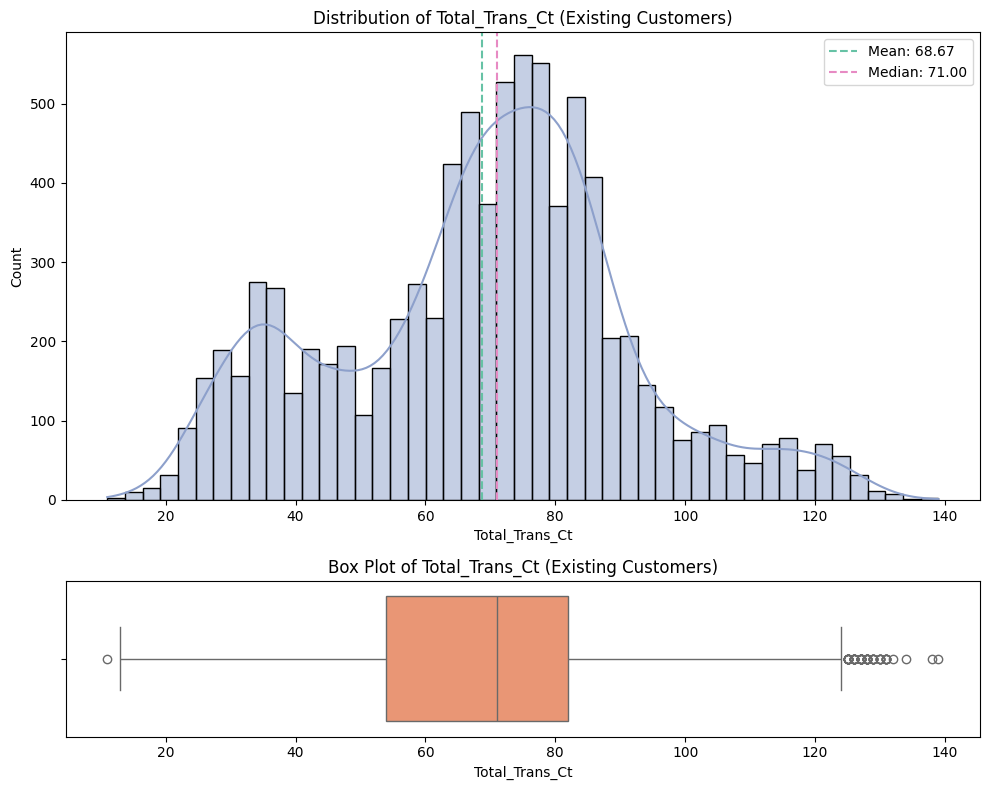

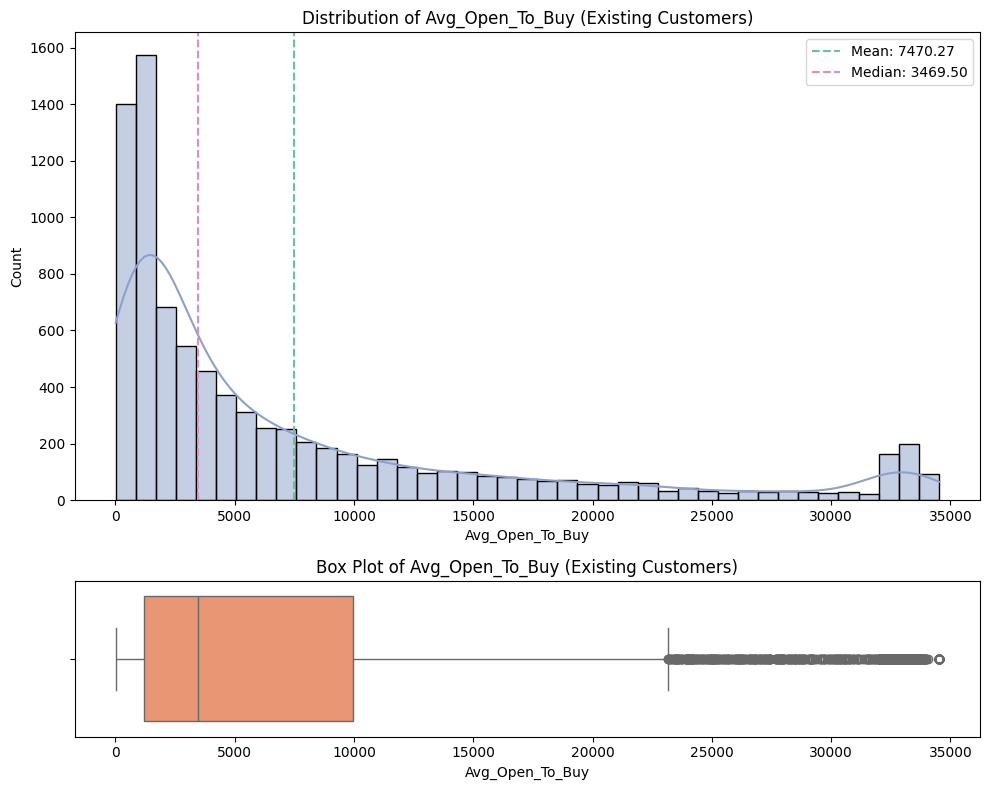

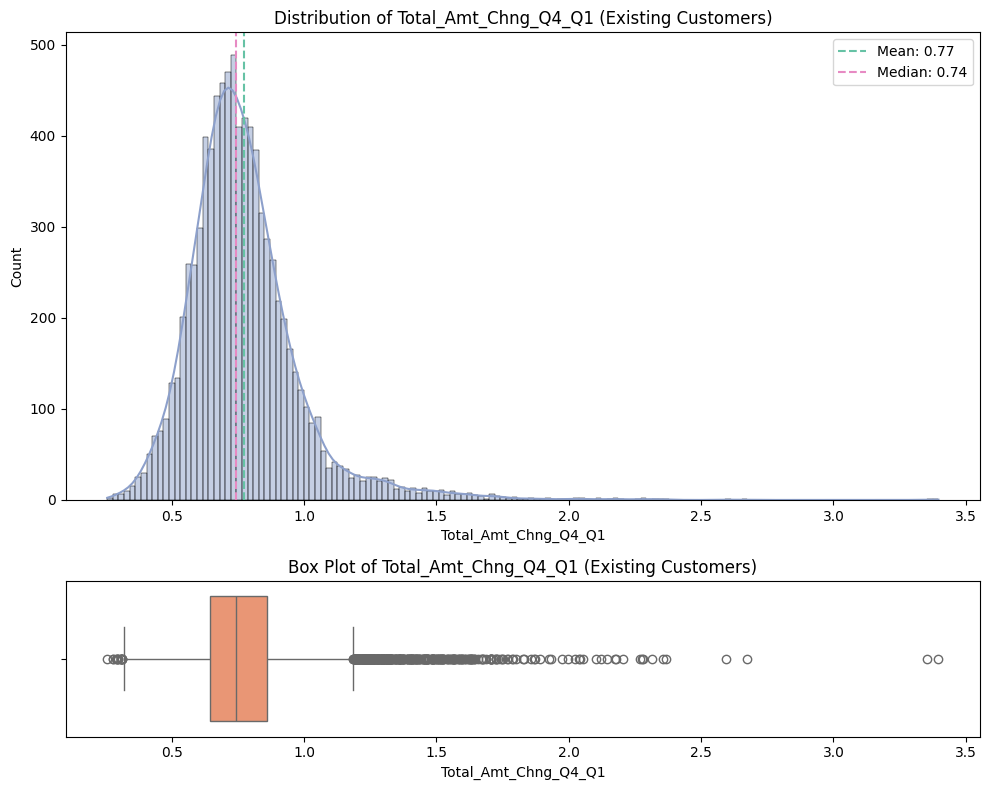

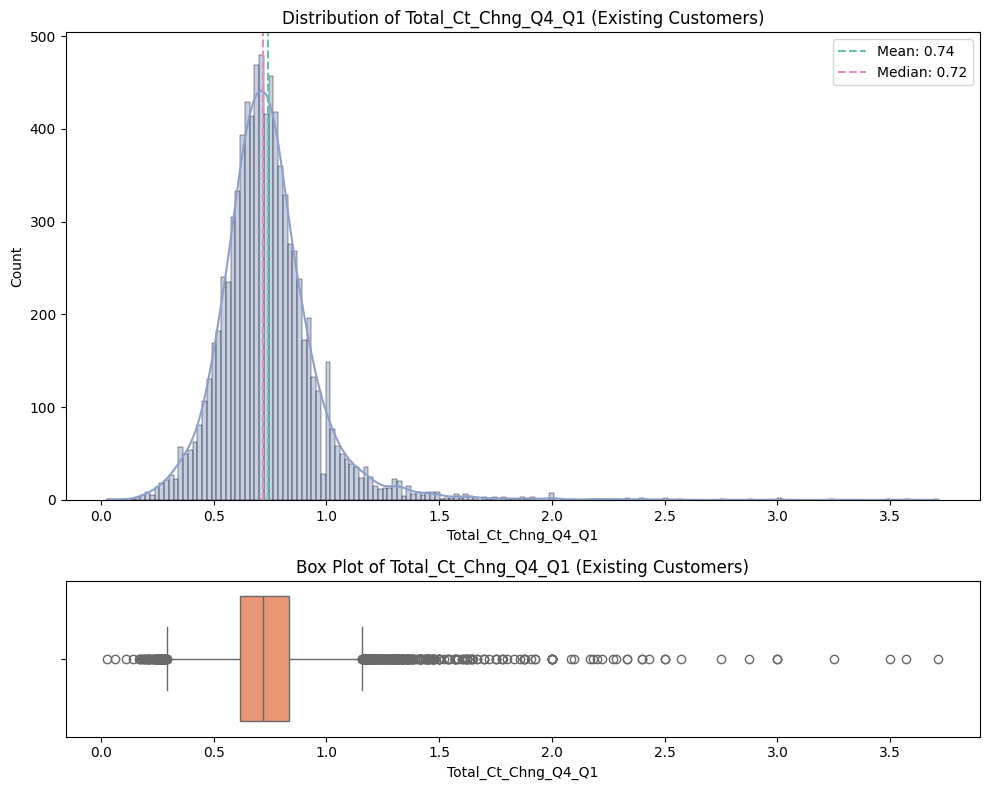

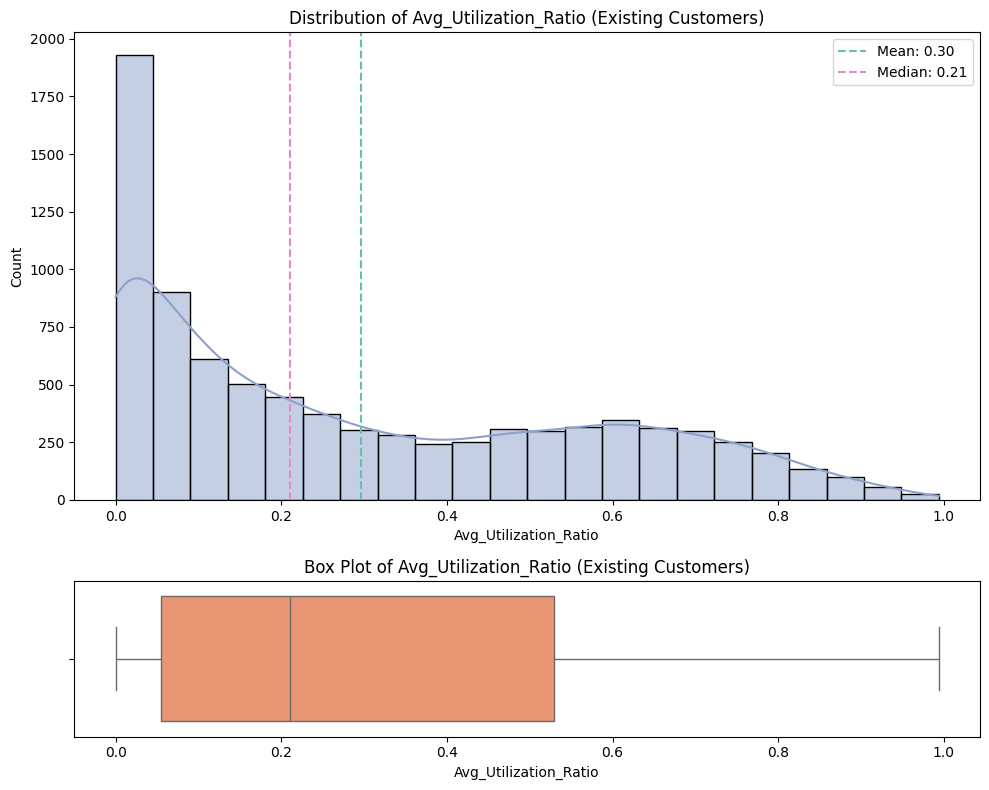

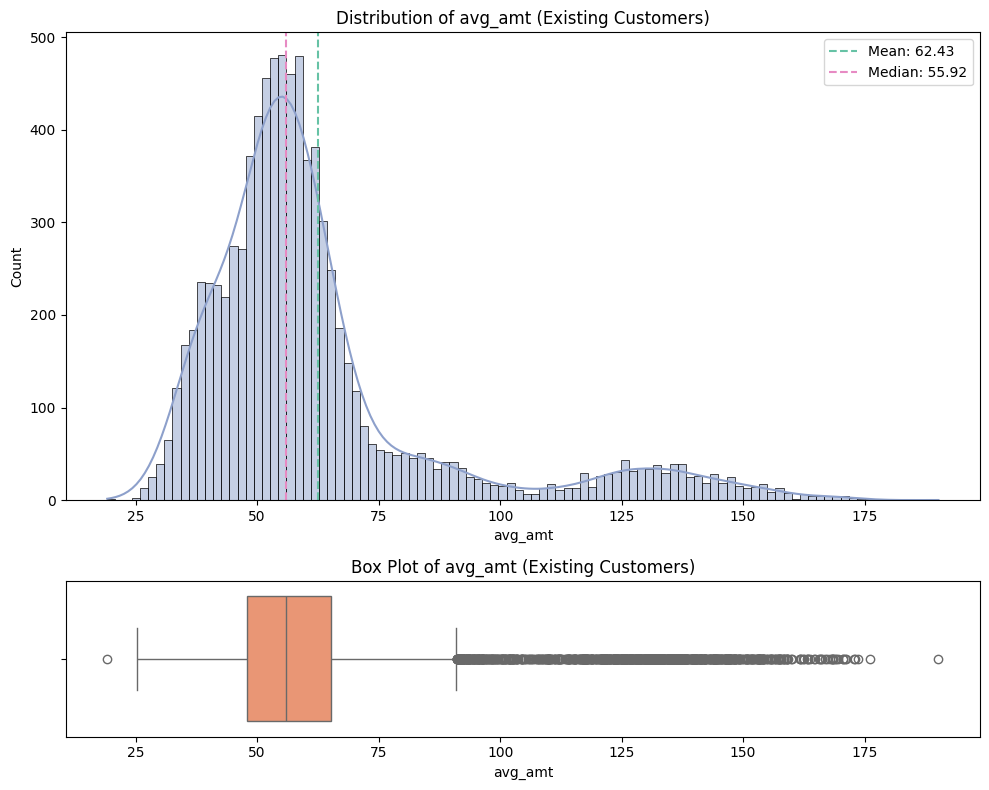

In [ ]:
#FOR EXISTING CUSTOMERS
# Colors from seaborn Set2 palette
hist_color = '#8DA0CB'   #
box_color = '#FC8D62'    #
mean_line_color = '#66C2A5'   #
median_line_color = '#E78AC3' #

# Creating Attrited Customer Distribution charts for Numerical columns
for num_col1 in data_num_col:
    data_col1 = data_existing_customer[num_col1]
    mean_val1 = data_col1.mean()
    median_val1 = data_col1.median()

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Histogram
    sns.histplot(data=data_col1, color=hist_color, kde=True, ax=axes[0])
    axes[0].axvline(mean_val1, color=mean_line_color, linestyle='--', label=f'Mean: {mean_val1:.2f}')
    axes[0].axvline(median_val1, color=median_line_color, linestyle='--', label=f'Median: {median_val1:.2f}')
    axes[0].set_title(f'Distribution of {num_col1} (Existing Customers)')
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=data_col1, color=box_color, ax=axes[1])
    axes[1].set_title(f'Box Plot of {num_col1} (Existing Customers)')
    axes[1].set_xlabel(num_col1)
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()


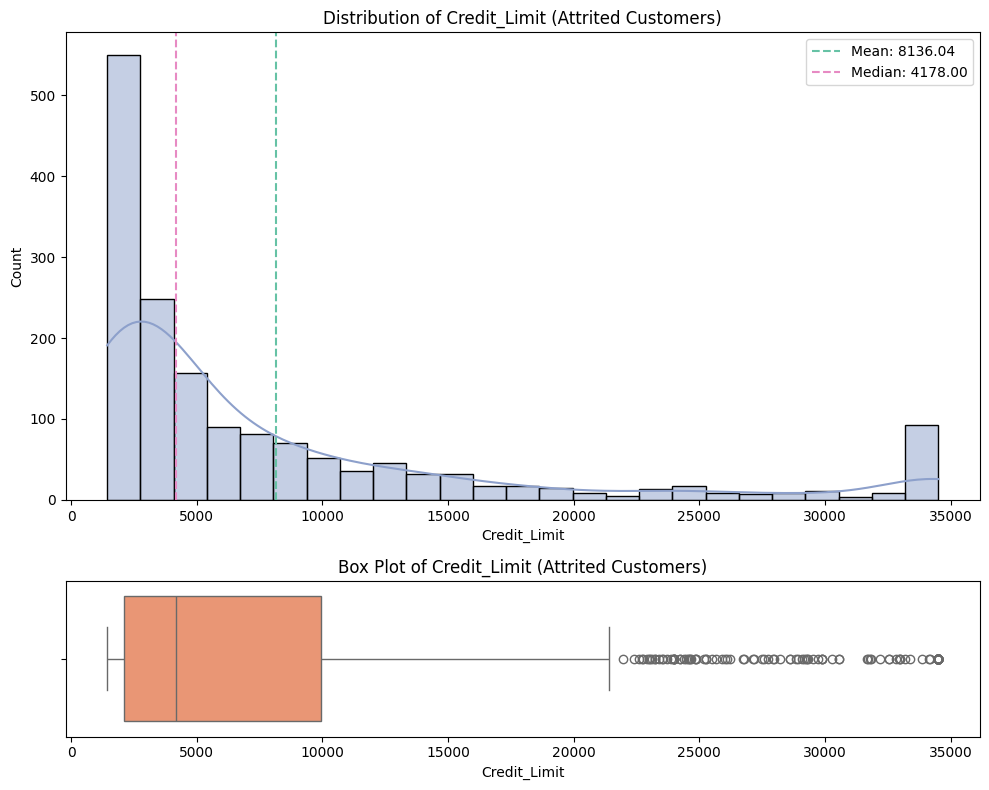

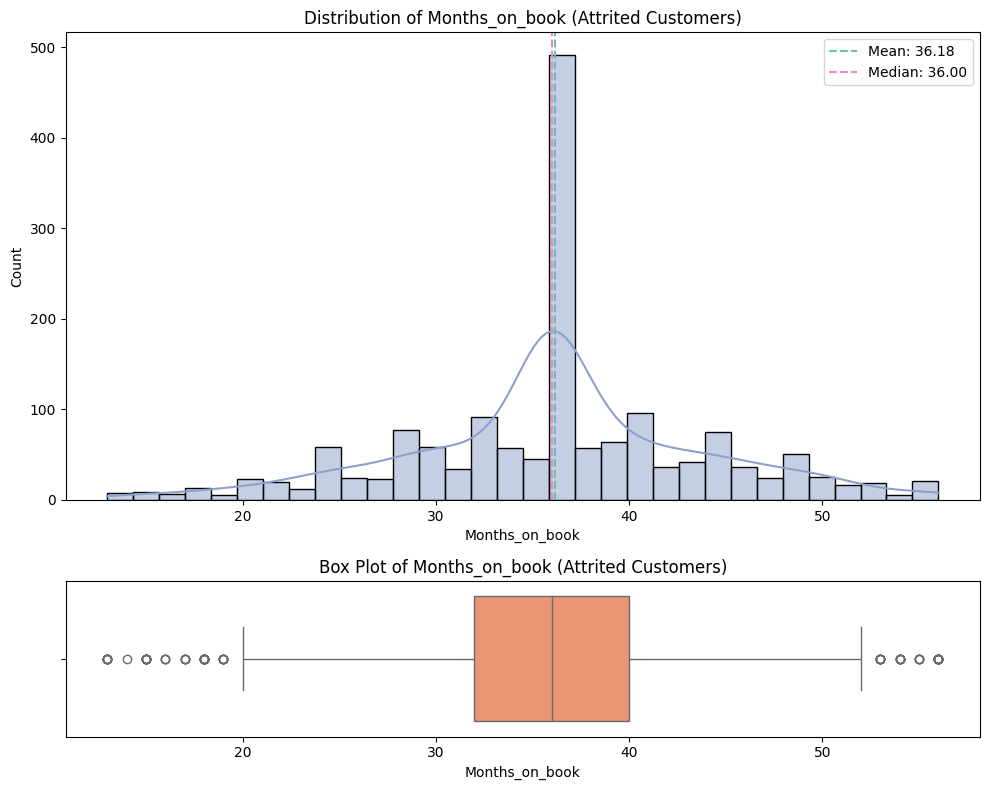

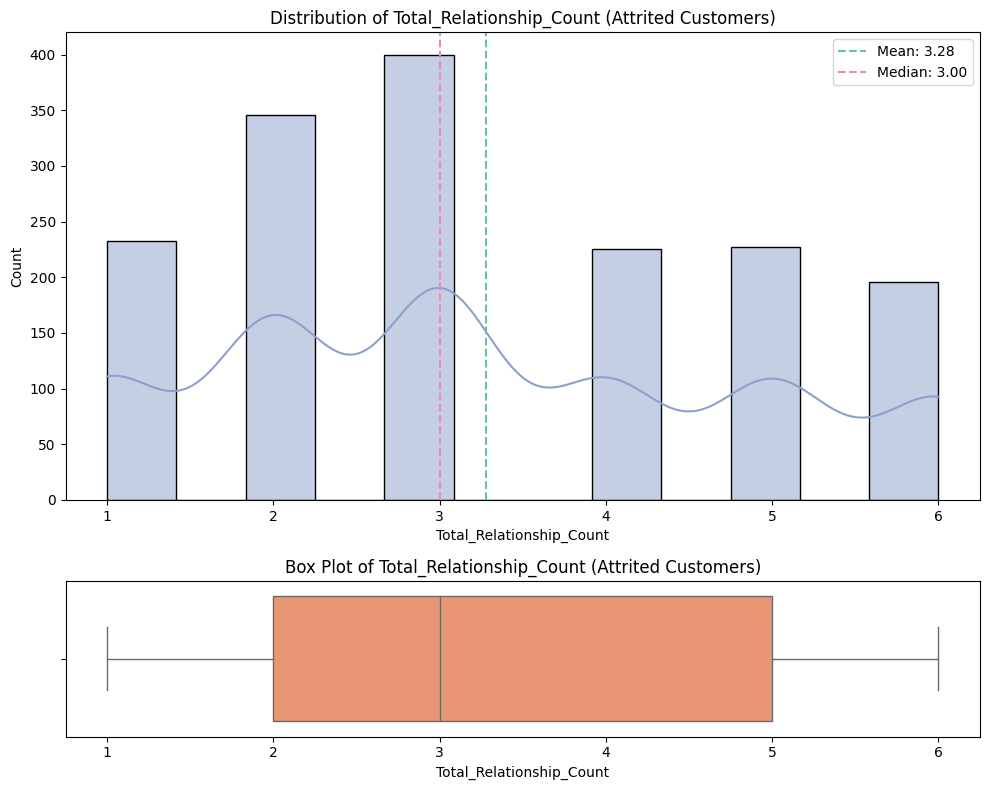

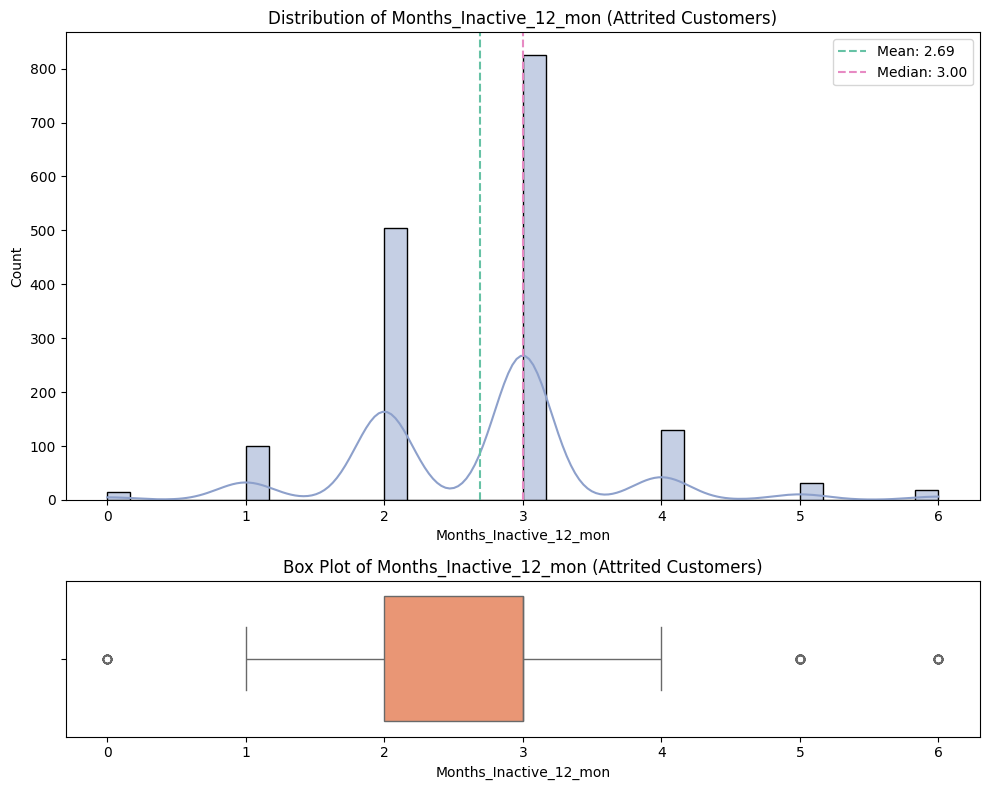

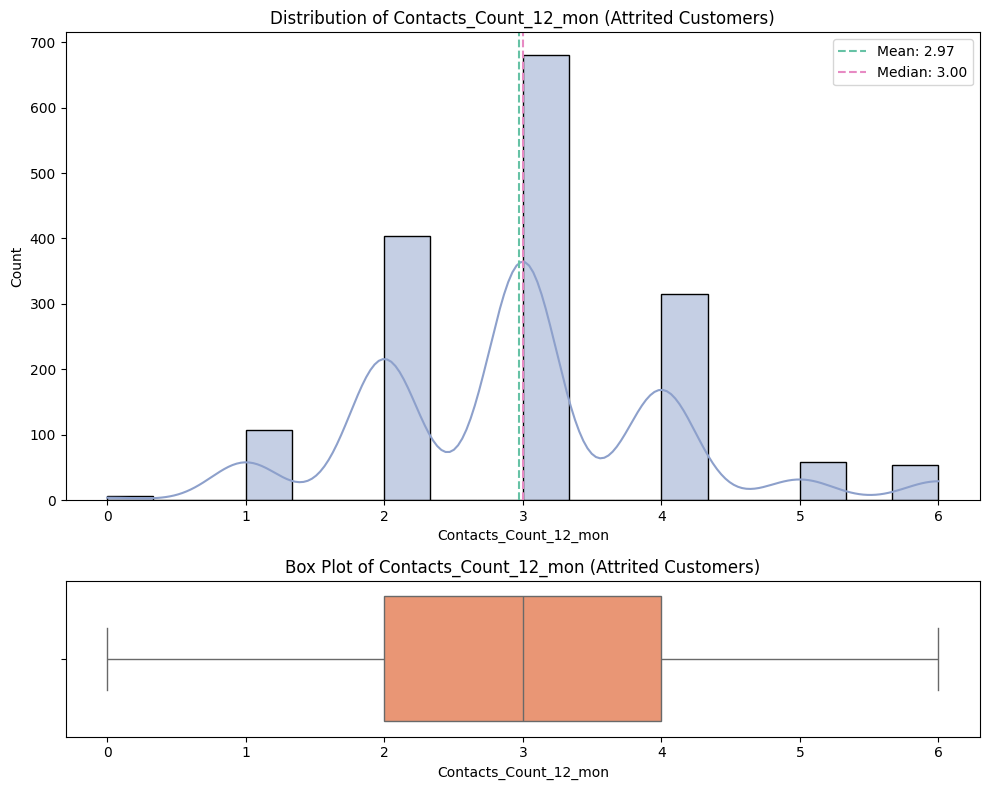

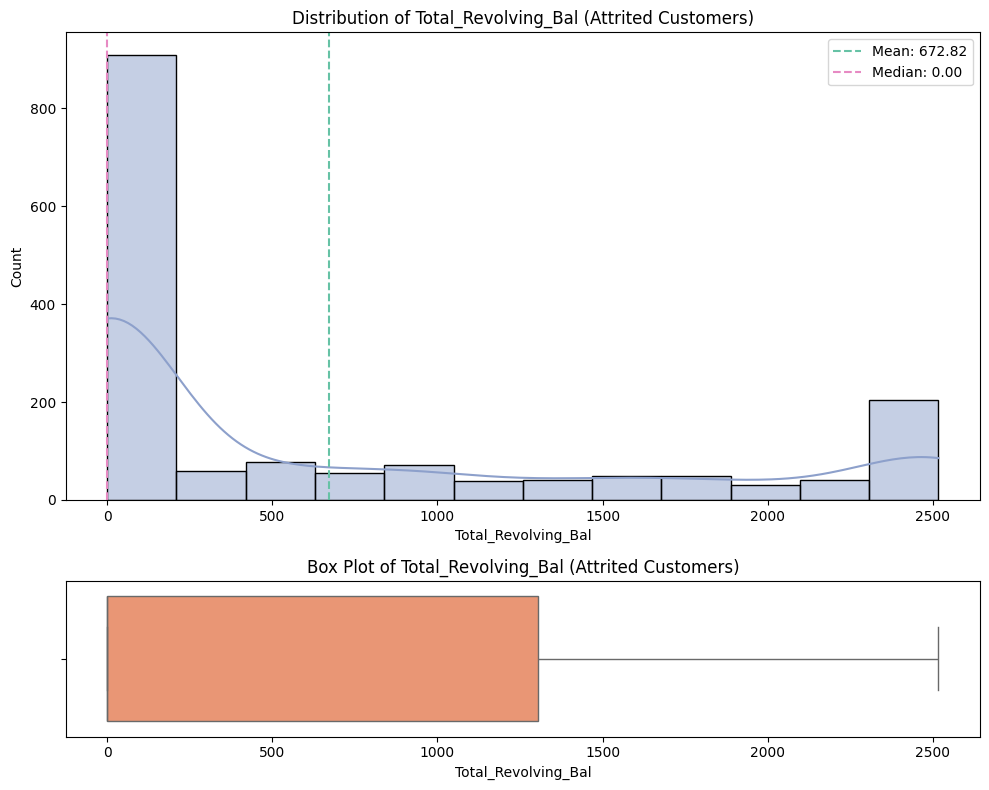

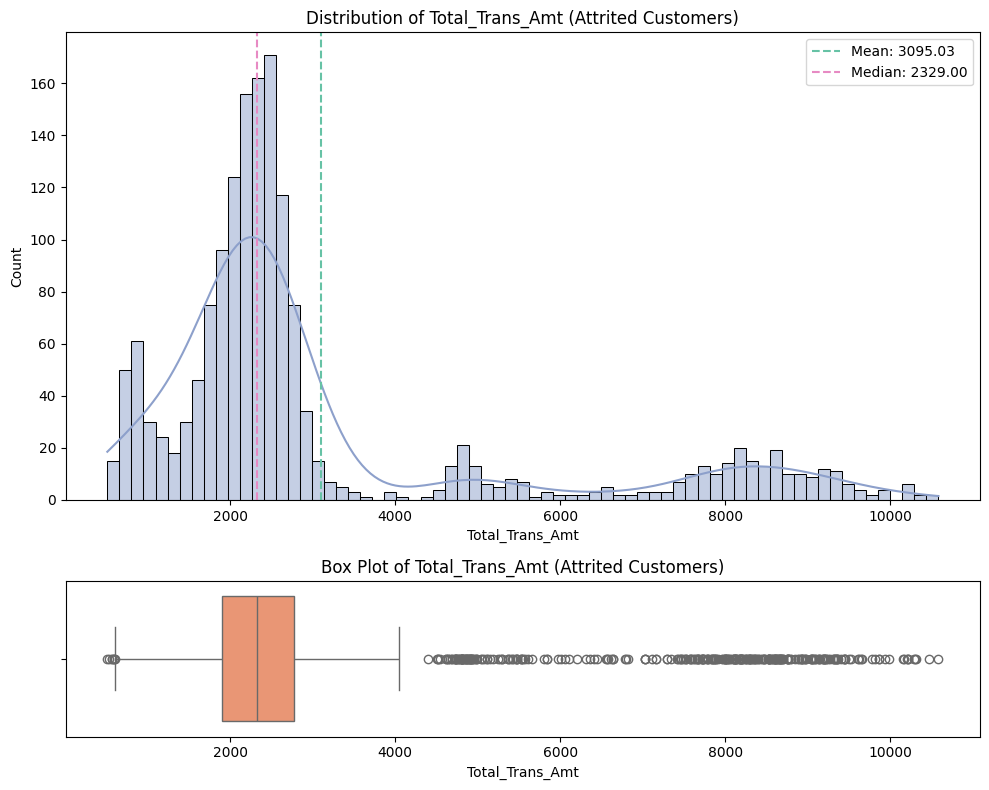

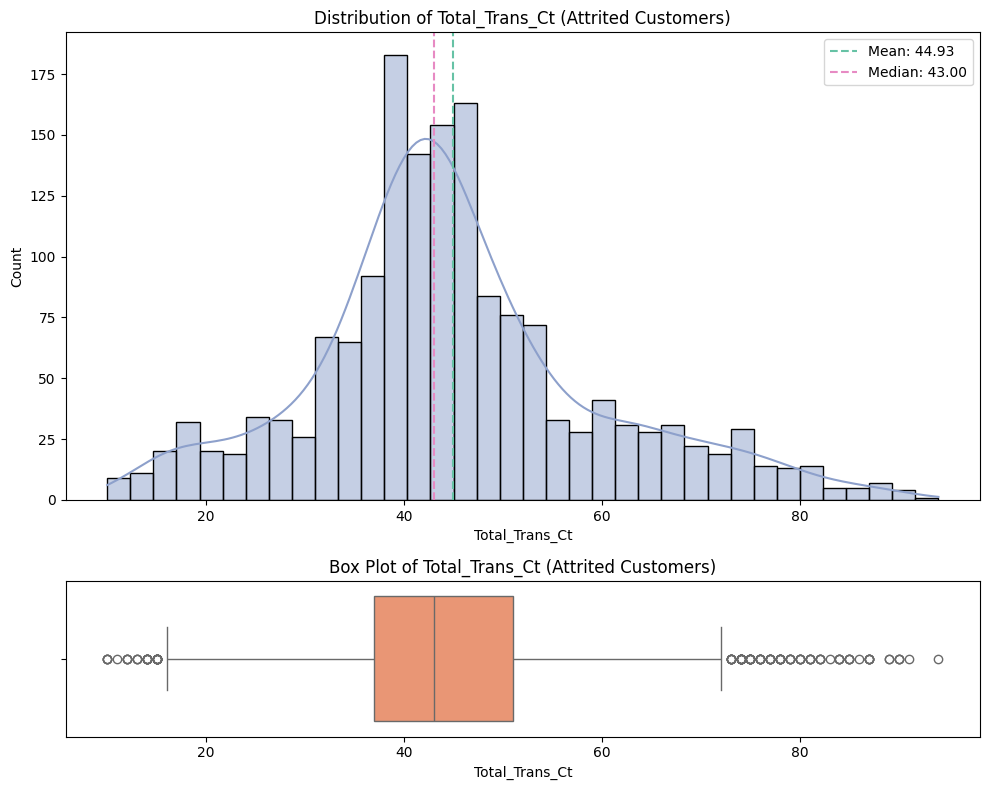

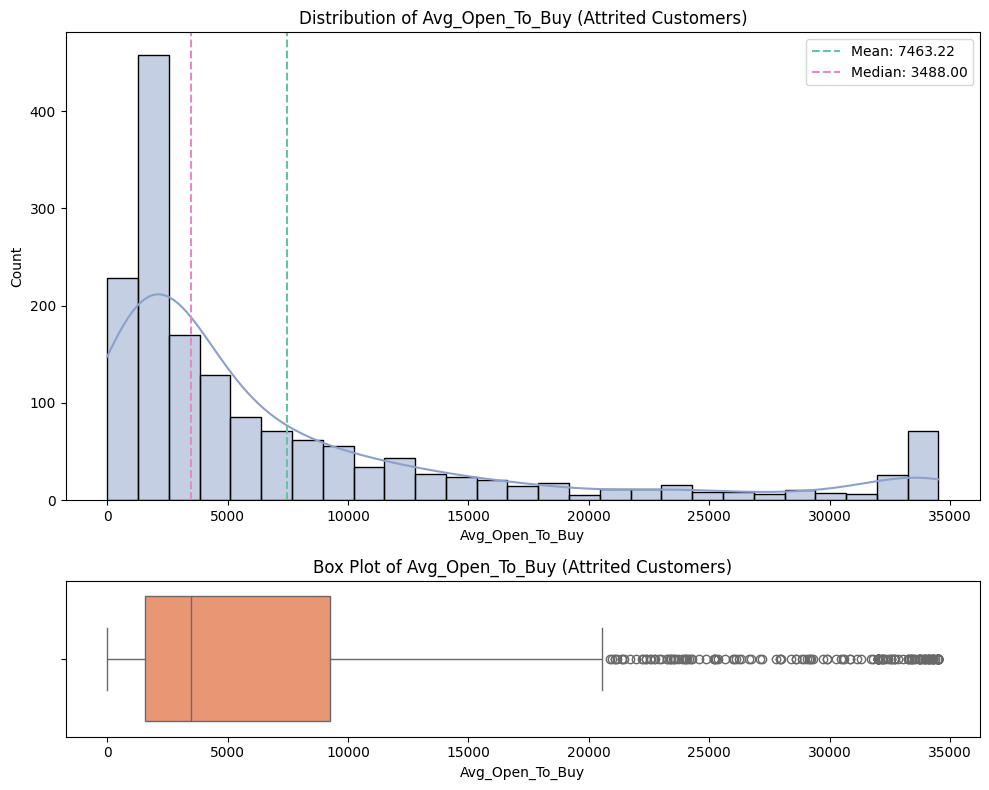

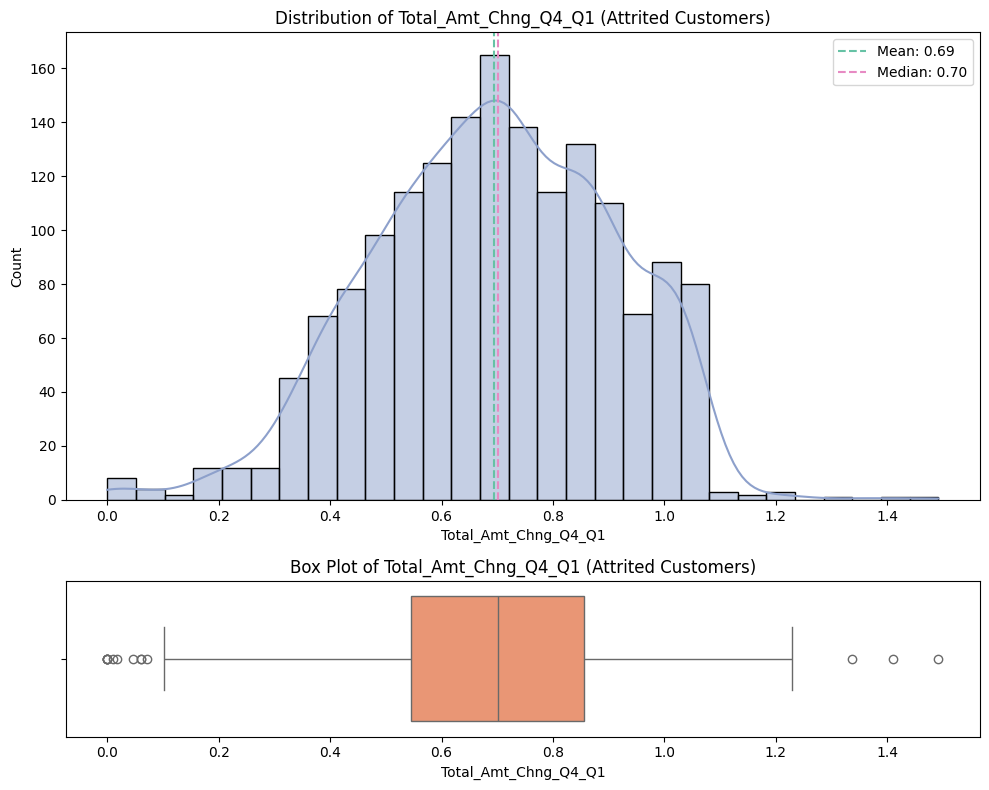

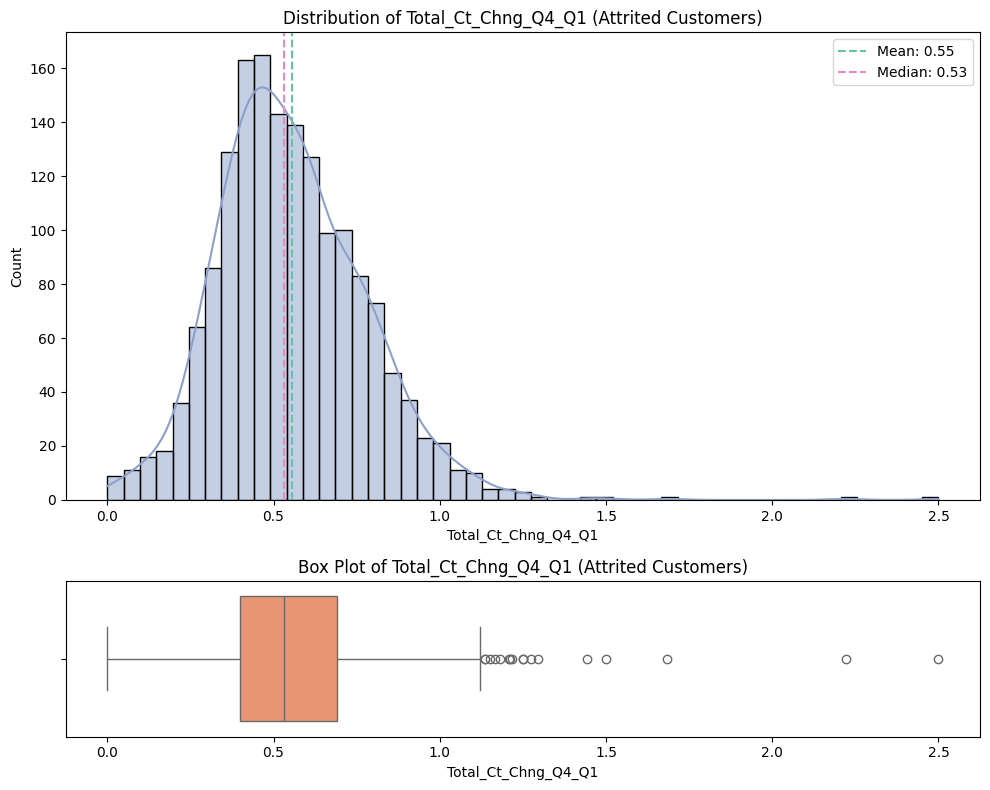

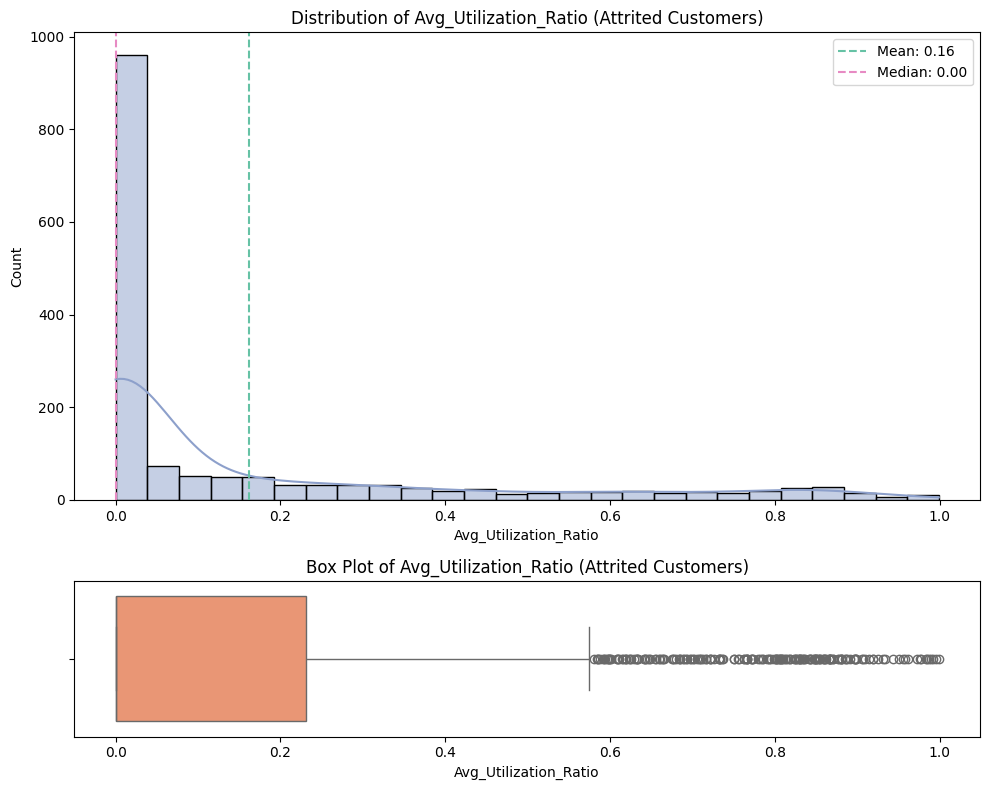

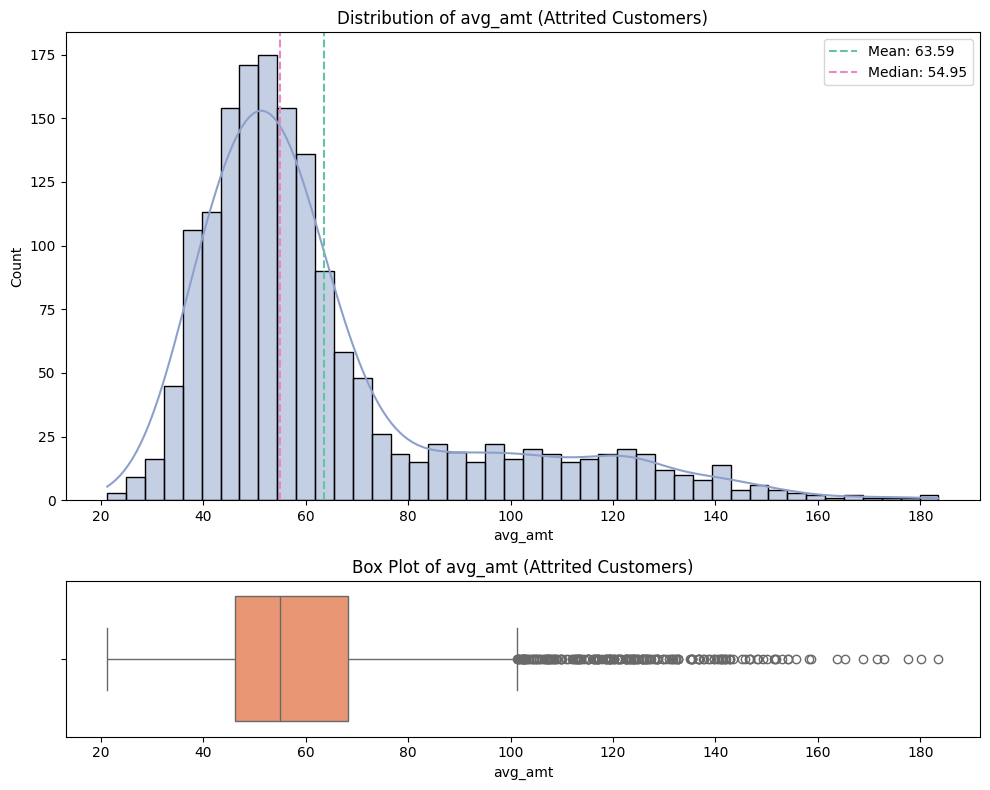

In [ ]:
# FOR ATTRITED CUSTOMERS
# Colors from seaborn Set2 palette
hist_color = '#8DA0CB'
box_color = '#FC8D62'
mean_line_color = '#66C2A5'
median_line_color = '#E78AC3'

# Creating Attrited Customer Distribution charts for Numerical columns
for num_col1 in data_num_col:
    data_col1 = data_attrited_customer[num_col1]
    mean_val1 = data_col1.mean()
    median_val1 = data_col1.median()

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Histogram
    sns.histplot(data=data_col1, color=hist_color, kde=True, ax=axes[0])
    axes[0].axvline(mean_val1, color=mean_line_color, linestyle='--', label=f'Mean: {mean_val1:.2f}')
    axes[0].axvline(median_val1, color=median_line_color, linestyle='--', label=f'Median: {median_val1:.2f}')
    axes[0].set_title(f'Distribution of {num_col1} (Attrited Customers)')
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=data_col1, color=box_color, ax=axes[1])
    axes[1].set_title(f'Box Plot of {num_col1} (Attrited Customers)')
    axes[1].set_xlabel(num_col1)
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()


# Bivariate Analysis of Numerical Columns

In [ ]:
import pandas as pd

# Select numerical columns
num_cols = data_num_col

# Create a copy to work on
data_clean = data.copy()

# Loop through each numerical column to apply IQR filter
for col in num_cols:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    data_clean = data_clean[(data_clean[col] >= lower_bound) & (data_clean[col] <= upper_bound)]

# Check the shape before and after
print("Original shape:", data.shape)
print("Shape after removing outliers:", data_clean.shape)

Original shape: (10127, 21)
Shape after removing outliers: (6106, 21)


In [ ]:
new_data_existing_customer = data_clean[data_clean['Attrition_Flag']=='Existing Customer']
new_data_attrited_customer = data_clean[data_clean['Attrition_Flag']=='Attrited Customer']

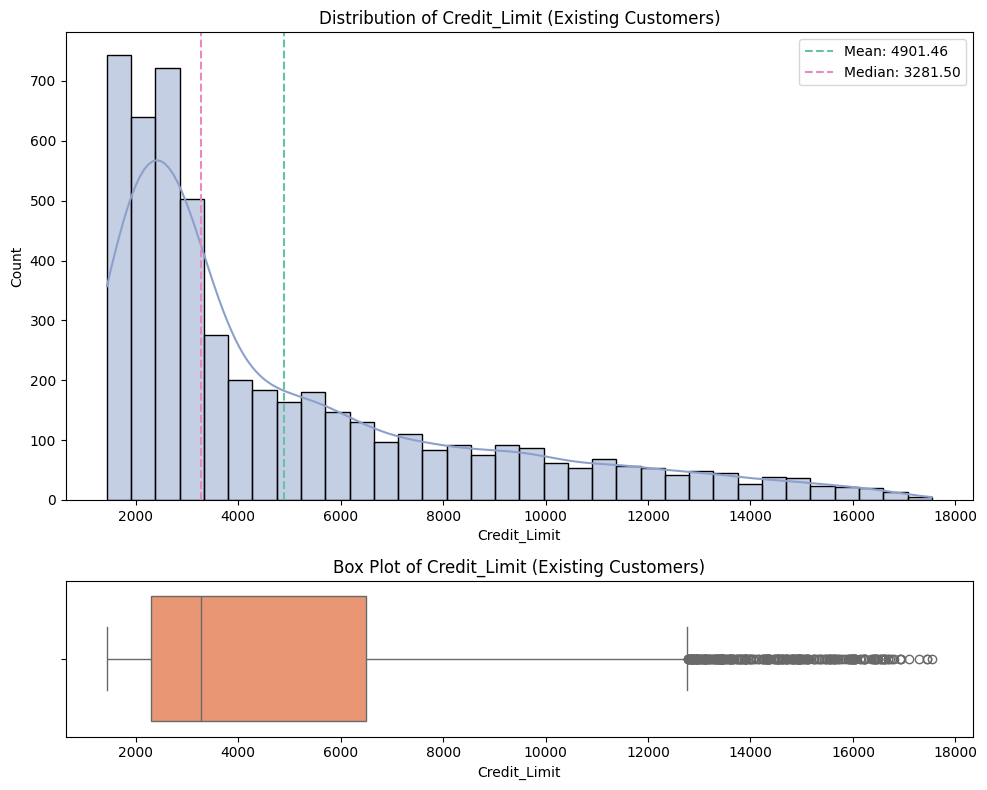

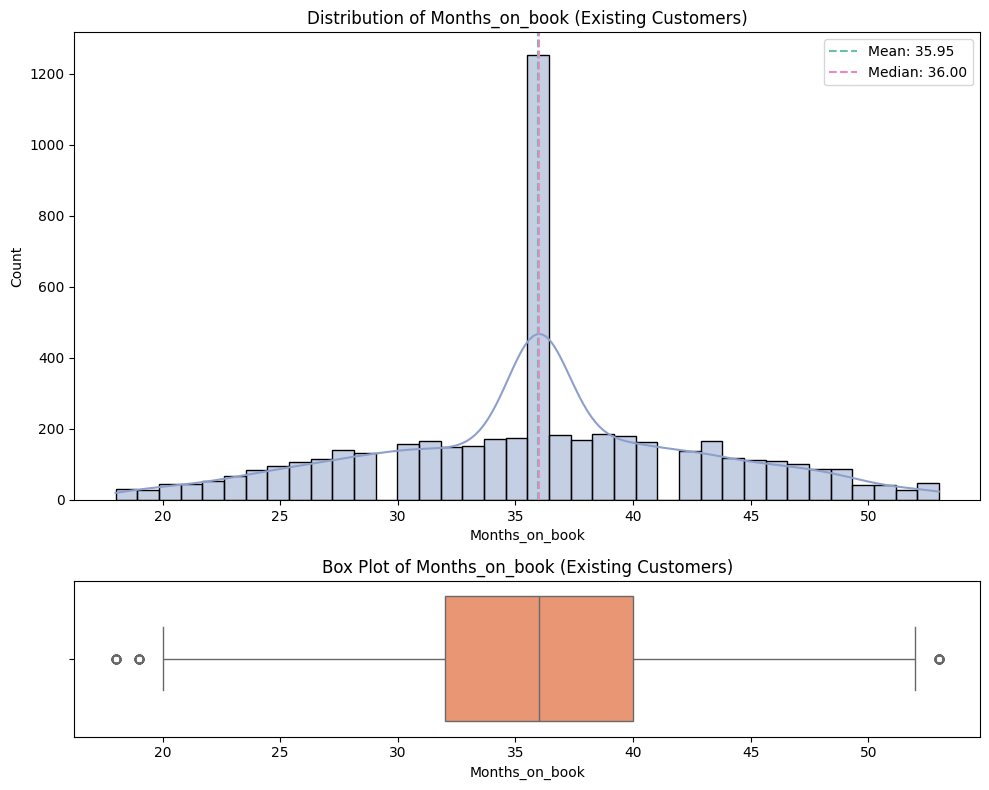

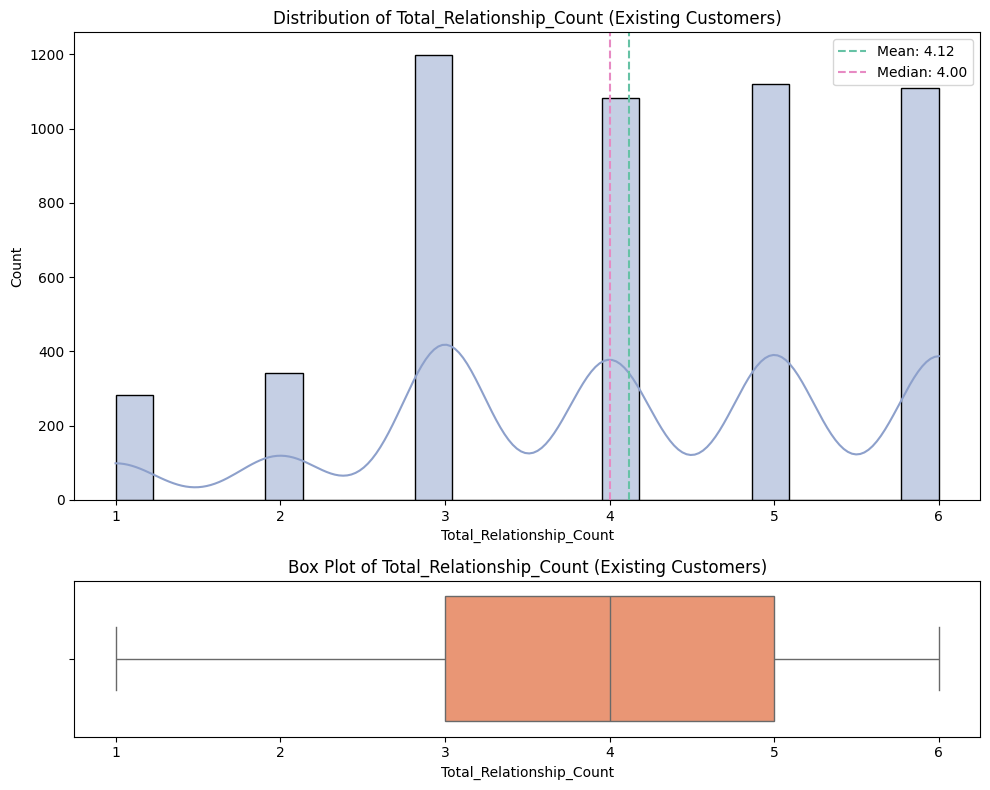

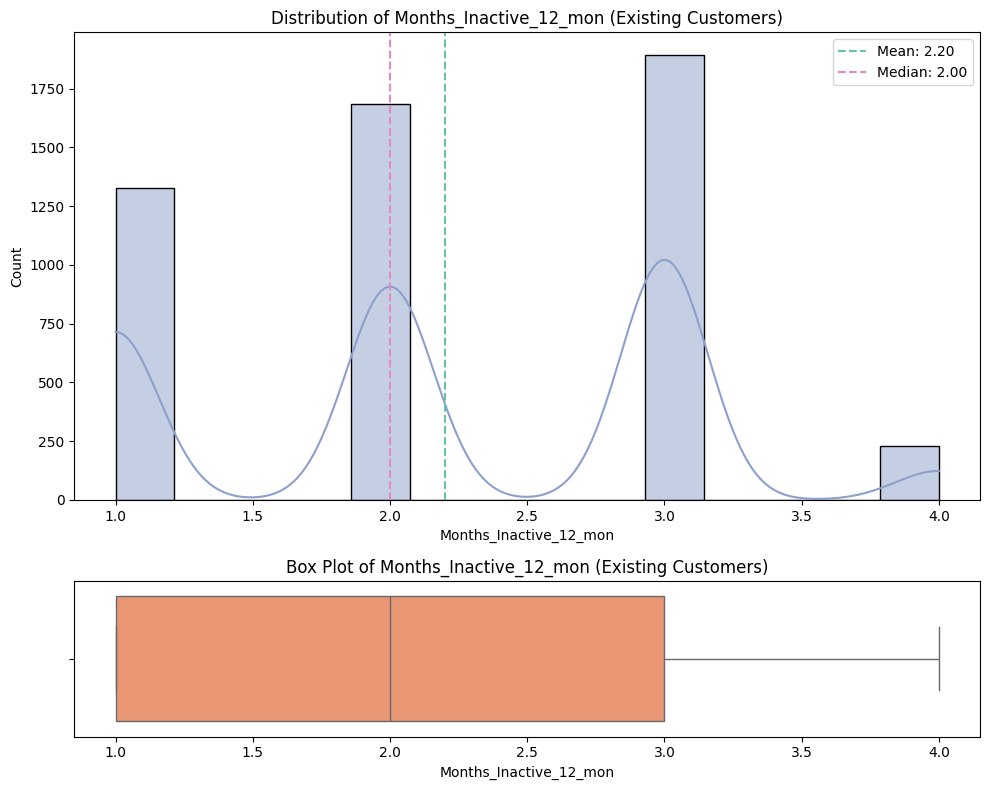

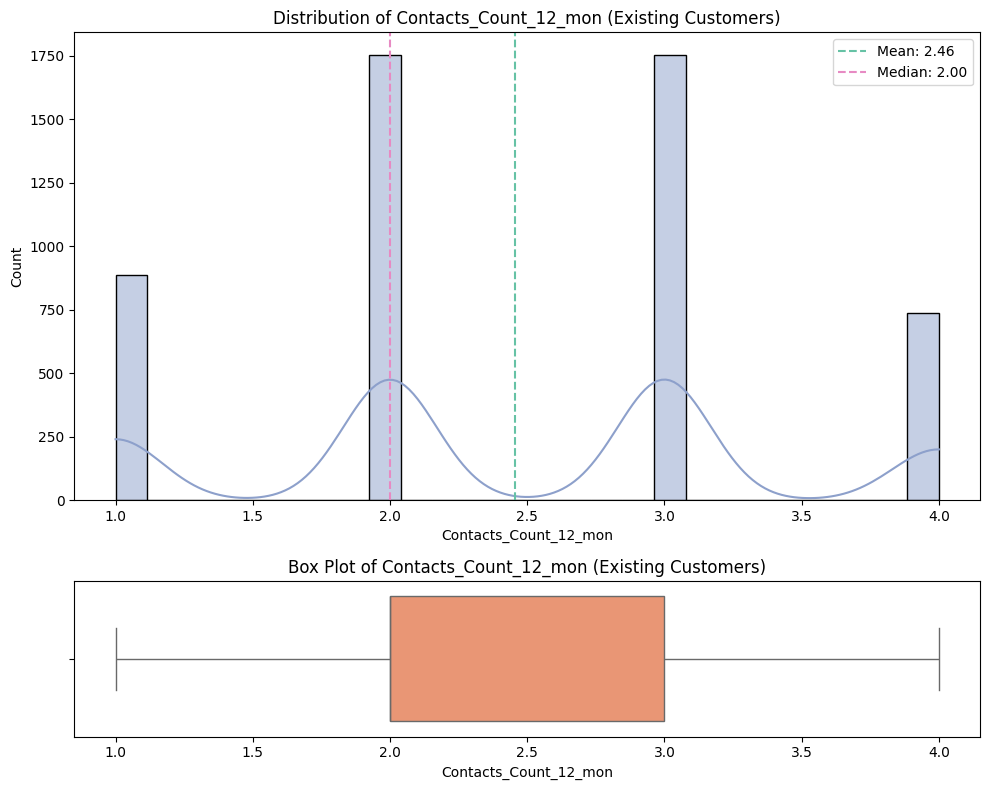

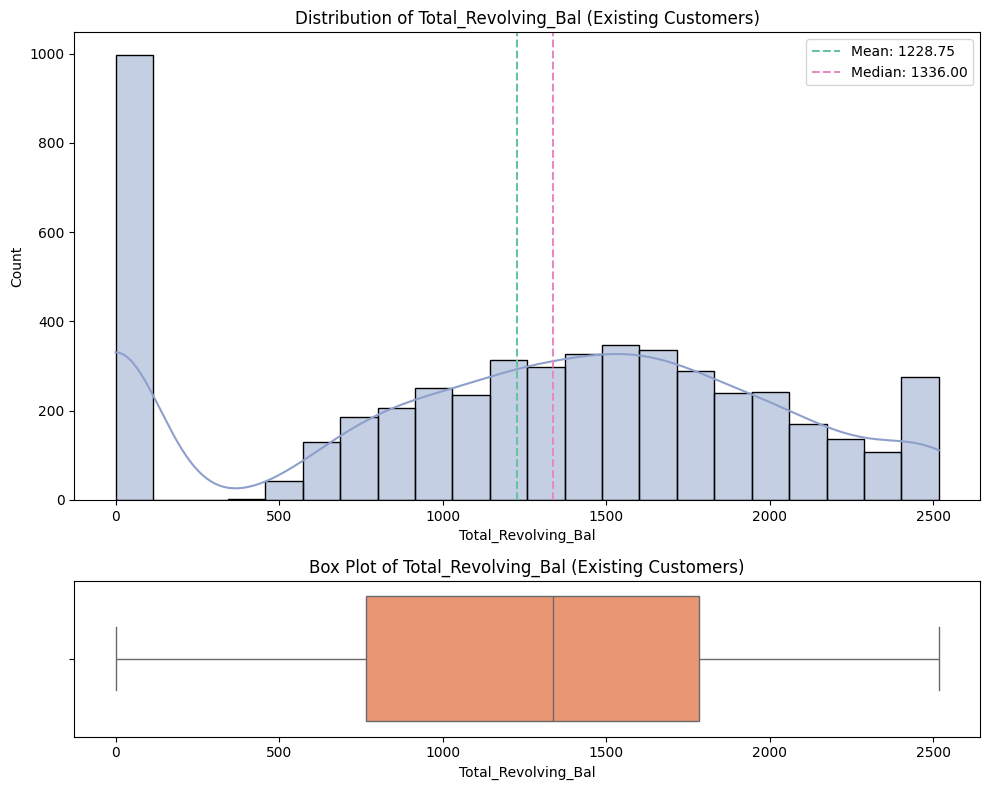

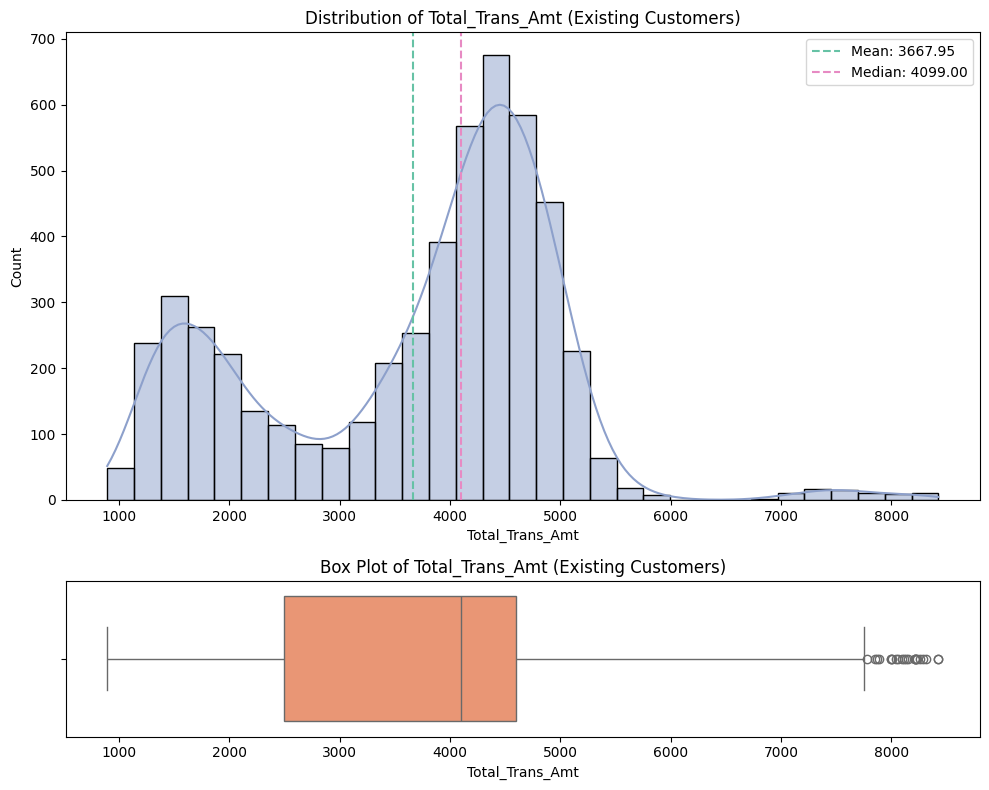

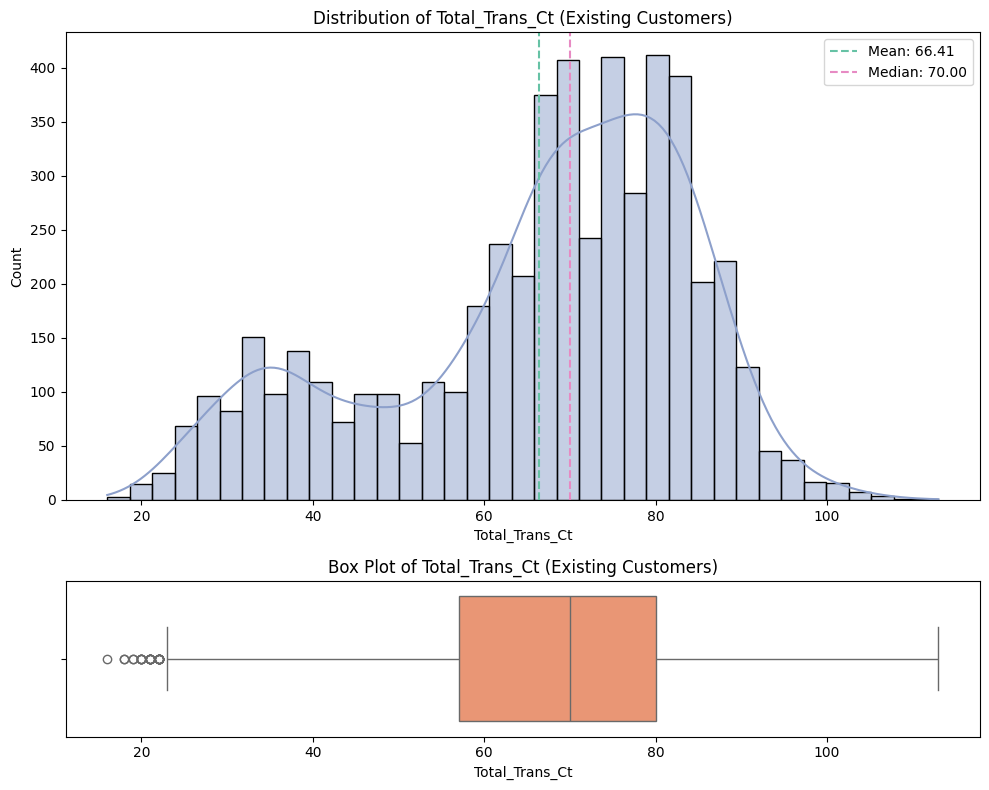

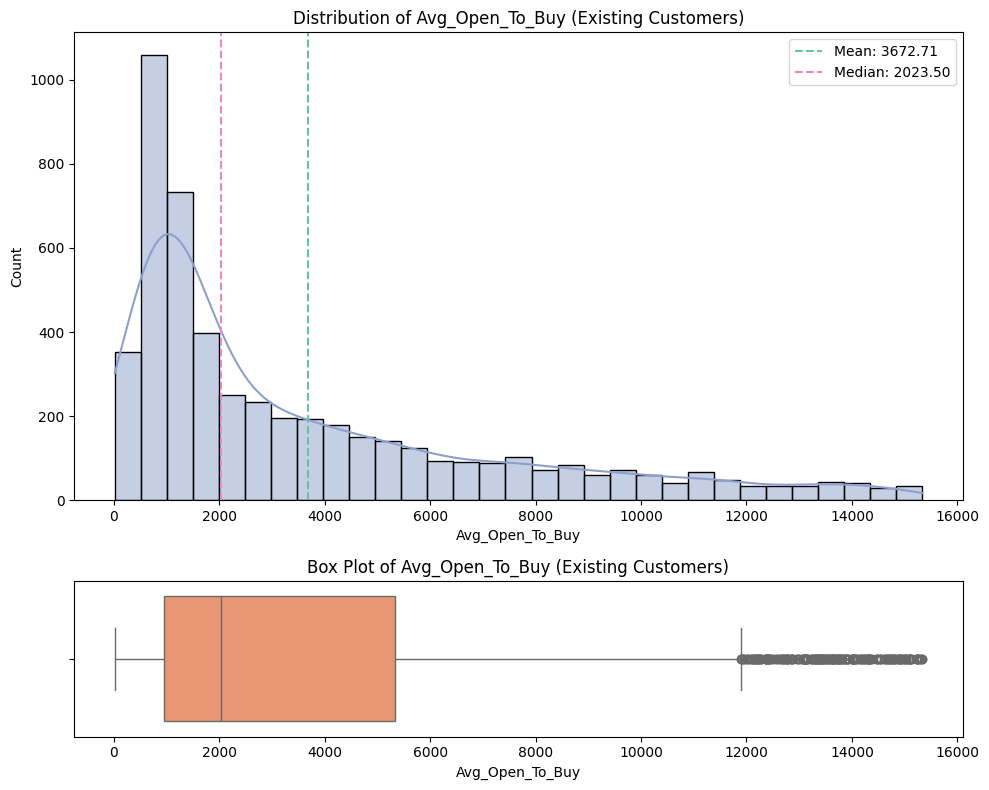

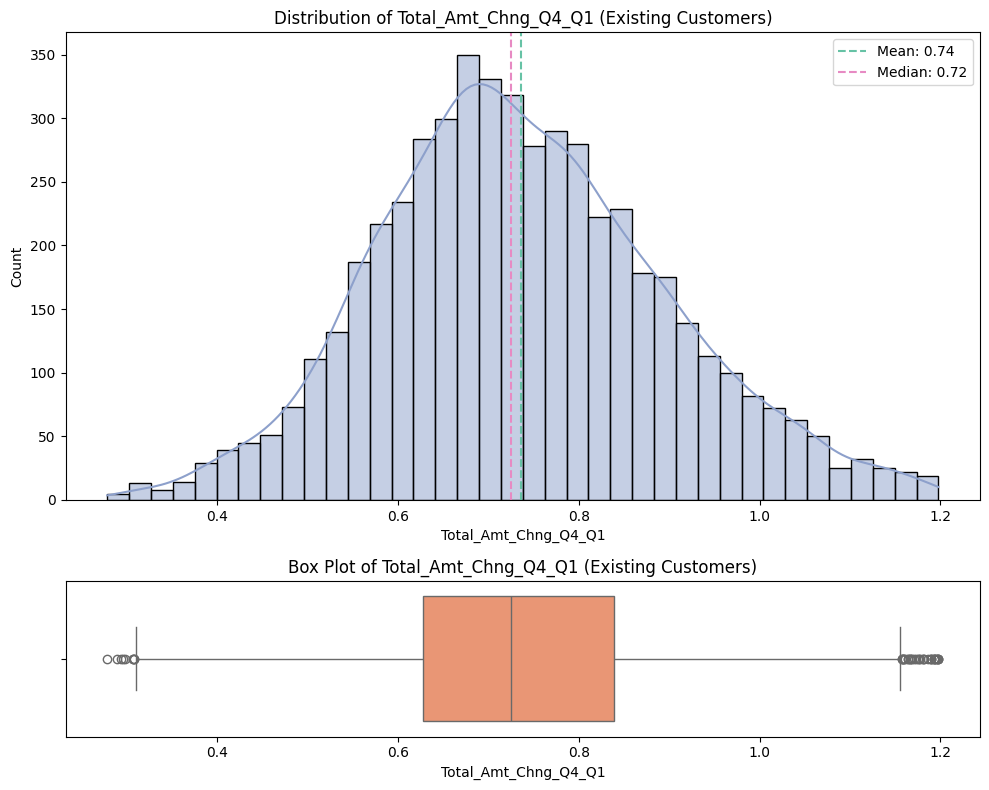

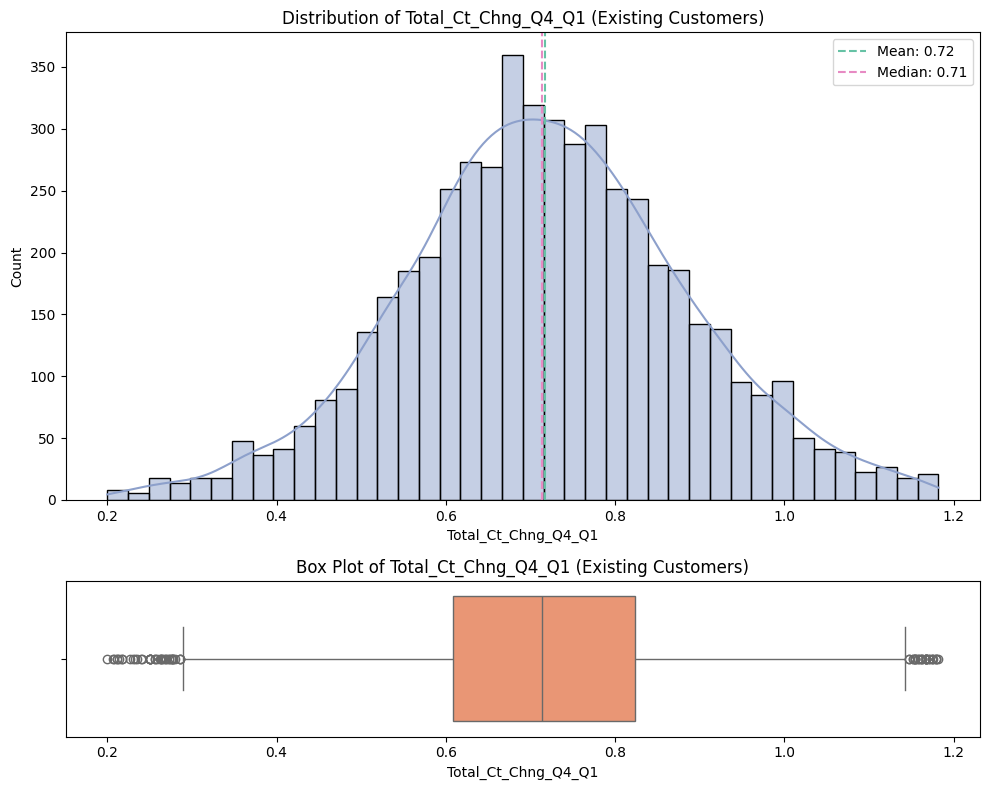

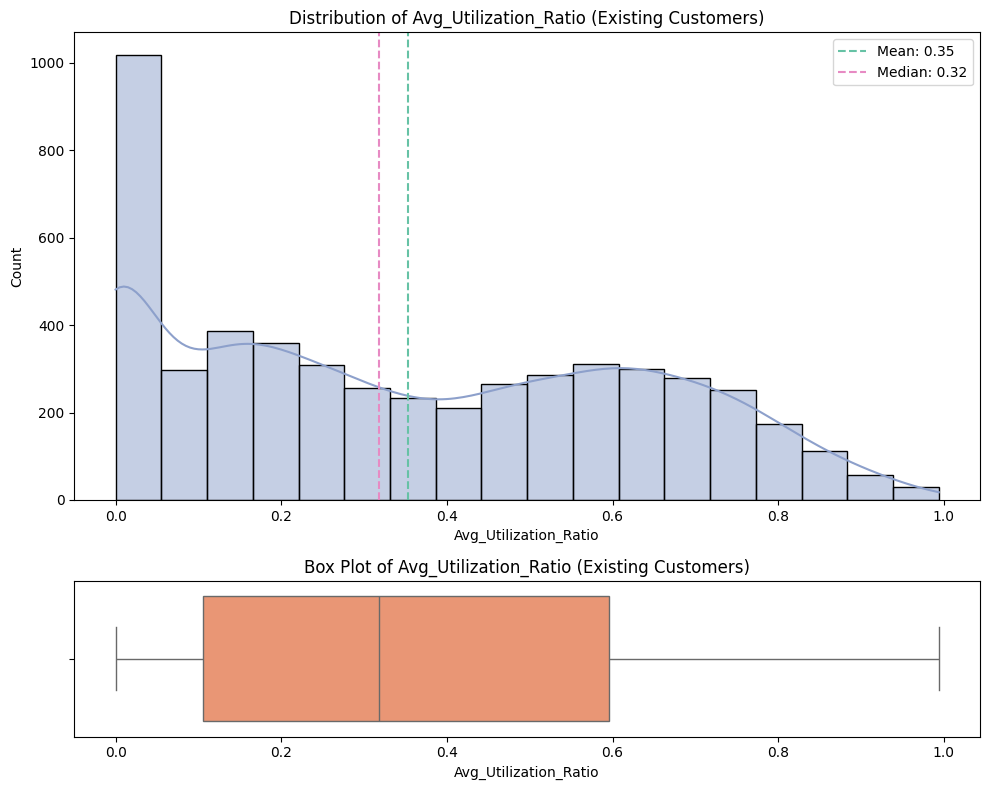

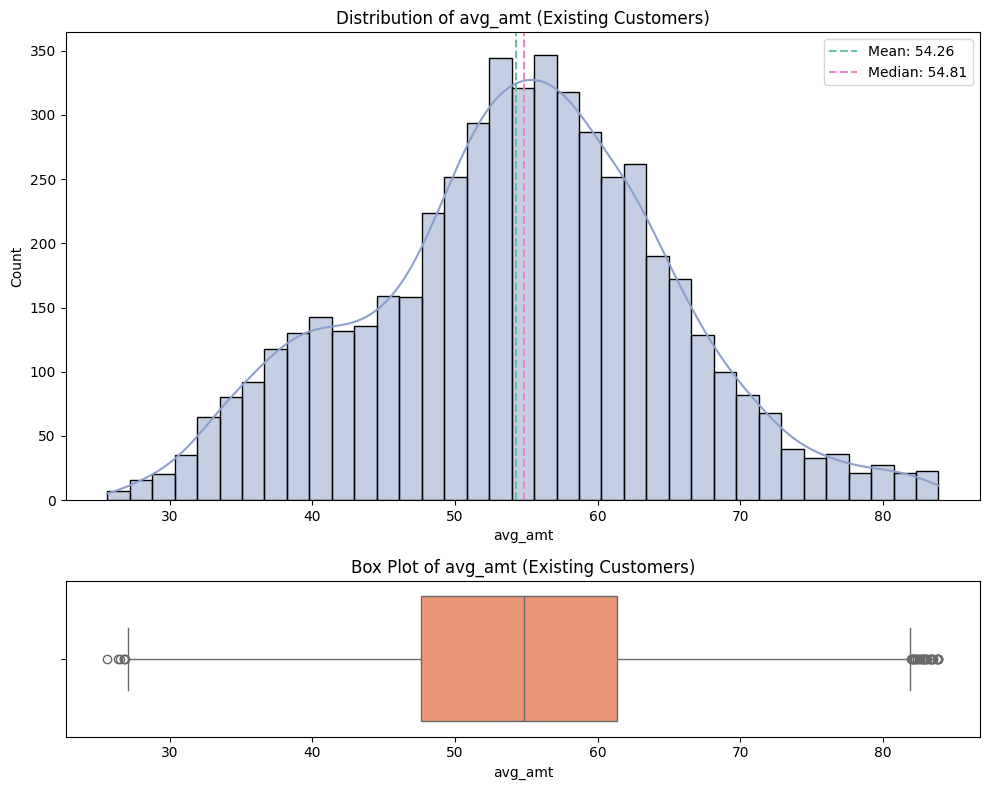

In [ ]:
# FOR EXISTING COLUMNS AFTER REMOVING OUTLIERS

# Colors from seaborn Set2 palette
hist_color = '#8DA0CB'   # light blue/purple for histogram (Set2[2])
box_color = '#FC8D62'    # orange (Set2[1])
mean_line_color = '#66C2A5'   # green (Set2[0])
median_line_color = '#E78AC3' # pink (Set2[3])

# Creating Attrited Customer Distribution charts for Numerical columns
for num_col1 in data_num_col:
    data_col1 = new_data_existing_customer[num_col1]
    mean_val1 = data_col1.mean()
    median_val1 = data_col1.median()

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Histogram
    sns.histplot(data=data_col1, color=hist_color, kde=True, ax=axes[0])
    axes[0].axvline(mean_val1, color=mean_line_color, linestyle='--', label=f'Mean: {mean_val1:.2f}')
    axes[0].axvline(median_val1, color=median_line_color, linestyle='--', label=f'Median: {median_val1:.2f}')
    axes[0].set_title(f'Distribution of {num_col1} (Existing Customers)')
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=data_col1, color=box_color, ax=axes[1])
    axes[1].set_title(f'Box Plot of {num_col1} (Existing Customers)')
    axes[1].set_xlabel(num_col1)
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()


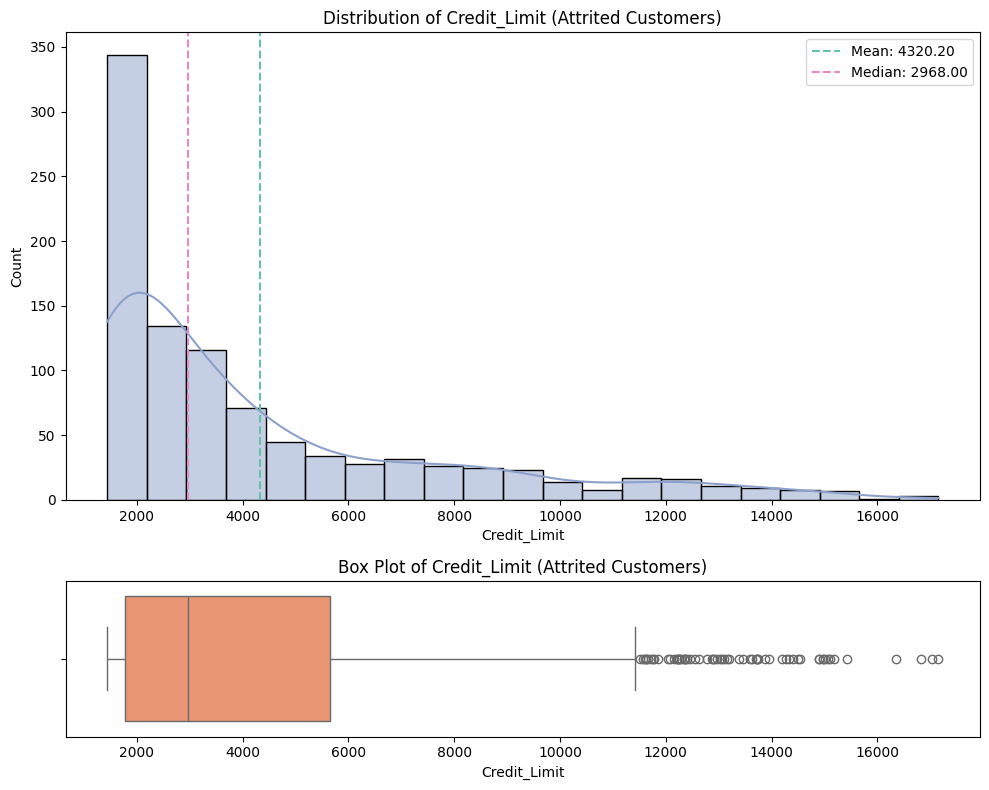

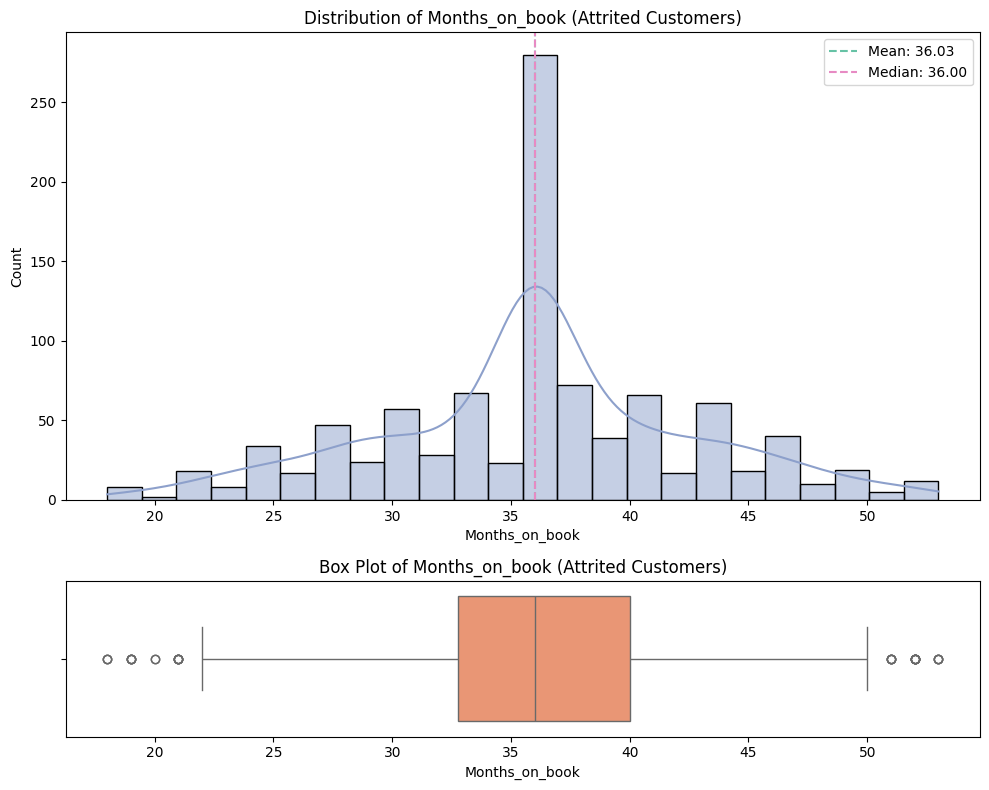

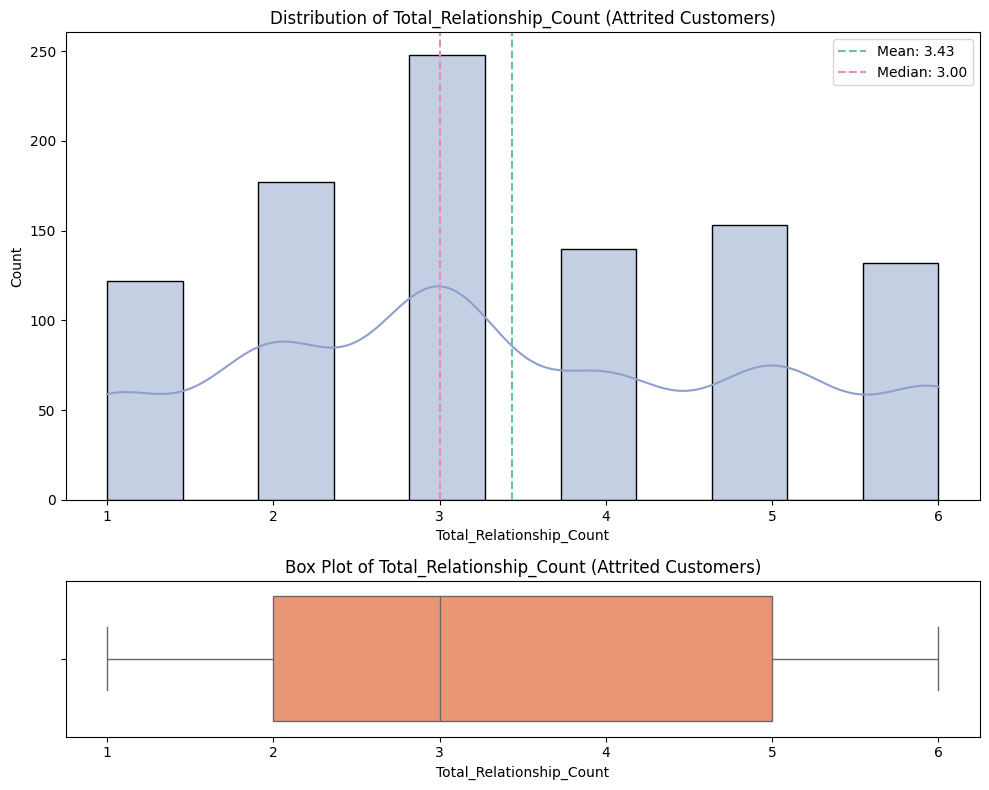

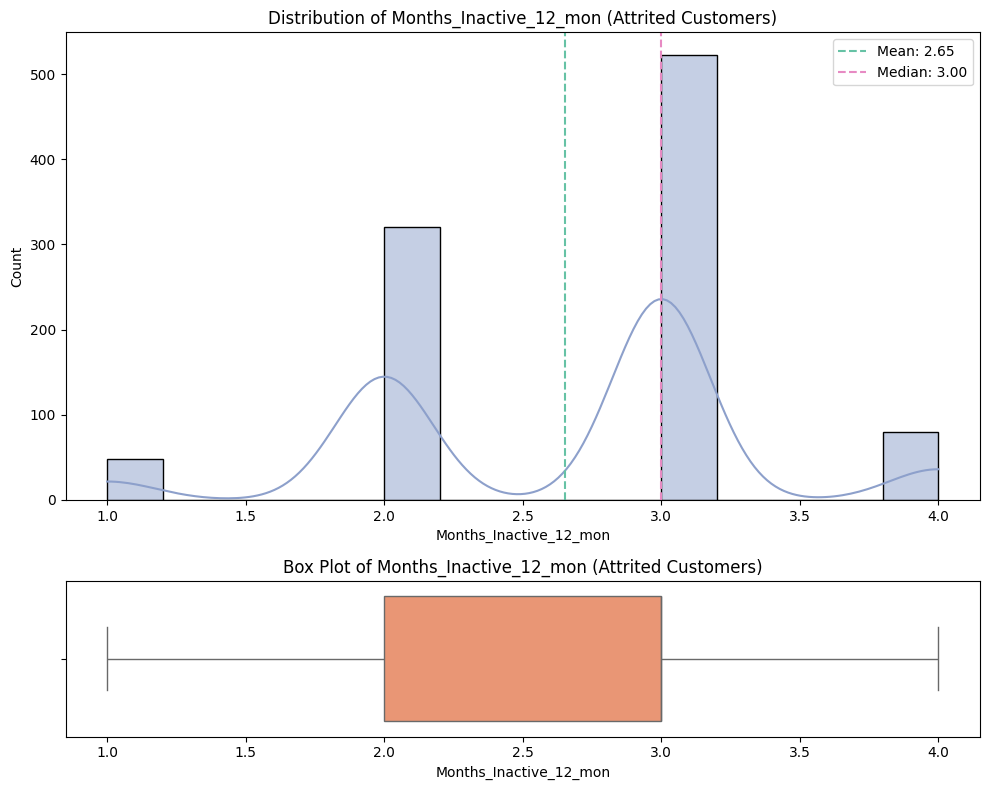

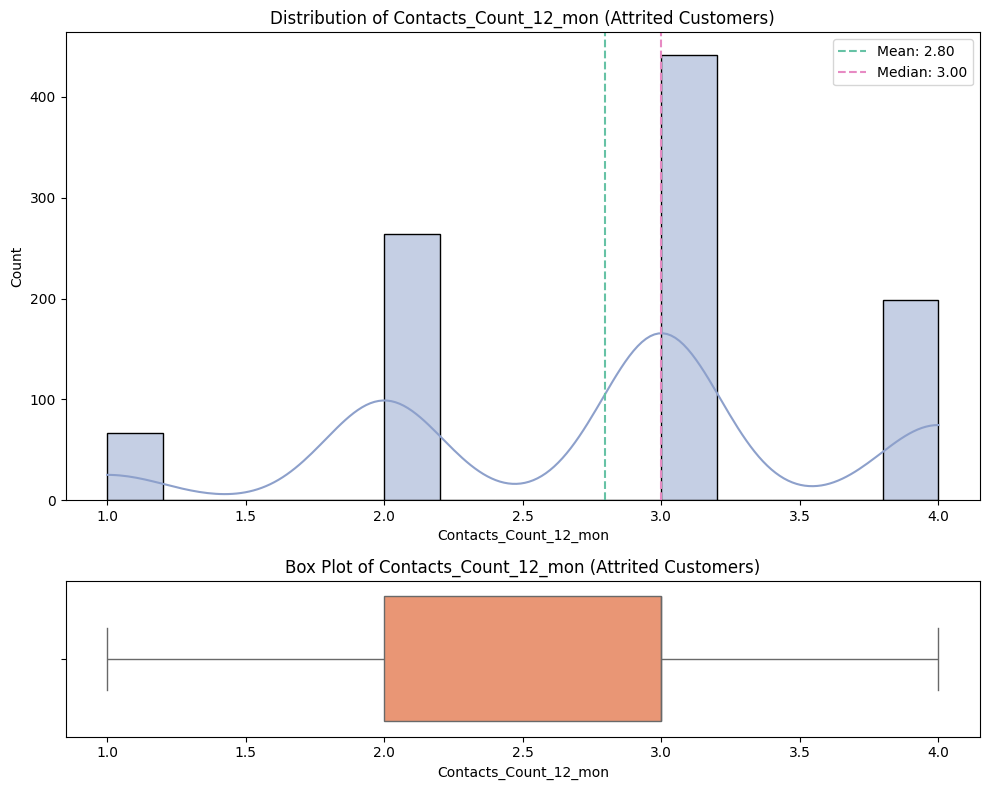

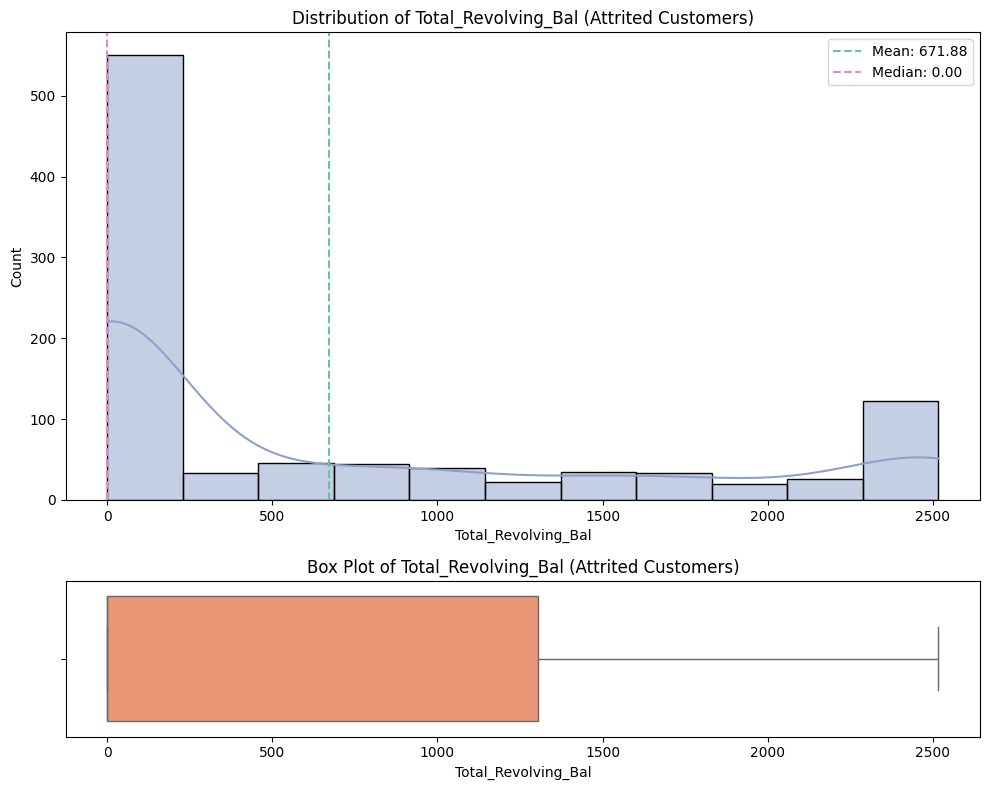

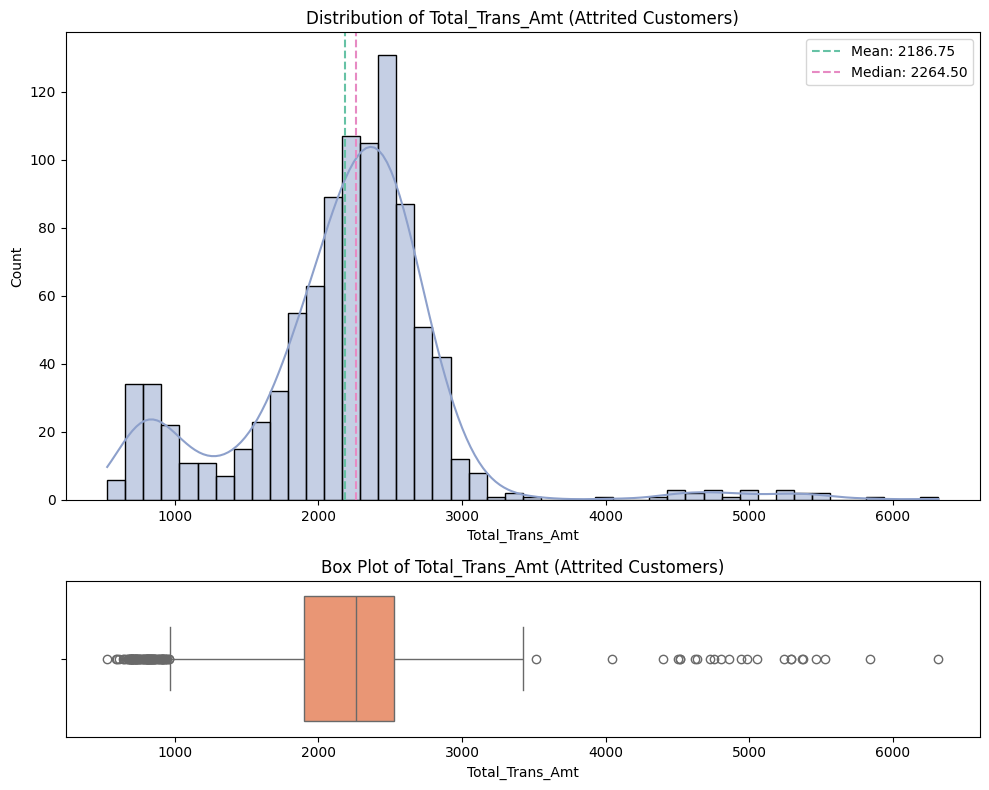

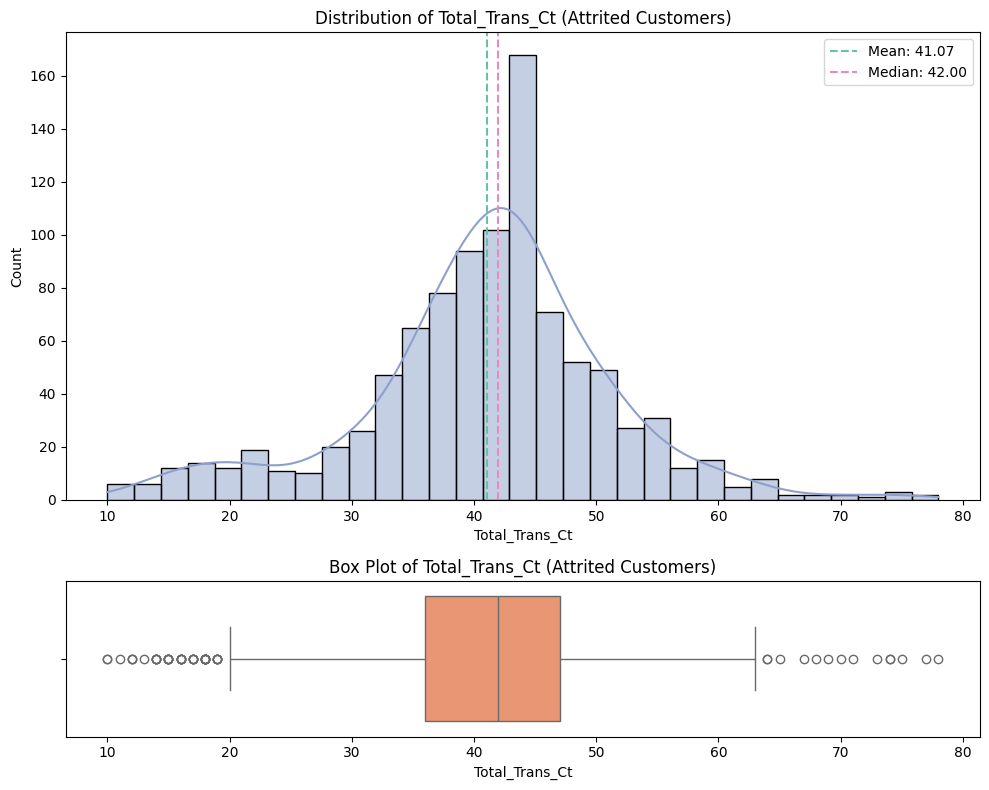

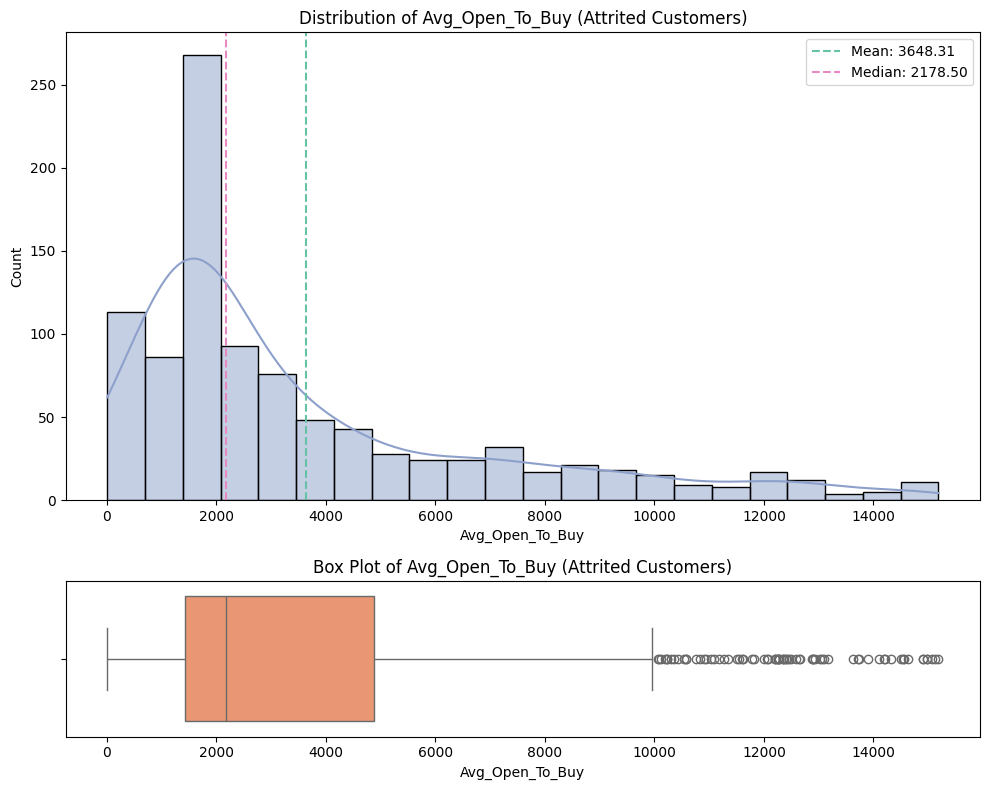

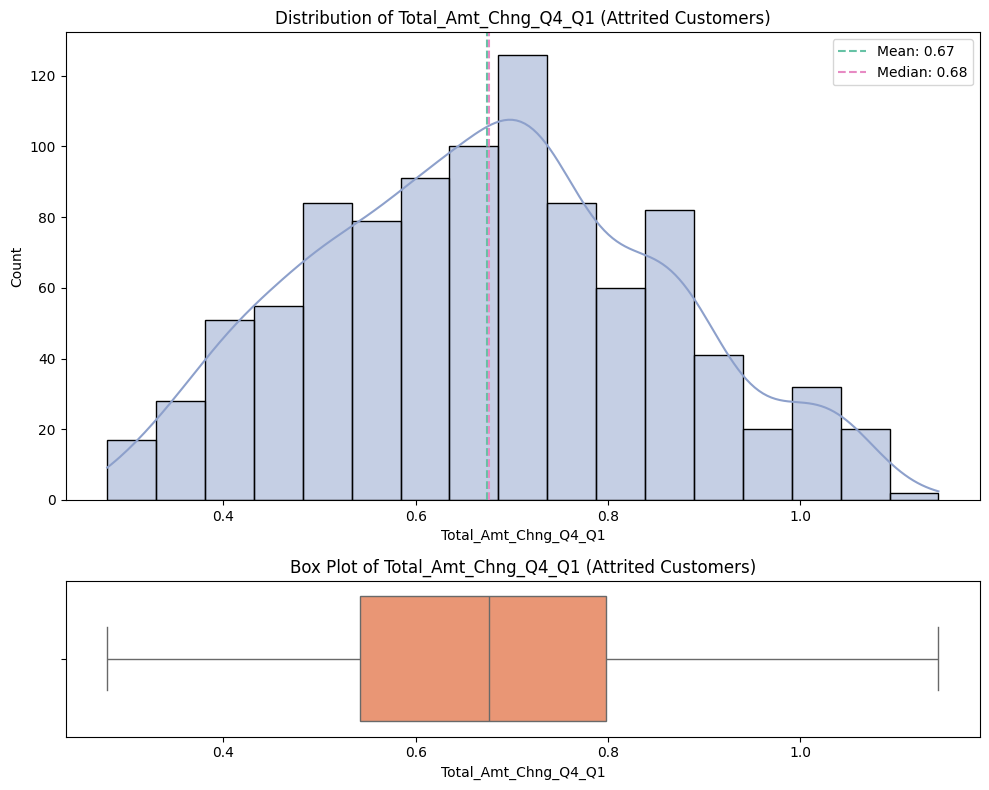

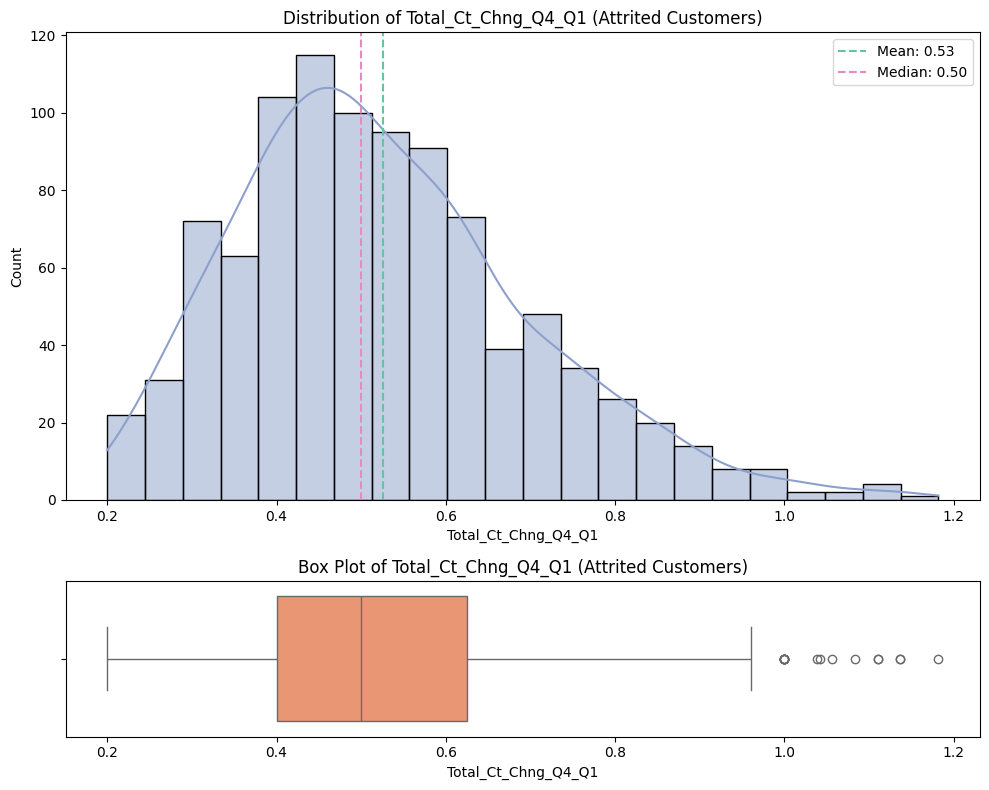

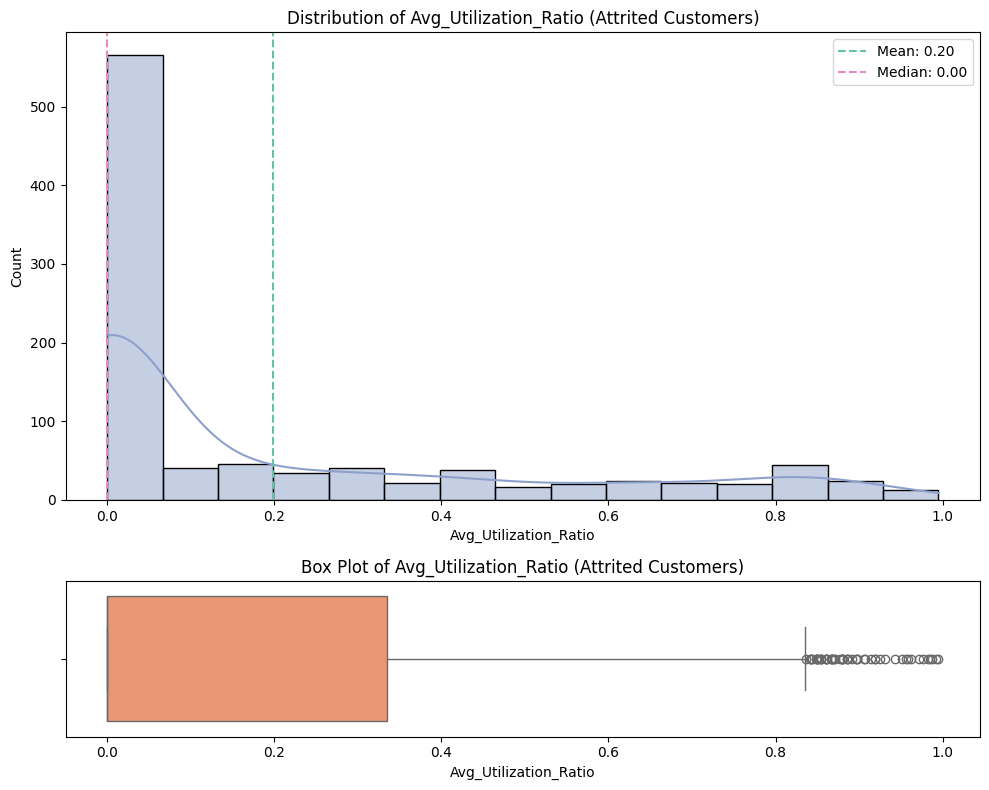

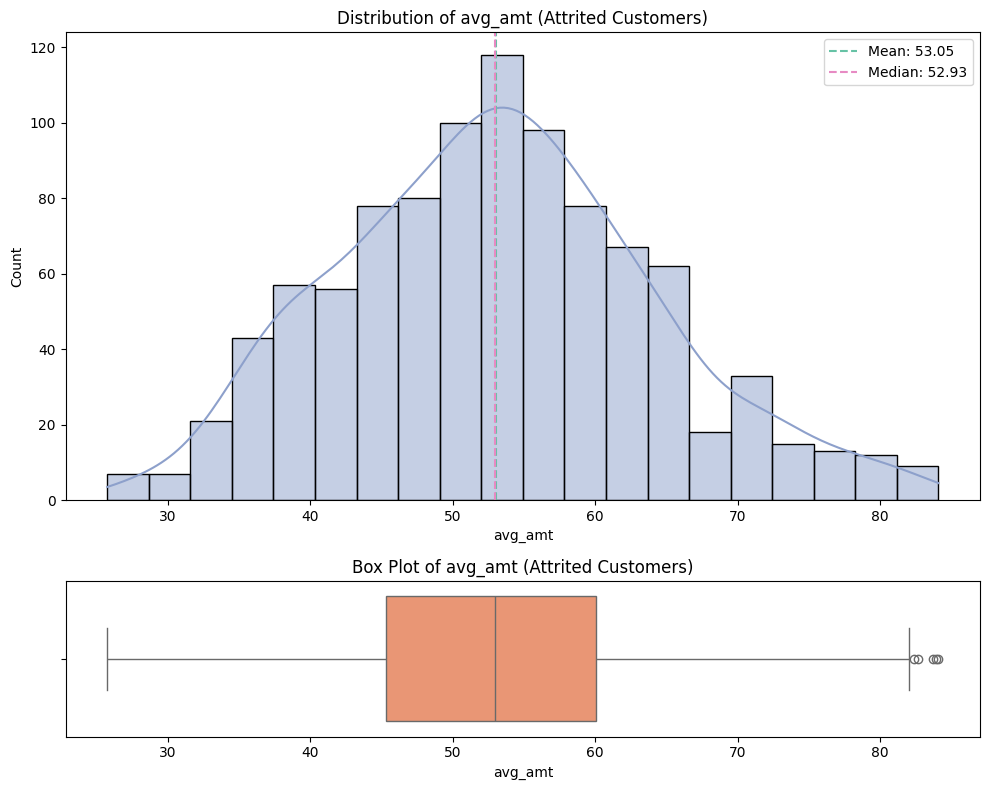

In [ ]:
#FOR ATTRITED CUSTOMERS AFTER REMOVING OUTLIERS

# Colors from seaborn Set2 palette
hist_color = '#8DA0CB'   # light blue/purple for histogram (Set2[2])
box_color = '#FC8D62'    # orange (Set2[1])
mean_line_color = '#66C2A5'   # green (Set2[0])
median_line_color = '#E78AC3' # pink (Set2[3])

# Creating Attrited Customer Distribution charts for Numerical columns
for num_col1 in data_num_col:
    data_col1 = new_data_attrited_customer[num_col1]
    mean_val1 = data_col1.mean()
    median_val1 = data_col1.median()

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Histogram
    sns.histplot(data=data_col1, color=hist_color, kde=True, ax=axes[0])
    axes[0].axvline(mean_val1, color=mean_line_color, linestyle='--', label=f'Mean: {mean_val1:.2f}')
    axes[0].axvline(median_val1, color=median_line_color, linestyle='--', label=f'Median: {median_val1:.2f}')
    axes[0].set_title(f'Distribution of {num_col1} (Attrited Customers)')
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=data_col1, color=box_color, ax=axes[1])
    axes[1].set_title(f'Box Plot of {num_col1} (Attrited Customers)')
    axes[1].set_xlabel(num_col1)
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()


/tmp/ipython-input-1302604006.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  existing_means = new_data_existing_customer.groupby('Age_Bins')[col].mean()
/tmp/ipython-input-1302604006.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrited_means = new_data_attrited_customer.groupby('Age_Bins')[col].mean()


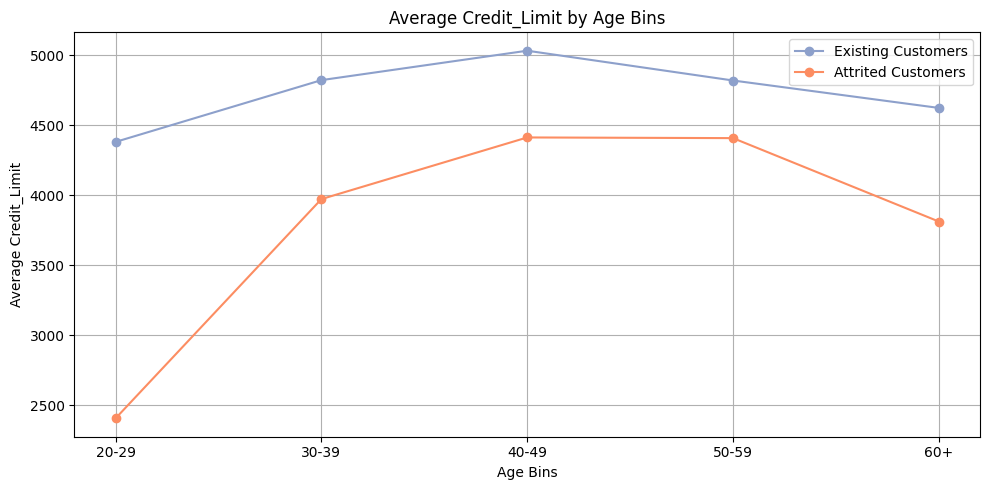

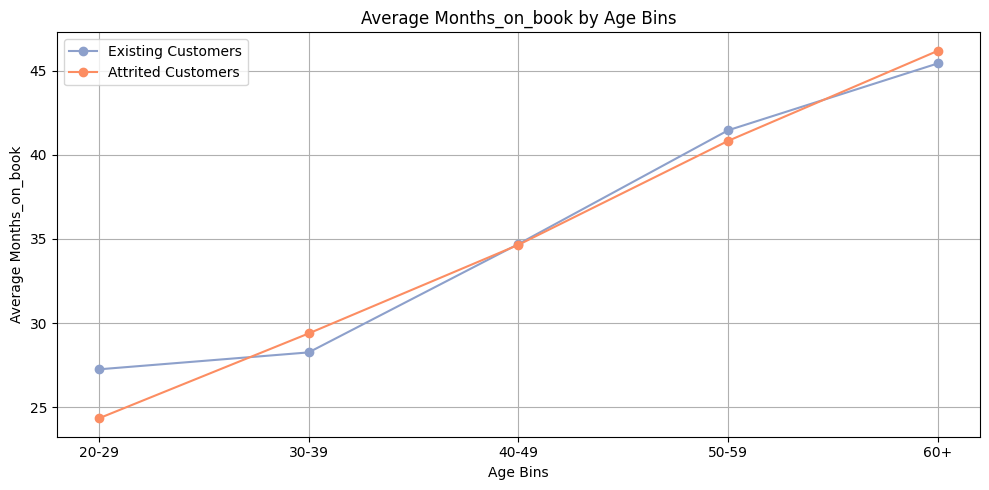

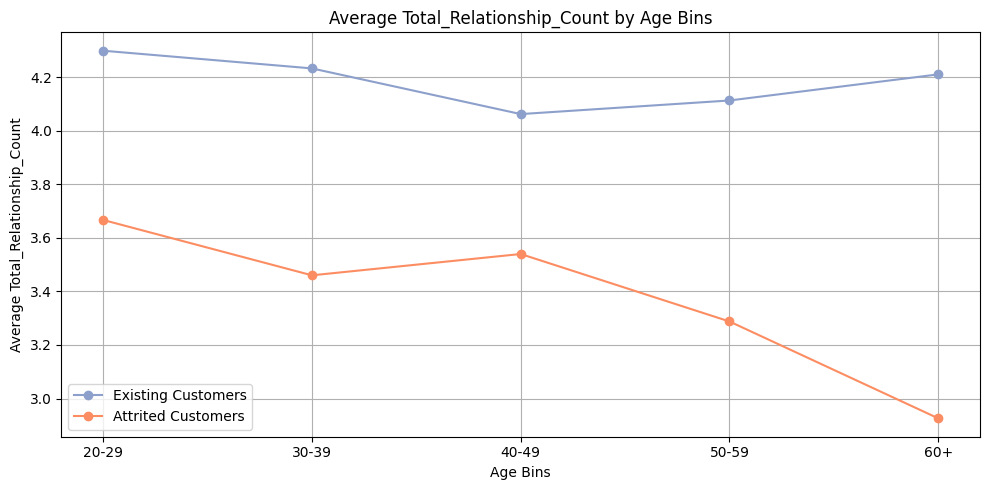

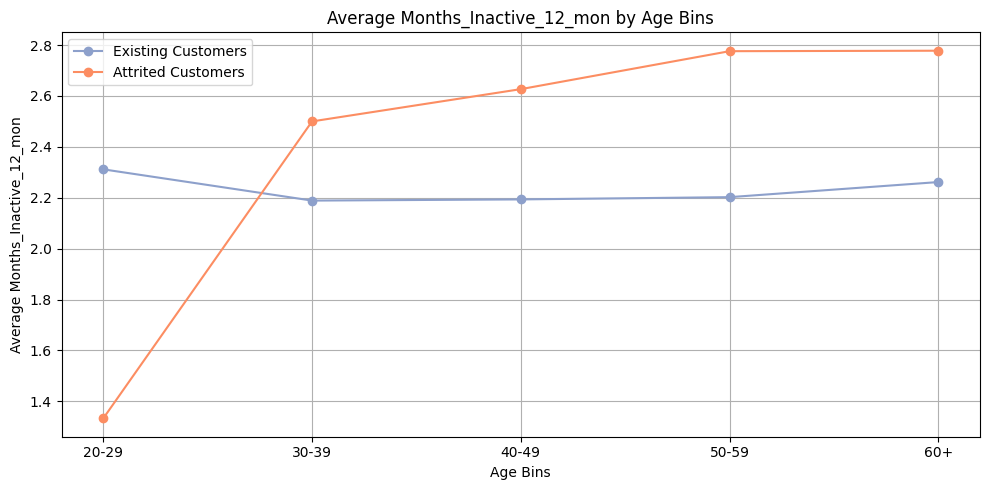

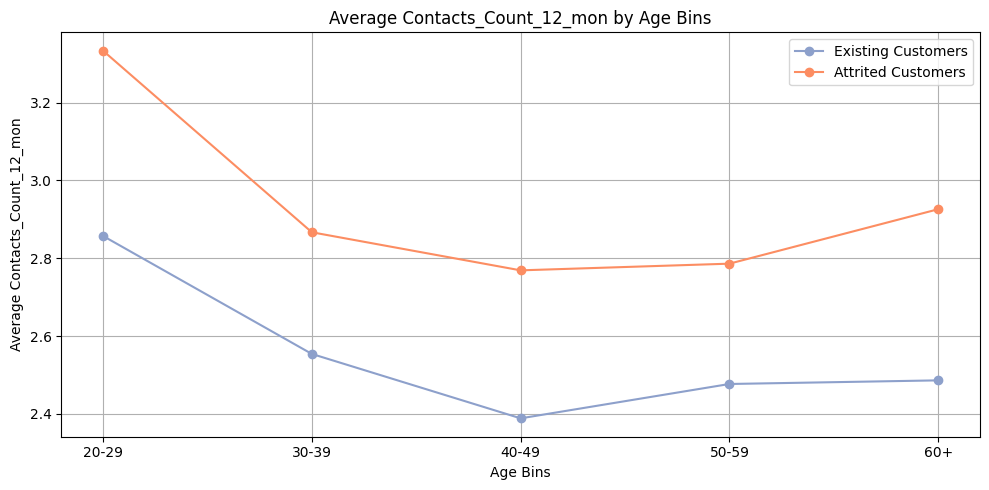

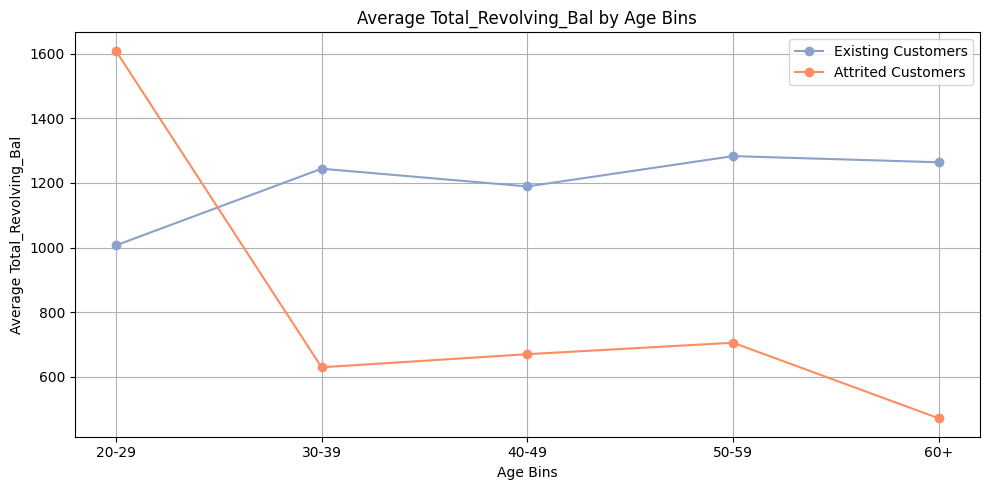

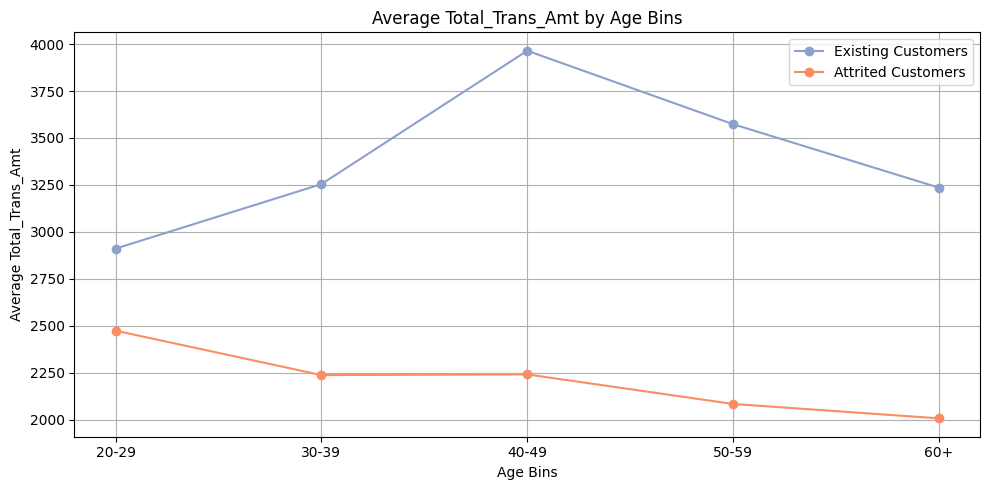

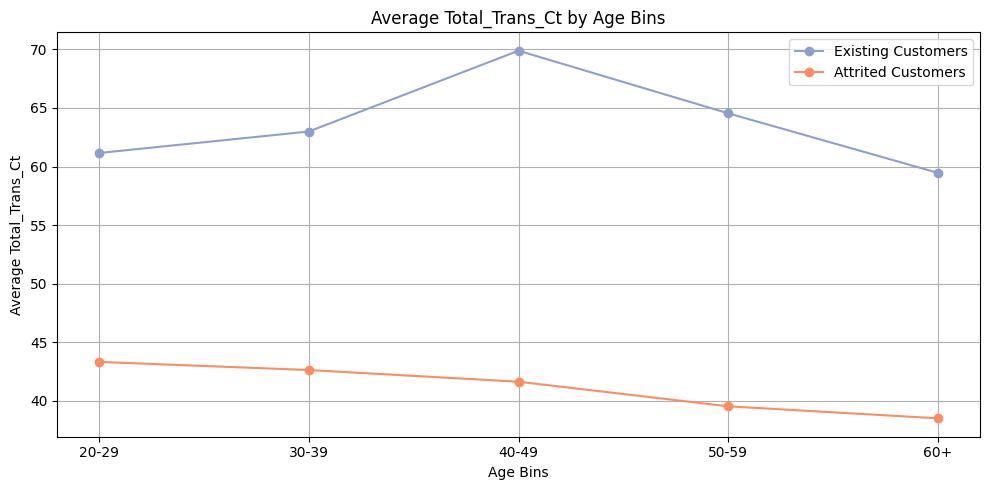

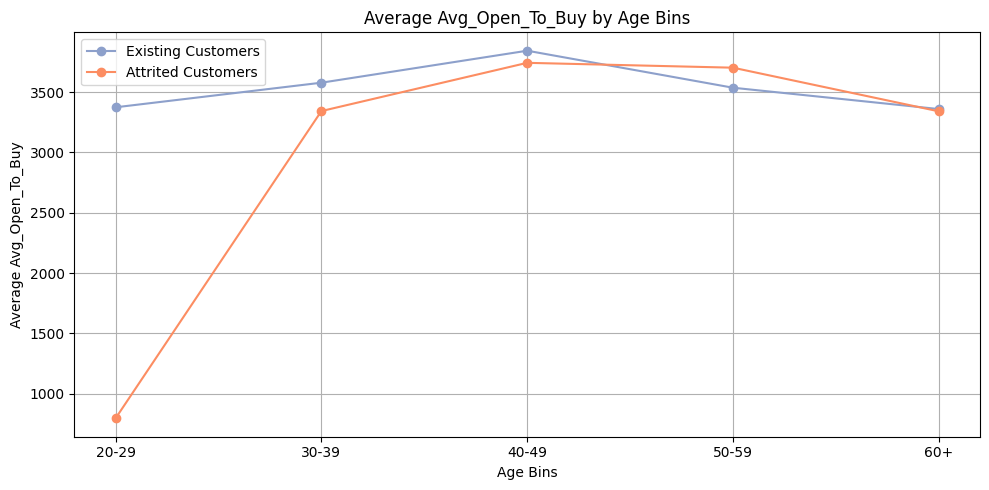

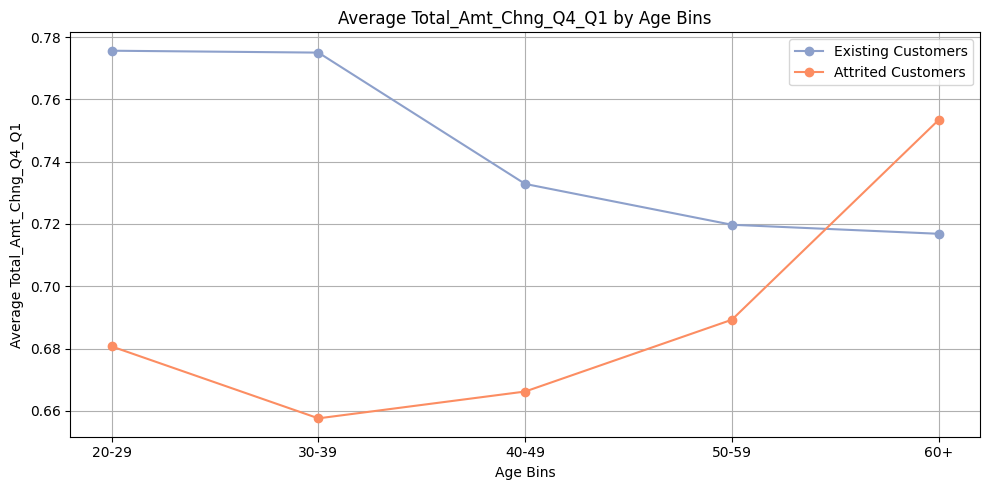

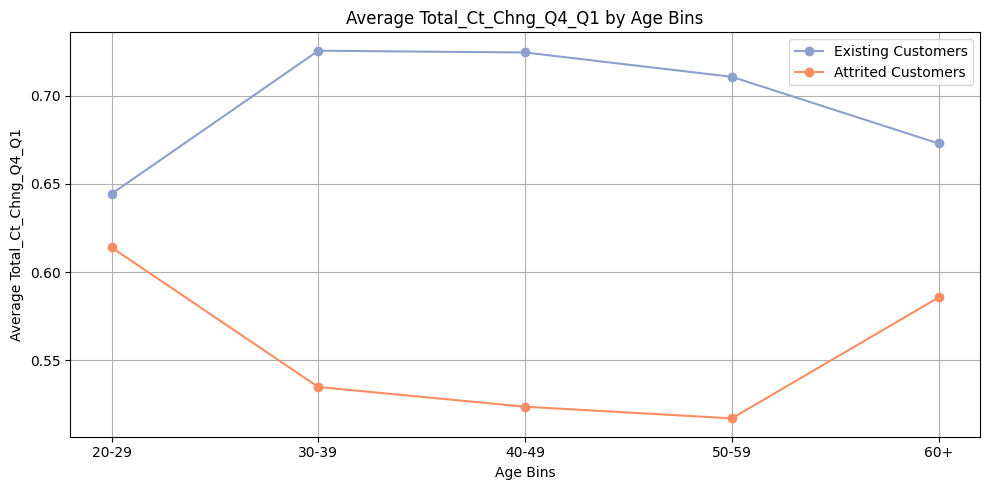

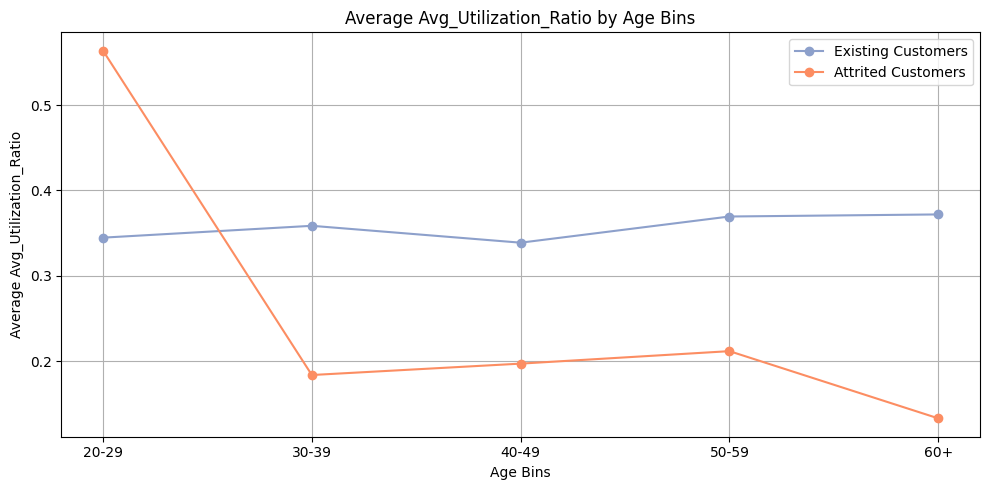

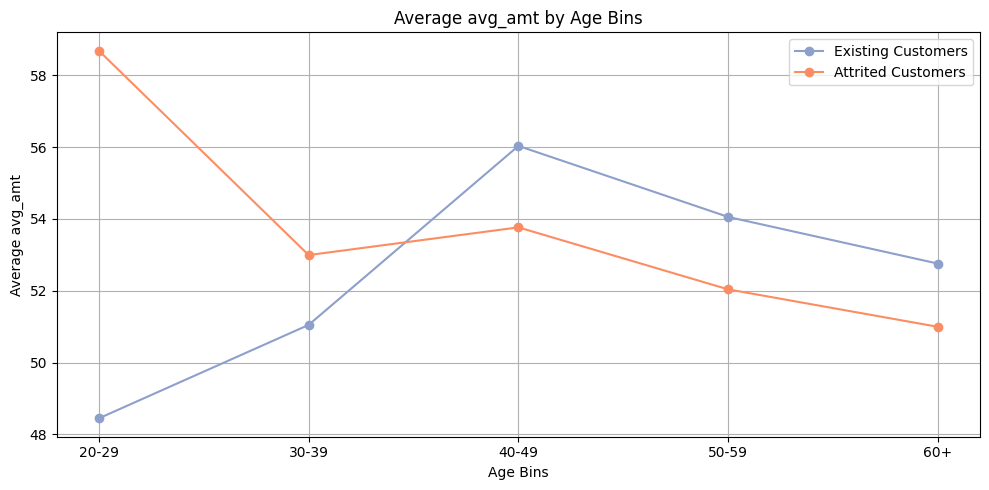

In [ ]:

#PLotting a graphs for group by on age of customers and getting mean of numerical columns for existing customers
for col in data_num_col:
    existing_means = new_data_existing_customer.groupby('Age_Bins')[col].mean()
    attrited_means = new_data_attrited_customer.groupby('Age_Bins')[col].mean()

    plt.figure(figsize=(10, 5))
    plt.plot(existing_means.index, existing_means.values, marker='o', label='Existing Customers', color='#8DA0CB')
    plt.plot(attrited_means.index, attrited_means.values, marker='o', label='Attrited Customers', color='#FC8D62')
    plt.title(f'Average {col} by Age Bins')
    plt.xlabel('Age Bins')
    plt.ylabel(f'Average {col}')
    plt.xticks(rotation=0)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



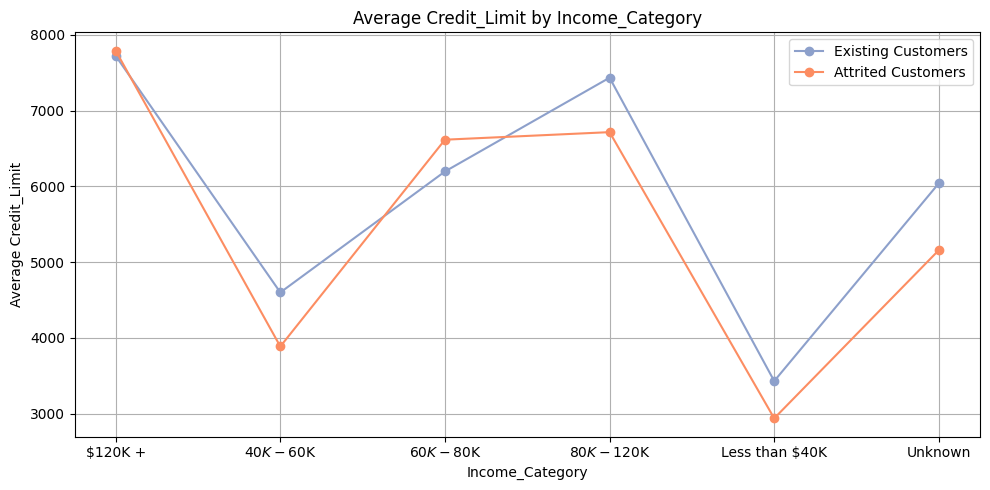

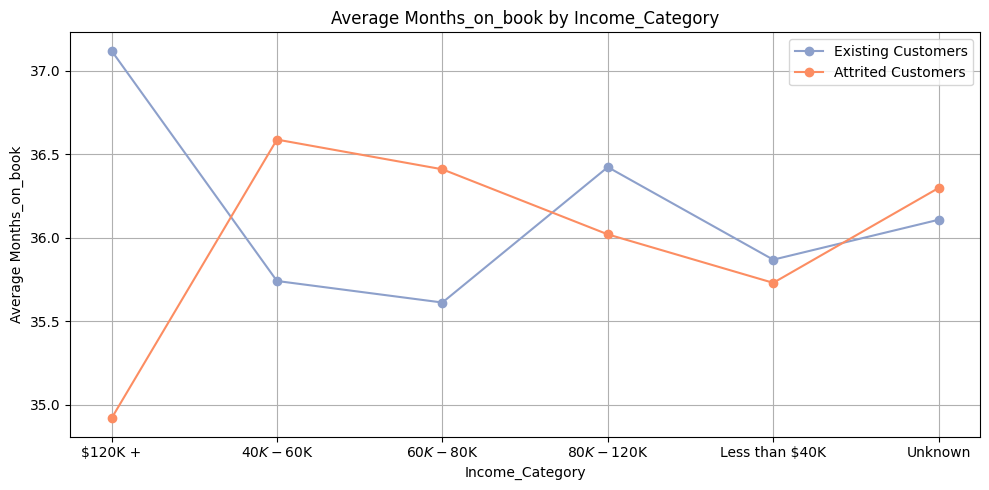

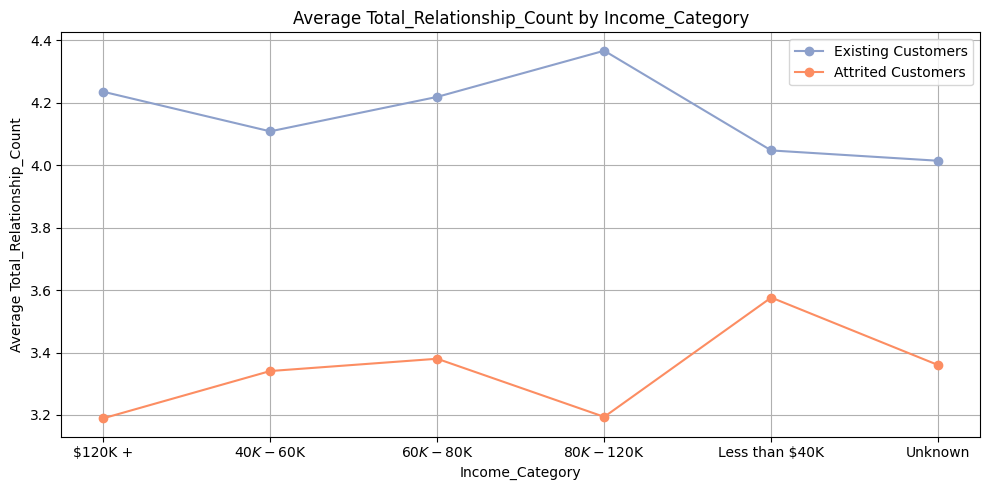

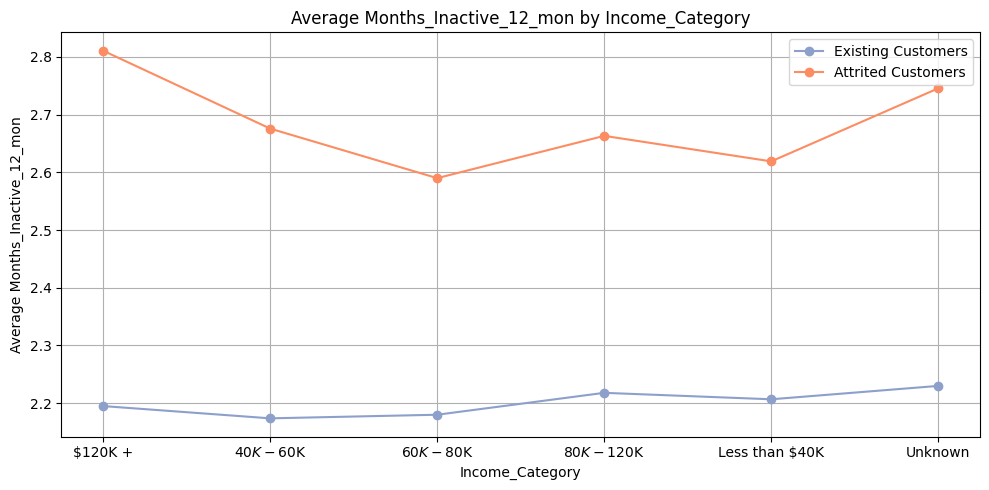

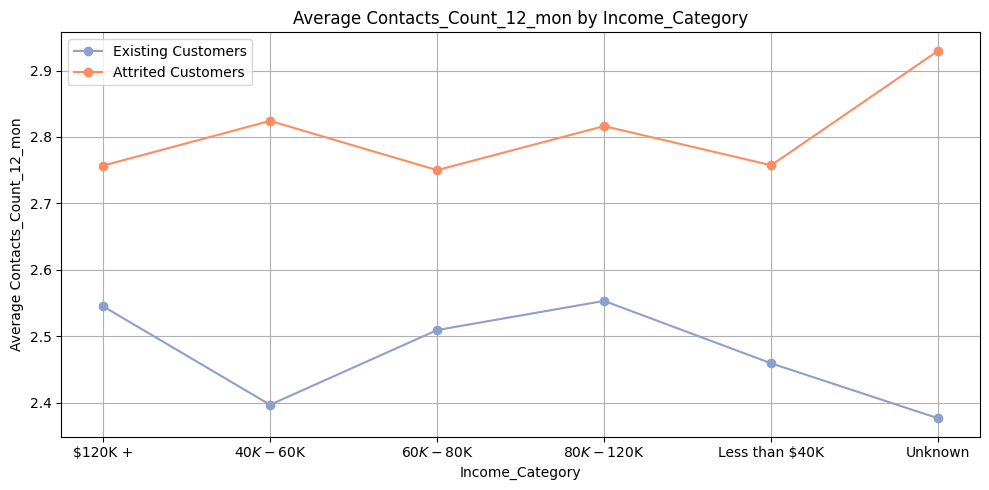

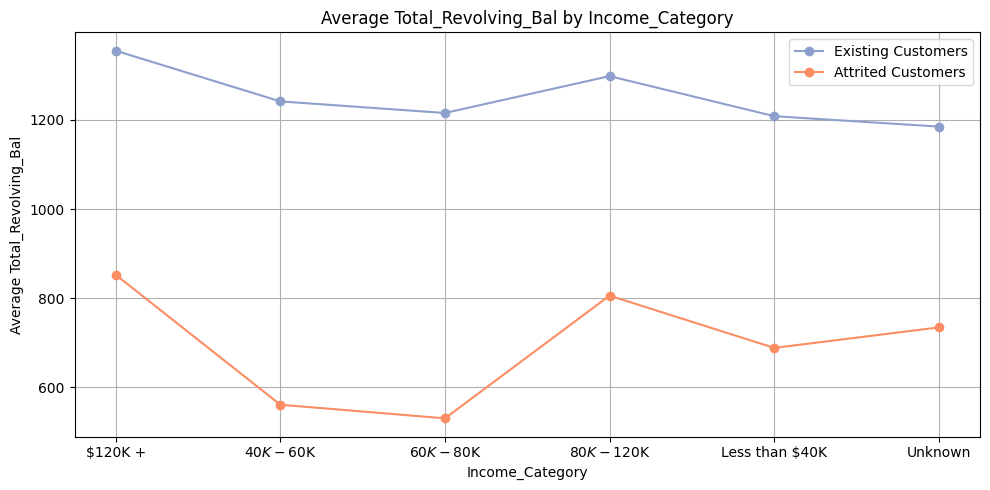

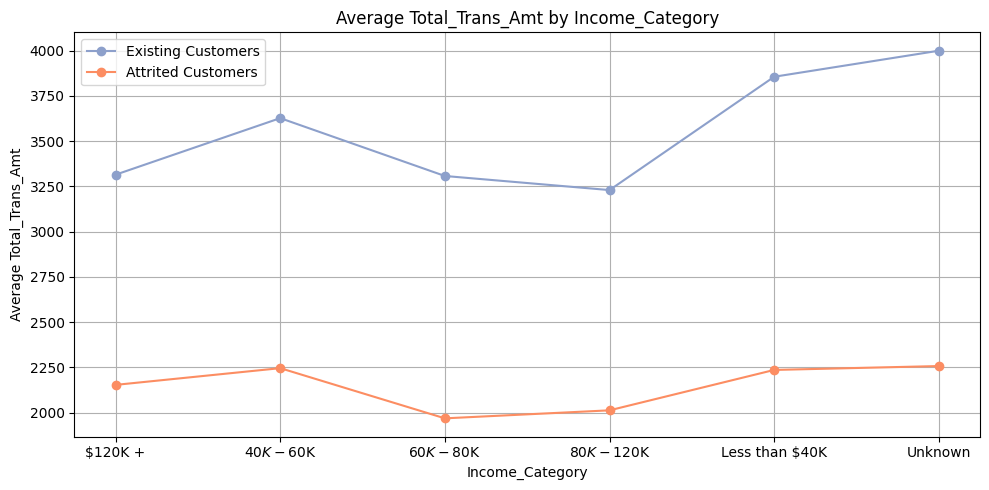

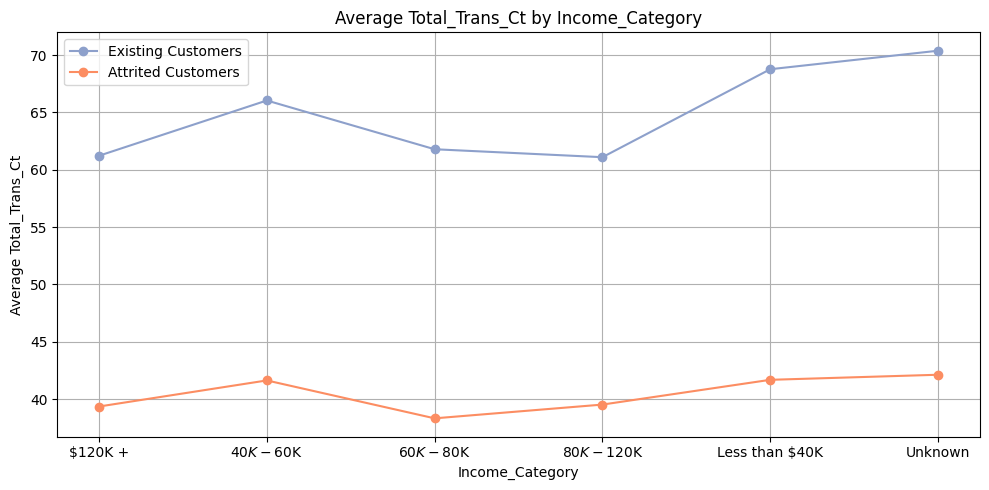

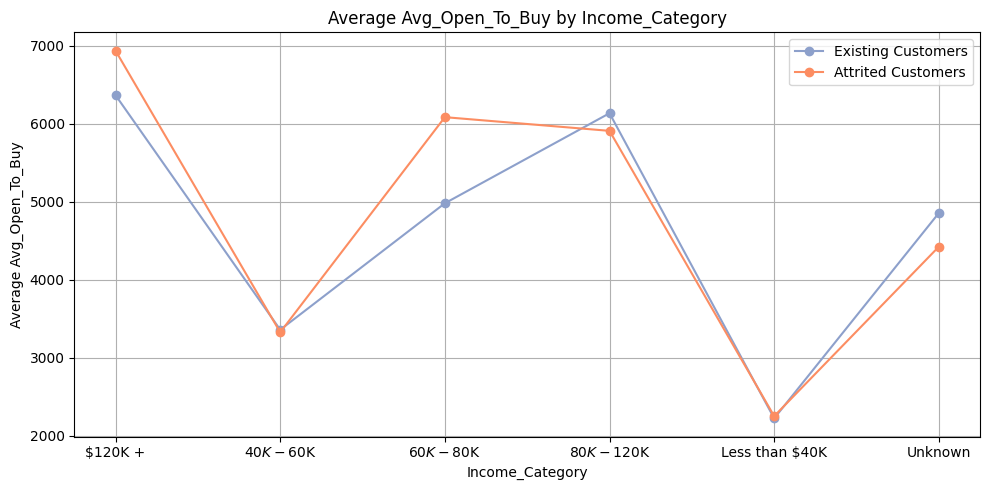

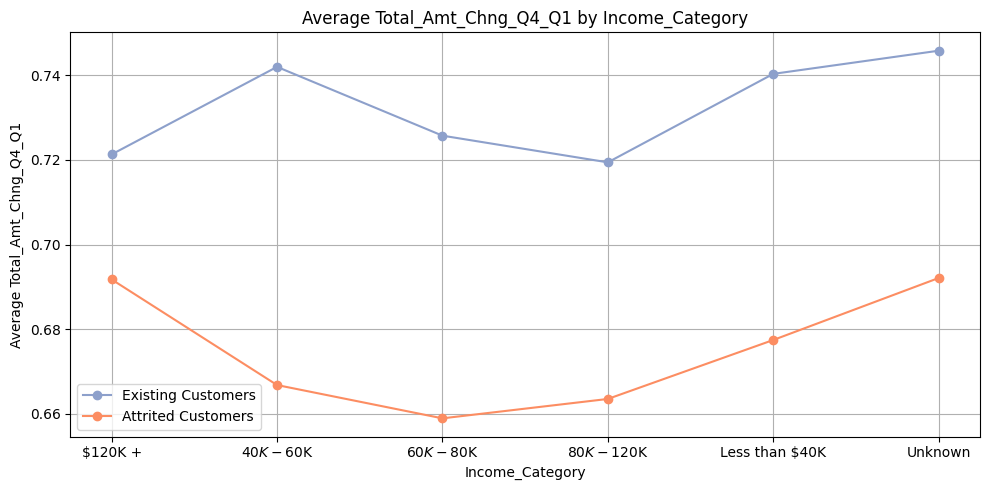

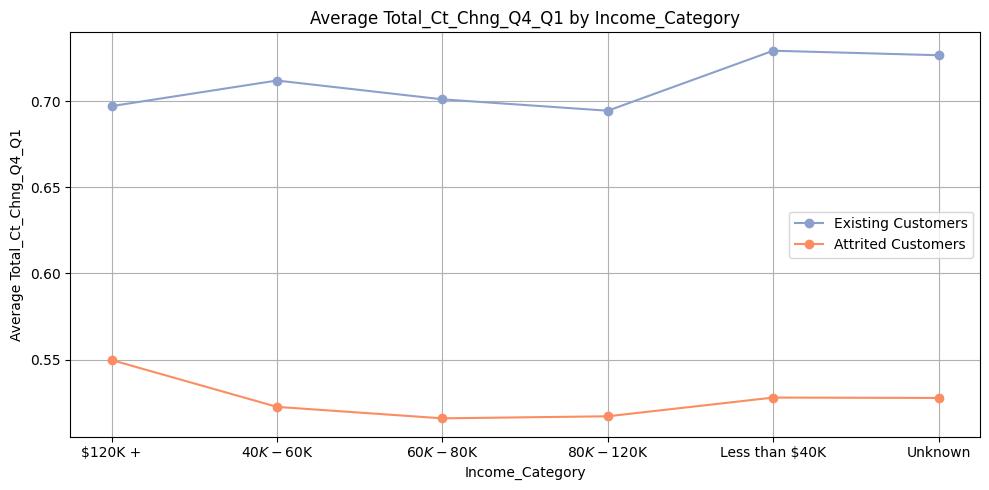

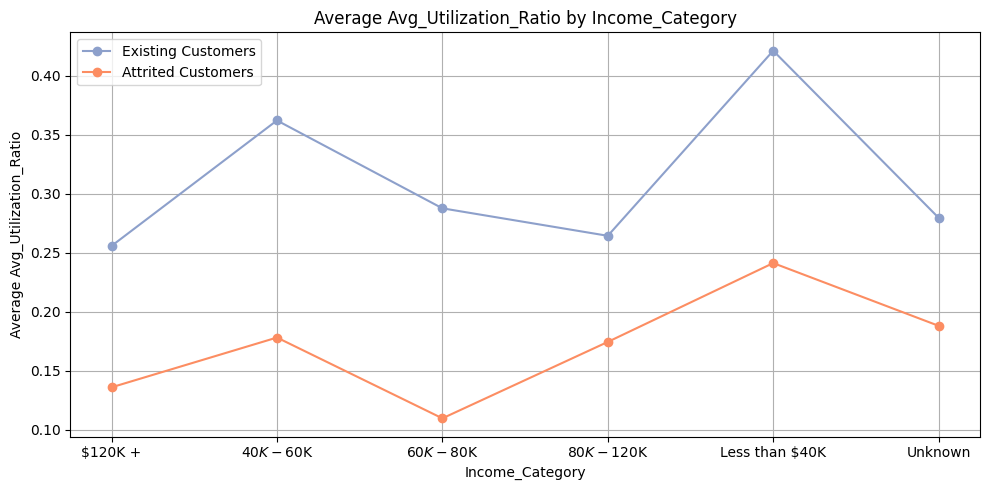

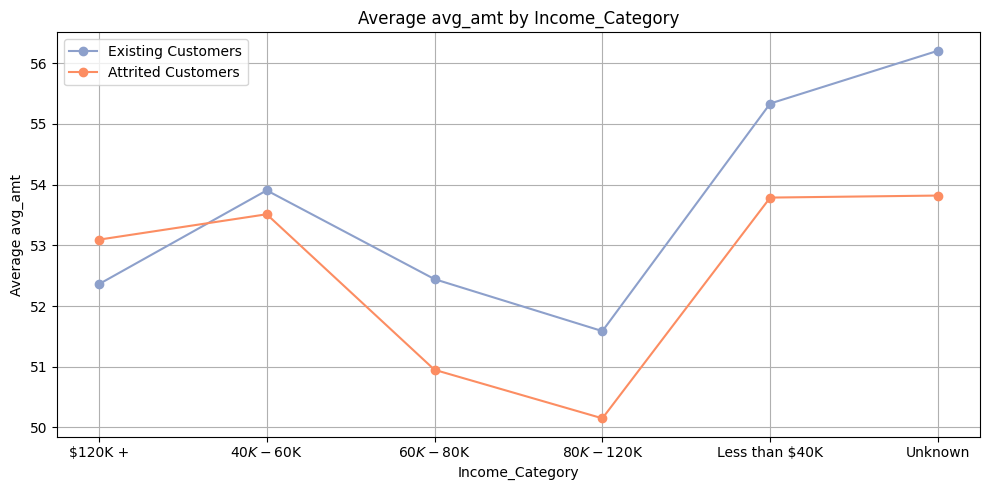

In [ ]:
#PLotting a graphs for group by on Income_Category of customers and getting mean of numerical columns for existing and attrited customers

for col in data_num_col:
    existing_means = new_data_existing_customer.groupby('Income_Category')[col].mean()
    attrited_means = new_data_attrited_customer.groupby('Income_Category')[col].mean()

    plt.figure(figsize=(10, 5))
    plt.plot(existing_means.index, existing_means.values, marker='o', label='Existing Customers', color='#8DA0CB')
    plt.plot(attrited_means.index, attrited_means.values, marker='o', label='Attrited Customers', color='#FC8D62')
    plt.title(f'Average {col} by Income_Category')
    plt.xlabel('Income_Category')
    plt.ylabel(f'Average {col}')
    plt.xticks(rotation=0)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

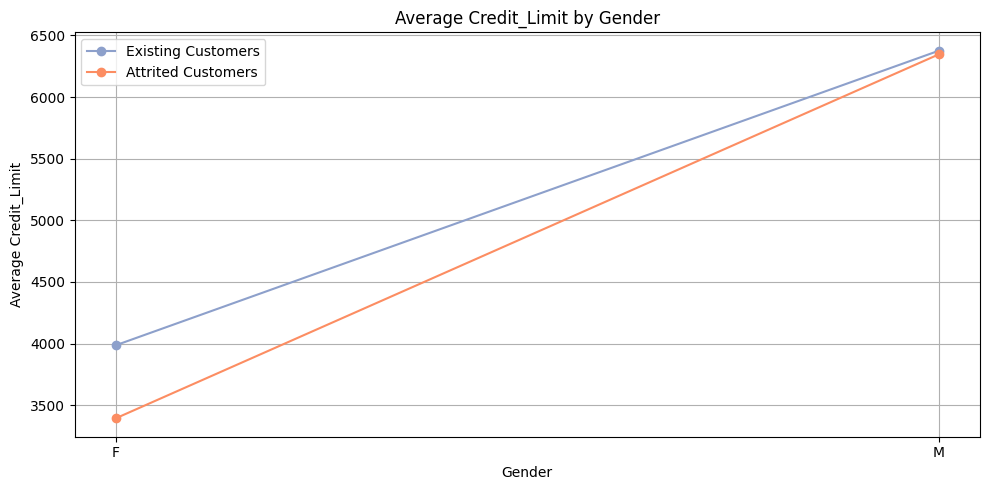

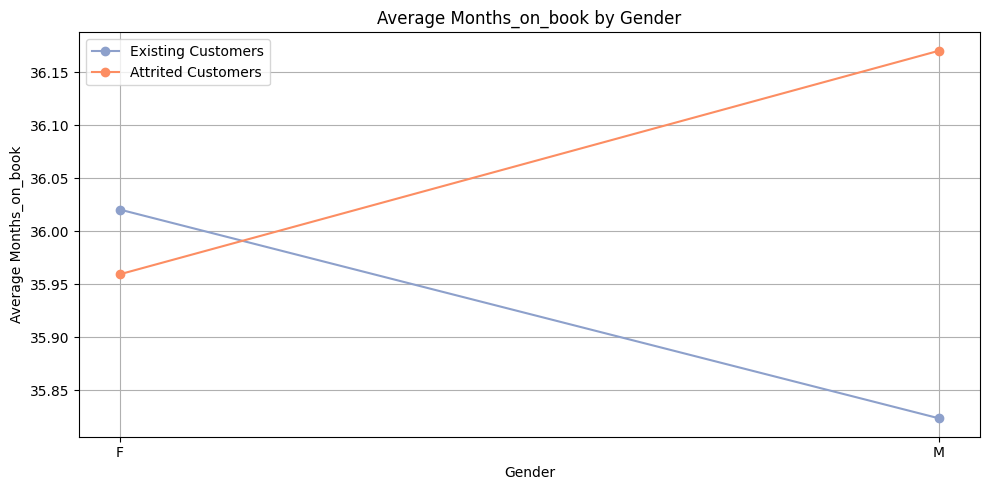

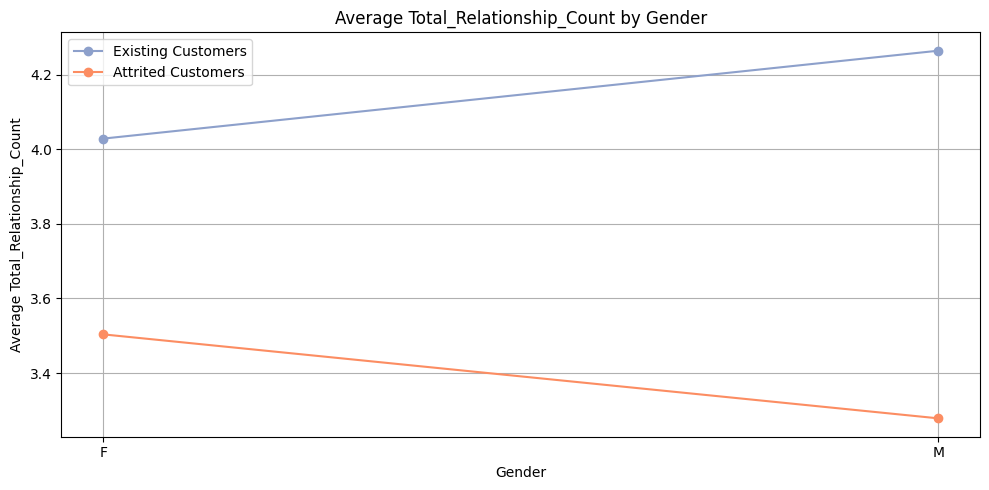

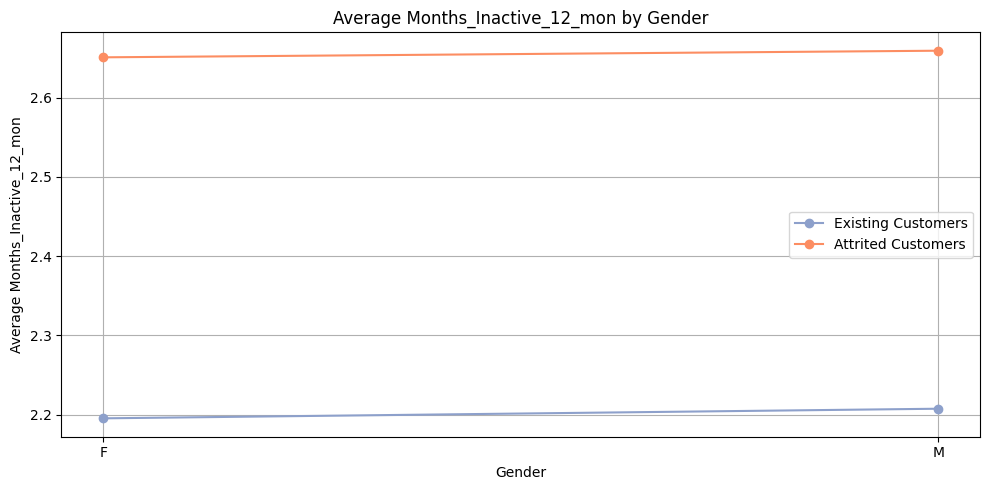

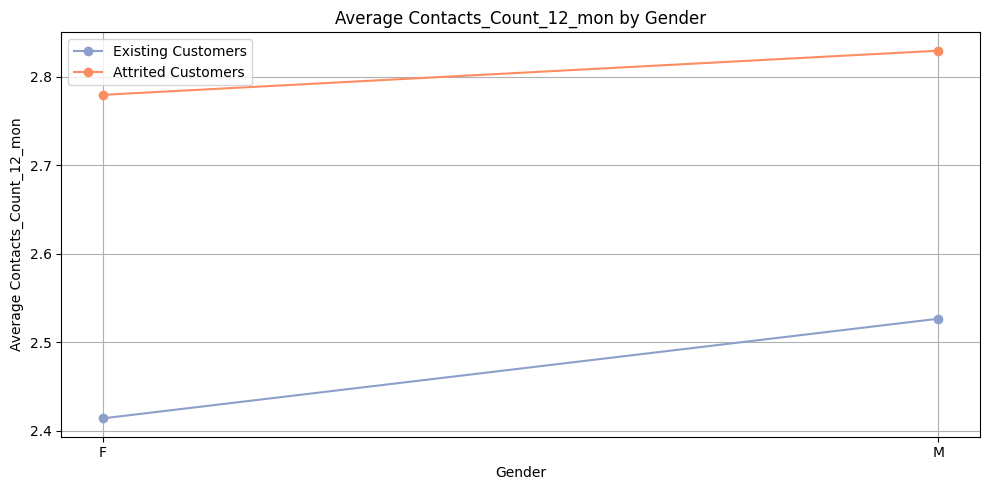

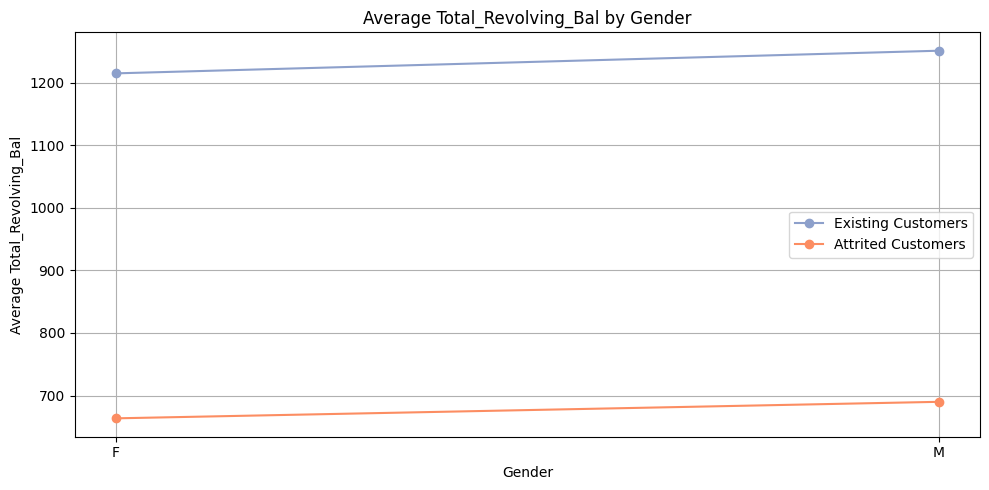

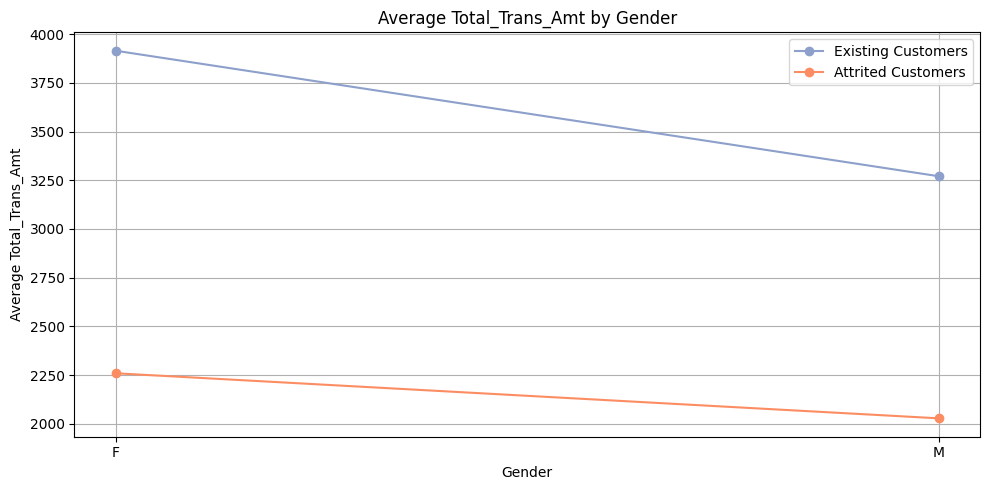

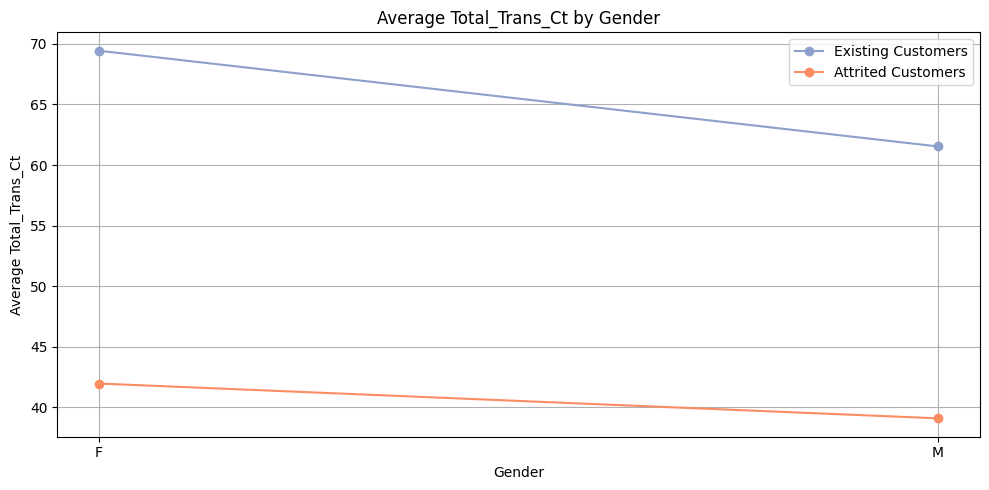

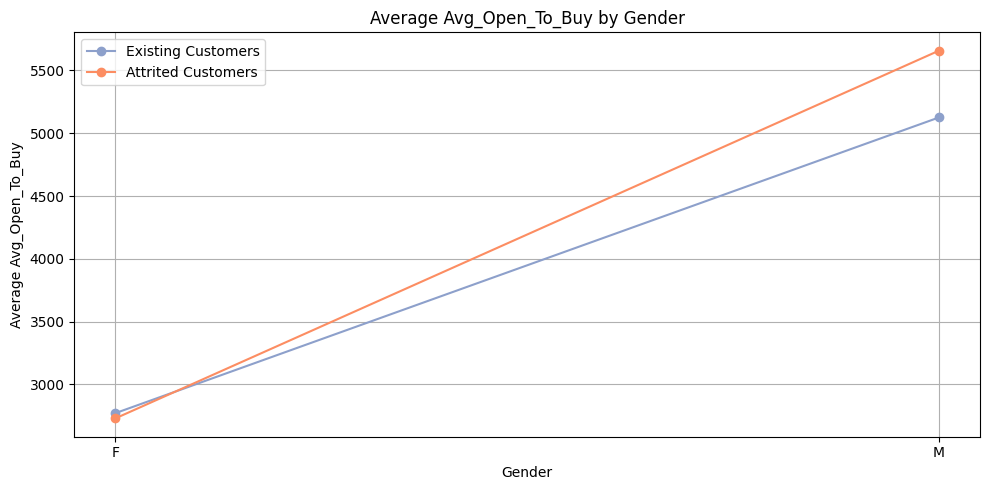

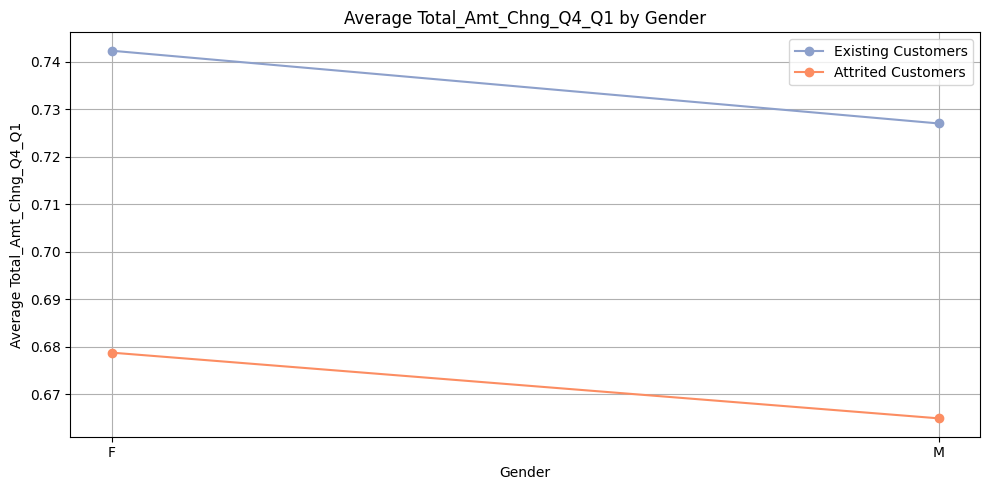

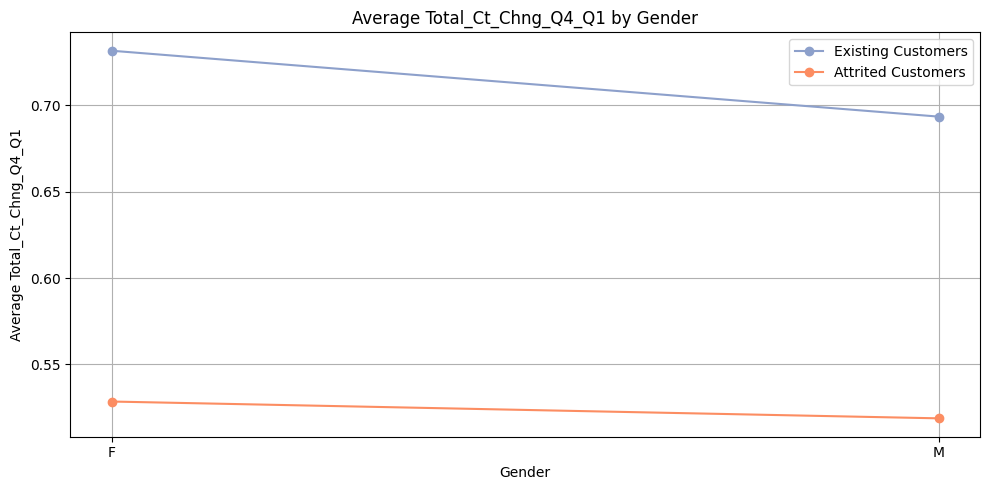

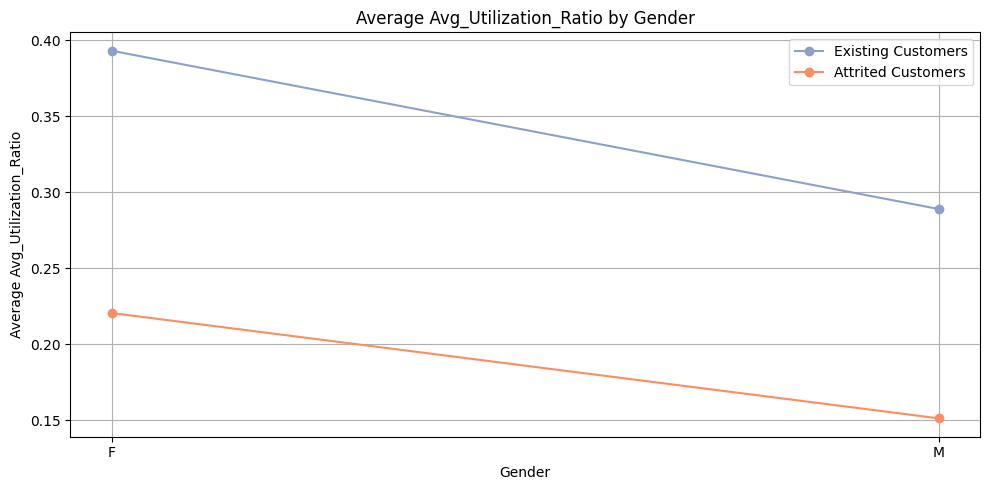

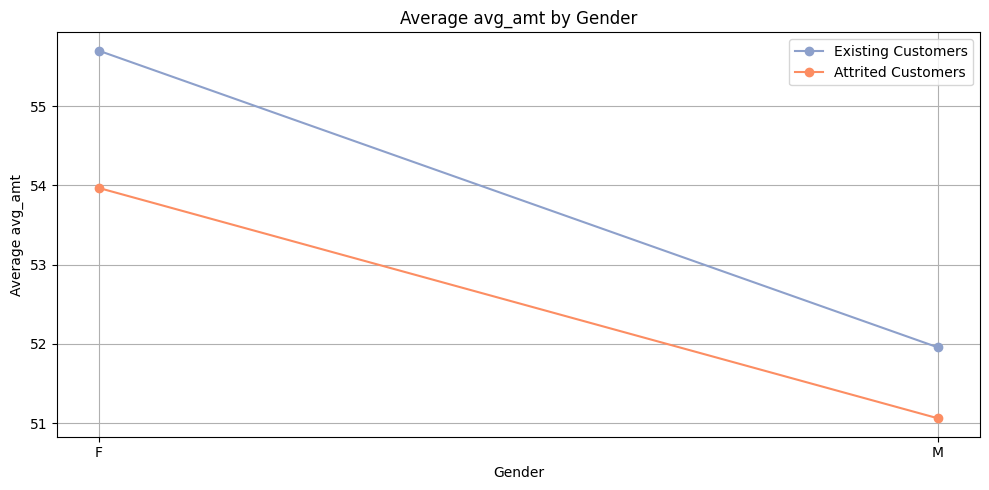

In [ ]:
#PLotting a graphs for group by on gender of customers and getting mean of numerical columns for existing and attrited customers
for col in data_num_col:
    existing_means = new_data_existing_customer.groupby('Gender')[col].mean()
    attrited_means = new_data_attrited_customer.groupby('Gender')[col].mean()

    plt.figure(figsize=(10, 5))
    plt.plot(existing_means.index, existing_means.values, marker='o', label='Existing Customers', color='#8DA0CB')
    plt.plot(attrited_means.index, attrited_means.values, marker='o', label='Attrited Customers', color='#FC8D62')
    plt.title(f'Average {col} by Gender')
    plt.xlabel('Gender')
    plt.ylabel(f'Average {col}')
    plt.xticks(rotation=0)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**Business Insights based on customer attrition analysis**

1. The overall attrition rate in the customer dataset stands at 16%.
2. Female customers exhibit a higher attrition rate at 17.4%, compared to 14.6% for male customers.
3. Attrition is most prominent among customers aged 40–49 and 50–59, both groups recording an attrition rate of 16.9%.
4. Single customers have a higher attrition rate (16.9%) compared to their married counterparts (15.1%).
5. Customers with three dependents show the highest attrition at 17.6%, followed by those with two dependents at 15.7%.
6. A large portion of the customer base has education levels of high school or graduate degrees. Attrition is 15.6% among graduates and 15.2% among high school graduates.

7. Customers earning less than 40K represent a significant portion of the dataset and show the highest income-based attrition rate at 17.2%, followed by those earning 80K–120K at 15.8%.
8. There are no female customers in the 60K–80K, 80K–120K, or 120K+ income categories. Notably, 91.6% of female customers fall in the 'Less than $40K' income bracket.
9. Across numerical features, attrited customers have lower mean and median values for Total Revolving Balance, Total Transaction Amount, and Total Transaction Count, highlighting these metrics as key differentiators in attrition analysis.







**Recommendations Based on Customer Attrition Analysis**

1. Targeted Retention Campaigns for At-Risk Demographics
 Female customers, particularly those earning less than 40K, have a higher attrition rate.

 **Recommendation:** Design tailored financial products, rewards, or engagement programs for this segment. Offer personalized outreach, financial literacy resources, or incentives to increase perceived value and customer loyalty.
2. Focused Interventions for Middle-Aged Customers
 Customers aged 40–59 exhibit the highest attrition rates.

  **Recommendation:**Conduct surveys or focus groups to understand their pain points. Provide mid-life financial planning tools, loyalty programs, or exclusive offers tailored to this life stage.
3. Proactive Engagement for Single Customers
 Attrition is higher among single customers compared to married ones.

 **Recommendation:**Enhance engagement through lifestyle-based campaigns, social reward programs, and financial products tailored to independent professionals.
4. Tailored Support for Families with Dependents
 Customers with two or more dependents—especially those with three—have higher attrition.

 **Recommendation:**Offer family-oriented financial services, such as dependent-linked benefits, educational savings plans, and bundled family financial packages.
5. Reevaluate Messaging Based on Educational Background
 Attrition among both graduates and high school-educated customers is notable.

 **Recommendation:** Customize communication strategies according to educational background. Provide accessible financial education resources through gamified tools, webinars, or mobile-friendly content.
6. Reconsider Income-Based Product Positioning
 Customers earning less than 40K show the highest attrition among income groups.

  **Recommendation:** Introduce low-fee or value-based offerings. Emphasize practical benefits like budgeting assistance, overdraft protection, or cashback on essentials.
7. Implement Data-Driven Risk Scoring Models
 Attrited customers tend to have lower Total Revolving Balance, Transaction Amount, and Transaction Count.

  **Recommendation:**Build churn prediction models using these indicators to identify at-risk customers. Trigger timely retention actions such as personalized communication, rewards, or relationship manager calls.
8. Address Gender Gaps in Income Segments
 There are no female customers in mid-to-high income groups, with 91.6% concentrated in the <$40K category.

  **Recommendation:**Investigate potential data collection gaps or barriers to inclusion. Consider strategies to attract and retain high-earning female customers through tailored offerings and inclusive marketing.

##Hypothesis Testing

Credit Limit

Null hypothesis (H₀):
The mean credit limit is the same for attrited and existing customers.

Alternative hypothesis (H₁):
The mean credit limit is less for attrited customers than for existing customers.


Total Revolving Balance

Null hypothesis (H₀):
The mean total revolving balance is the same for attrited and existing customers.

Alternative hypothesis (H₁):
The mean total revolving balance is less for attrited customers than for existing customers.


In [45]:
# Hypothesis Tesing on Total Revolving Balance for checking pvalue :One tailed Two Sample independent T test

from scipy import stats

attrited_trb = data[data['Attrition_Flag']=='Attrited Customer']['Total_Revolving_Bal']
existing_trb = data[data['Attrition_Flag']=='Existing Customer']['Total_Revolving_Bal']

tstat,pvalue = stats.ttest_ind(attrited_trb, existing_trb, alternative="less")  # one tailed two sample independent t test
print(f"T-statistic: {tstat:.4f}")
print(f"P-value: {pvalue:.4f}")

alpha = 0.05
if pvalue < alpha:
    print("Null hypothesis rejected: The mean total revolving balance is less for attrited customers than for existing customers.")
else:
    print("Null hypothesis not rejected: The mean total revolving balance is the same for attrited and existing customers.")

T-statistic: -27.4354
P-value: 0.0000
Null hypothesis rejected: The mean total revolving balance is less for attrited customers than for existing customers.


Total Transaction Amount

Null hypothesis (H₀):
The mean total transaction amount is the same for attrited and existing customers.

Alternative hypothesis (H₁):
The mean total transaction amount is less for attrited customers than for existing customers.


In [44]:
# Hypothesis Tesing on Total Transaction Amount for checking pvalue :One tailed Two Sample independent T test

from scipy import stats

attrited_tta = data[data['Attrition_Flag']=='Attrited Customer']['Total_Trans_Amt']
existing_tta = data[data['Attrition_Flag']=='Existing Customer']['Total_Trans_Amt']

tstat,pvalue = stats.ttest_ind(attrited_tta, existing_tta, alternative="less")  # one tailed two sample independent t test
print(f"T-statistic: {tstat:.4f}")
print(f"P-value: {pvalue:.4f}")

alpha = 0.05
if pvalue < alpha:
    print("Null hypothesis rejected: The mean total transaction amount is less for attrited customers than for existing customers.")
else:
    print("Null hypothesis not rejected: The mean total transaction amount is the same for attrited and existing customers.")

T-statistic: -17.2113
P-value: 0.0000
Null hypothesis rejected: The mean total transaction amount is less for attrited customers than for existing customers.


Total Transaction Count

Null hypothesis (H₀):
The mean total transaction count is the same for attrited and existing customers.

Alternative hypothesis (H₁):
The mean total transaction count is less for attrited customers than for existing customers.


In [43]:
# Hypothesis Tesing on Total Transaction Count for checking pvalue :One tailed Two Sample independent T test

from scipy import stats

attrited_ttc = data[data['Attrition_Flag']=='Attrited Customer']['Total_Trans_Ct']
existing_ttc = data[data['Attrition_Flag']=='Existing Customer']['Total_Trans_Ct']

tstat,pvalue = stats.ttest_ind(attrited_ttc, existing_ttc, alternative="less")  # one tailed two sample independent t test
print(f"T-statistic: {tstat:.4f}")
print(f"P-value: {pvalue:.4f}")

alpha = 0.05
if pvalue < alpha:
    print("Null hypothesis rejected: The mean total transaction count is less for attrited customers than for existing customers.")
else:
    print("Null hypothesis not rejected: The mean total transaction count is the same for attrited and existing customers.")

T-statistic: -40.2507
P-value: 0.0000
Null hypothesis rejected: The mean total transaction count is less for attrited customers than for existing customers.


Gender = F and Income Category = ‘Less than $40K’

Null hypothesis (H₀):
There is no difference in churn rates between female customers earning less than $40K and other customers.

Alternative hypothesis (H₁):
Female customers earning less than $40K are more likely to churn than other customers.
**bold text**

Gender = F and Age Bin = 40-49 years

Null hypothesis (H₀):
There is no difference in churn rates between female customers aged between 40-49 years and the other customers.

Alternative hypothesis (H₁):
Female customers aged between 40-49 years are more likely to churn than other customers.


Gender=F and Education level = Doctorate

Null hypothesis (H₀):
There is no difference in churn rates between female customers with doctorate degree and the other customers.

Alternative hypothesis (H₁):
Female customers with a doctorate degree are more likely to churn than other customers.


Gender = F and Dependent Count = 3

Null hypothesis (H₀):
There is no difference in churn rates between female customers with three dependents and the other customers.

Alternative hypothesis (H₁):
Female customers with three dependents are more likely to churn than other customers.


In [ ]:
categorical_features = ['Gender', 'Marital_Status', 'Income_Category', 'Education_Level', 'Age_Bins','Dependent_count']
from scipy.stats import chi2_contingency

for col in categorical_features:
    contingency_table = pd.crosstab(data[col], data['Attrition_Flag'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"\nFeature: {col}")
    print("P-value:", p)
    if p < 0.05:
        print("→ Significant association with Attrition")
    else:
        print("→ No significant association")


Feature: Gender
P-value: 0.00019635846717310307
→ Significant association with Attrition

Feature: Marital_Status
P-value: 0.10891263394840227
→ No significant association

Feature: Income_Category
P-value: 0.025002425704390617
→ Significant association with Attrition

Feature: Education_Level
P-value: 0.05148913147336634
→ No significant association

Feature: Age_Bins
P-value: 0.0006081828264970322
→ Significant association with Attrition

Feature: Dependent_count
P-value: 0.09150463456682643
→ No significant association


In [ ]:
# z-proportion test for  Gender = F and Income Category = ‘Less than $40K’


from statsmodels.stats.proportion import proportions_ztest

# Filter group 1: Female customers earning less than $40K
group1 = data[(data['Gender'] == 'F') & (data['Income_Category'] == 'Less than $40K')]
n1 = len(group1)
successes1 = (group1['Attrition_Flag'] == 'Attrited Customer').sum()

# Filter group 2: All other customers
group2 = data[~((data['Gender'] == 'F') & (data['Income_Category'] == 'Less than $40K'))]
n2 = len(group2)
successes2 = (group2['Attrition_Flag'] == 'Attrited Customer').sum()

# Prepare counts for the z-test
count = [successes1, successes2]
nobs = [n1, n2]

# Run one-tailed z-test for proportions
stat, pval = proportions_ztest(count, nobs, alternative='larger')  # H1: group1 has higher proportion

print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")


Z-statistic: 3.1444
P-value: 0.0008


In [ ]:
# z-proportion test for  Gender = F and Education level = Doctorate


from statsmodels.stats.proportion import proportions_ztest

# Filter group 1: Female customers and Education level = Doctorate
group_1d = data[(data['Gender'] == 'F') & (data['Education_Level'] == 'Doctorate')]
n_1d = len(group_1d)
successes_1d = (group_1d['Attrition_Flag'] == 'Attrited Customer').sum()

# Filter group 2: All other customers
group_2d = data[~((data['Gender'] == 'F') & (data['Education_Level'] == 'Doctorate'))]
n_2d = len(group_2d)
successes_2d = (group_2d['Attrition_Flag'] == 'Attrited Customer').sum()

# Prepare counts for the z-test
count = [successes_1d, successes_2d]
nobs = [n_1d, n_2d]

# Run one-tailed z-test for proportions
stat, pval = proportions_ztest(count, nobs, alternative='larger')  # H1: group1 has higher proportion

print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")


Z-statistic: 3.9077
P-value: 0.0000


In [ ]:
# z-proportion test for  Gender = F and Age bin = 40-49 years


from statsmodels.stats.proportion import proportions_ztest

# Filter group 1: Female customers and age = 40-49
group_1 = data[(data['Gender'] == 'F') & (data['Age_Bins'] == '40-49')]
n_1 = len(group_1)
successes_1 = (group_1['Attrition_Flag'] == 'Attrited Customer').sum()

# Filter group 2: All other customers
group_2 = data[~((data['Gender'] == 'F') & (data['Age_Bins'] == '40-49'))]
n_2 = len(group_2)
successes_2 = (group_2['Attrition_Flag'] == 'Attrited Customer').sum()

# Prepare counts for the z-test
count = [successes_1, successes_2]
nobs = [n_1, n_2]

# Run one-tailed z-test for proportions
stat, pval = proportions_ztest(count, nobs, alternative='larger')  # H1: group1 has higher proportion

print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")


Z-statistic: 3.4194
P-value: 0.0003
